### LSE Data Analytics Online Career Accelerator

# Employer Project - Médecins Sans Frontières

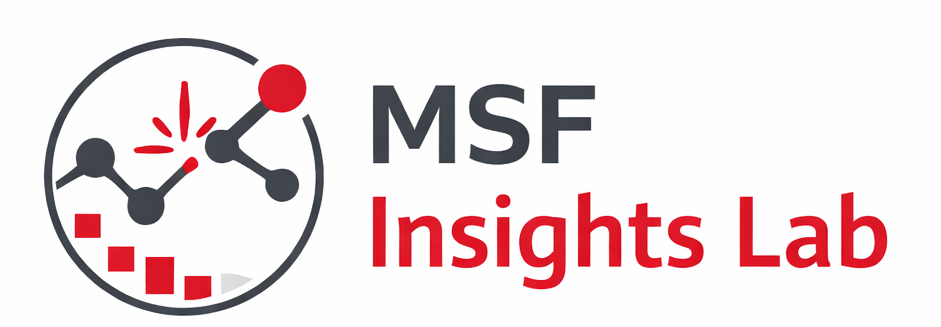

This Jupyter Notebook supports the reconstruction of MSF travel journeys from fragmented booking, invoice, itinerary, cost, and emissions data. It focuses on data quality checks, identifier matching, fallback logic, and journey-level validation to improve reporting on travel spend, emissions, and operational efficiency.

Scope

* Structure and reconstruction
* Travel spend and cost efficiency analysis.
* Sustainability vs Cost Analysis

Information about MSF https://www.msf.org/international-activity-report-2024

## MSF Travel Data — Pipeline Development Progress
**LSE Data Analytics Capstone — Médecins Sans Frontières**

This notebook documents the full development journey: every iteration tried, why it failed,
and what replaced it. Final executable code comes from `MSF_Pipeline_Consolidated` and runs
correctly from top to bottom. Iteration blocks (marked with 🔄) appear immediately before the
final version of each step they relate to, so the progression from first attempt to final
solution is visible in execution order.

**Iterations documented:**

| Step | What was iterated |
|------|-------------------|
| Step 1a | Excel `=-` corruption — not detected initially; discovered during Step 7 QA |
| Step 2a | Fees and Misc — retained too long initially; excluded earlier after issues |
| Step 2b | `***/***` rows — recovery attempted; excluded after no route data found |
| Step 7 v1 | PNR grouping by `ticket_number` alone — over-merged across travellers |
| Step 7 v2 | Most-frequent alpha PNR per group — merged separate journeys (NWKQFD + MEDH69) |
| Step 9 | Hotel separation — included in aggregation initially; separated after MSF clarification |
| Step 11 | Emission matching — PNR-level aggregate with `is_emission_carrier`; lost data on multi-sub-journey PNRs |
| R4 filter | European filter using `origin_region`/`destination_region`; replaced with itinerary-level IATA filter |
| R3 chart | Percentage-stacked bars → absolute-count bars + twin-axis rate lines |
| R2 chart | Curved arrow callouts → bracket-span callouts |
| Savings charts | 3-bar (historical + 2024 + 2025) → 2-bar (2024 + 2025 only) |
| R5 | Regional benchmarking — explored, found to be budget metric not cash saving, removed |


# MSF Travel Data — Consolidated Pipeline, Analysis & Savings

This notebook contains the full end-to-end pipeline that transforms MSF's raw corporate travel data
into a clean journey-level analytical dataset, followed by the recommendation analysis and
forecasted savings model.

### Pipeline overview
| Step | Description |
|------|-------------|
| 0 | Imports & file paths |
| 1 | Load raw datasets |
| 1a | Data diagnosis: `=-` prefix corruption in ticket/invoice numbers |
| 2 | Rename & expand `record_type` |
| 2a | Exclude Fees and Misc records from working dataset |
| 2b | Exclude masked itinerary records (`***/***`) |
| 3 | Apply IATA correction map → `corrected_origin_airport`, `corrected_destination_airport` |
| 4 | Apply city-level canonical codes → `corrected_origin`, `corrected_destination` |
| 4a | Data diagnosis: incorrect country → region mappings |
| 5 | Parse itinerary → `num_of_legs`, `canonical_od` |
| 5a | Data diagnosis: DEFAULT destination country |
| 6 | Classify every row → `transaction_type` |
| 7 | Canonicalise PNRs (numeric → alphanumeric) per traveller+ticket |
| 7a | Journey ID construction — invoice-first with route fallback |
| 8 | Journey-level aggregation with PNR & invoice consolidation |
| 9 | Split hotel data into a separate DataFrame |
| 10 | Process emission dataset: haul category, EF, carbon tCO₂e |
| 11 | Map emission metrics onto journey-level spend data |
| 12 | Export final outputs |

> **Note:** Update `SPEND_PATH` and `EMISSION_PATH` in Step 0 to match your local file locations.


---
## Step 0 — Imports

All libraries used throughout the pipeline are imported here.
Update the three path constants at the bottom of this cell to match your environment.

| Library | Purpose |
|---------|--------|
| `pandas` | Data loading, cleaning, aggregation |
| `numpy` | Vectorised operations, conditional logic |
| `re` | Regex parsing of itinerary strings |
| `os` | File path handling for outputs |

NOTE:
Check your Pandas and Numpy versions before progressing, using: 

import numpy as np

import pandas as pd

import warnings

print("numpy:", np.__version__)

print("pandas:", pd.__version__)

For correct output, use Pandas version 3.0.3 and NumPy version 2.1.3

In [1]:
import os
import re
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ── Output directory — files are saved in the same folder as the notebook ─────
OUTPUT_DIR = "."   # change to a subfolder path if needed, e.g. "outputs"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

print("Libraries imported successfully.")
print(f"Output dir : {OUTPUT_DIR}")


Libraries imported successfully.
Output dir : .


---
> ### 🔄 Iteration — Excel `=-` corruption: how this step was discovered
>
> **What failed first:** The initial pipeline loaded both CSVs and proceeded directly to IATA
> correction and journey grouping with no check for corrupted ID fields.
>
> **How it was discovered:** During Step 7 (canonical PNR logic), the groupby on
> `['traveler_name', 'invoice_number']` produced unexpectedly large groups. Inspection revealed
> that 2,203 rows had `traveler_name = '#NAME?'` — all being grouped together under a single
> traveller identity. This caused every invoice number shared by those rows to produce one
> massively over-merged journey record.
>
> Further diagnosis showed `ticket_number` and `invoice_number` also had `#NAME?` and `#VALUE!`
> values caused by Excel evaluating `=-` prefixed encrypted IDs as formulas when the CSV was
> opened and re-saved before delivery.
>
> **What we changed:** Added Step 1a immediately after loading — strips `=-` and `=--` prefixes
> from `ticket_number`, `invoice_number`, and `traveler_name` before any grouping step runs.
> The `EXCEL_ERROR_SENTINELS` guard in Step 7 was also added as a defensive fallback.


In [2]:
# ── FIRST VERSION (REMOVED): No corruption check at load time ──────────────
# The original pipeline had no Step 1a.
# This is what the load step looked like before the bug was found:

# spend    = pd.read_csv('overall_spend_analysis_lse.csv')
# emission = pd.read_csv('air_and_rail_emission_lse.csv')
# → Proceeded directly to IATA correction with no corruption check.
#
# BUG DISCOVERED in Step 7:
# spend.groupby(['traveler_name', 'invoice_number']).size().sort_values(ascending=False).head()
# Showed one group with 2,200+ rows under traveler_name = '#NAME?'
#
# Root cause:
# spend['traveler_name'].value_counts().head(3)
# #NAME?     2203
# John Smith   47
# ...
#
# The agency CSV had been opened in Excel before delivery.
# Excel converted =- prefix encrypted IDs to #NAME? error strings.
# Fix: strip =- and =-- prefixes in Step 1a before any grouping runs.


---
## Step 1 — Load raw datasets

Both datasets are loaded from CSV.

**Key facts about the datasets:**
- **Spend** (199,350 rows × 53 cols): one row per invoice line — air, rail, fees, hotel, misc.
- **Emission** (170,019 rows × 28 cols): one row per ticket leg with flight/rail distance and CO₂ methodology columns.
- `ticket_number == invoice_number` in every row of the spend dataset — both are encrypted forms of the same underlying reference.
- PNRs are the primary journey identifier, but ~35% of rows carry **numeric dummy PNRs** assigned by the travel agency.
- `invoice_number` and `ticket_number` are encrypted differently across the two datasets and cannot be used as direct join keys between them.


In [3]:
spend    = pd.read_csv('overall_spend_analysis_lse.csv')
emission = pd.read_csv('air_and_rail_emission_lse.csv')

print(f"Spend    : {spend.shape[0]:,} rows \u00d7 {spend.shape[1]} columns")
print(f"Emission : {emission.shape[0]:,} rows \u00d7 {emission.shape[1]} columns")

print("\n--- Spend null counts (columns with nulls only) ---")
null_counts = spend.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

print("\n--- PNR breakdown: numeric vs alphanumeric ---")
spend["pnr"] = spend["pnr"].astype(str).str.strip()
n_numeric = spend["pnr"].str.isdigit().sum()
print(f"  Numeric PNRs : {n_numeric:,}  ({n_numeric / len(spend) * 100:.1f}%)")
print(f"  Alpha PNRs   : {len(spend) - n_numeric:,}  ({(len(spend) - n_numeric) / len(spend) * 100:.1f}%)")


Spend    : 197,051 rows × 58 columns
Emission : 170,019 rows × 28 columns

--- Spend null counts (columns with nulls only) ---
exchange_refund_date                    190942
exchange_refund_invoice_number          190942
original_invoice_number                 153751
destination_airport_name_predominant     98774
origin_region_predominant                97879
unnamed_16                               97879
origin_country_predominant               97879
origin_airport_name_predominant          97876
itinerary                                97876
destination_country_predominant          97876
destination_region_predominant           97876
unnamed_5                                97876
round_trip_indicator                     97876
transaction_fee_type                        55
traveler_name                               15
dtype: int64

--- PNR breakdown: numeric vs alphanumeric ---
  Numeric PNRs : 67,362  (34.2%)
  Alpha PNRs   : 129,689  (65.8%)


---
## Step 1a — Data diagnosis: `=-` prefix corruption in ticket/invoice numbers

### Finding
When the agency's raw CSV file is opened in Microsoft Excel, any cell whose value begins with `=-` is misread as a formula. Excel evaluates `=-AbCdEfGhIjKl` as a subtraction expression, fails to parse the alphabetic characters, and replaces the cell with the error value `#NAME?`. When saved back to CSV, `"#NAME?"` is written in place of the original ID — the real value is lost at that point.

**Two corruption patterns identified:**

| Excel prefix | Excel error | Columns affected | Rows affected |
|---|---|---|---|
| `=-` | `#NAME?` | `ticket_number`, `invoice_number`, `traveler_name` | 2,576 / 2,203 |
| `=--` | `#VALUE!` | `ticket_number`, `invoice_number` | 2 |

- **`=-` → `#NAME?`**: Excel treats `=-AbCdEfGhIjKl` as a formula referencing an unknown function and fails with a name error.
- **`=--` → `#VALUE!`**: Excel treats `=--AbCdEfGhIjKl` as a double-negation formula, evaluates it as a type mismatch, and fails with a value error.
- **`traveler_name` also affected**: 2,203 rows have `#NAME?` in `traveler_name` from this corruption.

> **Important distinction:** Many legitimate encrypted IDs start with `-` or `--` (e.g. `--X0xq92mH4R`). These are **not** corruption — they are valid values from the agency's encryption scheme. The Step 1a fix strips only values that start with `=` followed by `-`, leaving all other values untouched.

### Fix
We strip the leading `=-` or `=--` from `ticket_number`, `invoice_number`, and `traveler_name` directly in the pipeline after loading the CSV. The `EXCEL_ERROR_SENTINELS` guard in Step 7 is retained as a defensive fallback.

> **Note:** Legitimate IDs starting with `-` or `--` in the pipeline output may still appear as formula errors when the output CSV is opened in Excel. This is handled at export time in Step 12 using the `excel_safe()` function.


In [4]:
# ── Diagnosis: check for =- and =-- prefixes before fix ─────────────────────
# Two Excel corruption patterns:
#   =- prefix  → #NAME?  (Excel treats as unknown formula function)
#   =-- prefix → #VALUE! (Excel treats as double-negation, type mismatch)
# traveler_name is also affected independently — 2,162 rows with =- prefix
# in the traveller's own encrypted name, causing Step 8's traveler+invoice
# grouping to collapse different travellers into the same lookup bucket.

EXCEL_ERROR_SENTINELS = {"#NAME?", "#REF!", "#VALUE!", "#N/A", "#DIV/0!", "#NULL!", "#NUM!"}
EQ_REGEX = r"^=--?"   # matches =- or =-- at start of string, nothing else

print("Before fix — Excel error values in key columns:")
for col in ["ticket_number", "invoice_number", "traveler_name"]:
    spend[col] = spend[col].astype(str)
    n_errors = spend[col].isin(EXCEL_ERROR_SENTINELS).sum()
    n_eq     = spend[col].str.match(EQ_REGEX).sum()
    print(f"  {col:20s}: {n_errors:,} error values  |  {n_eq:,} remaining =- or =-- prefixes")

# ── Fix: strip exactly =- or =-- from the start of affected columns ───────────
# The regex ^=--? matches:
#   ^      → start of string only
#   =      → literal equals sign
#   --?    → one or two hyphens (covers both =- and =--)
# This is surgical — it will not touch any other character combinations.
print()
for col in ["ticket_number", "invoice_number", "traveler_name"]:
    before = spend[col].isin(EXCEL_ERROR_SENTINELS).sum()
    spend[col] = spend[col].str.replace(EQ_REGEX, "", regex=True).str.strip()
    after  = spend[col].isin(EXCEL_ERROR_SENTINELS).sum()
    if before > 0:
        print(f"  ✓ {col:20s}: {before:,} error values corrected  ({after} remaining)")

# ── Verify: confirm all error values resolved ─────────────────────────────────
print()
print("After fix — Excel error values remaining:")
all_clean = True
for col in ["ticket_number", "invoice_number", "traveler_name"]:
    n = spend[col].isin(EXCEL_ERROR_SENTINELS).sum()
    status = "✓ clean" if n == 0 else f"⚠ {n} remaining"
    print(f"  {col:20s}: {status}")
    if n > 0:
        all_clean = False
if all_clean:
    print("\n✓ All Excel corruption corrected — no error values remain in key columns")


Before fix — Excel error values in key columns:
  ticket_number       : 0 error values  |  0 remaining =- or =-- prefixes
  invoice_number      : 0 error values  |  0 remaining =- or =-- prefixes
  traveler_name       : 0 error values  |  0 remaining =- or =-- prefixes


After fix — Excel error values remaining:
  ticket_number       : ✓ clean
  invoice_number      : ✓ clean
  traveler_name       : ✓ clean

✓ All Excel corruption corrected — no error values remain in key columns


---
## Step 2 — Rename `unnamed_15` → `record_type` and expand letter codes

The column `unnamed_15` contains a single-letter code for each row's record type. Per MSF's data dictionary:

| Code | Meaning |
|------|---------|
| A | Air |
| F | Fees |
| H | Hotel |
| M | Misc |
| R | Rail |

We rename the column and map codes to full labels. Steps 2a and 2b then immediately exclude non-travel records from the working dataset, keeping the pipeline clean for all downstream steps.


In [5]:
RECORD_TYPE_MAP = {
    "A": "Air",
    "F": "Fees",
    "H": "Hotel",
    "M": "Misc",
    "R": "Rail",
}

spend = spend.rename(columns={"unnamed_15": "record_type"})
spend["record_type"] = spend["record_type"].map(RECORD_TYPE_MAP).fillna(spend["record_type"])

print("record_type distribution:")
print(spend["record_type"].value_counts().to_string())


record_type distribution:
record_type
Fees     91144
Air      89526
Rail      9650
Misc      3945
Hotel     2786


---
> ### 🔄 Iteration — Fees and Misc records: why and when to exclude
>
> **Initial question:** Should Fees and Misc rows be excluded at load time, at the end of the
> pipeline, or not at all?
>
> **First approach:** We initially retained all rows through the early steps to preserve
> maximum data for diagnosis. This created problems: Fees rows have no itinerary, no IATA
> codes, and no meaningful PNR — they were producing null values in every downstream derived
> column and inflating journey group sizes incorrectly.
>
> **Decision:** Exclude Fees and Misc immediately after labelling them in Step 2, before any
> IATA correction, city canonicalisation, itinerary parsing, or journey grouping. Both are saved
> to `msf_fees.csv` so the financial data is not lost. The key insight was that excluding early
> keeps every downstream step clean and prevents nulls from propagating into journey records.


In [6]:
# ── FIRST VERSION (REMOVED): Fees and Misc retained through early steps ────
# In the first pipeline version, all record types were kept through Steps 3–6.
# This caused issues in the IATA correction step:

# spend_all = spend.copy()  # included Fees and Misc
#
# In Step 3, IATA correction applied to all rows:
# spend_all['corrected_origin_airport'] = spend_all.apply(apply_iata_correction, axis=1)
#
# Problem: Fees rows have no itinerary and no IATA codes.
# Every Fees row produced NaN in corrected_origin_airport, corrected_destination_airport,
# canonical_od — creating null-heavy output and inflating group sizes incorrectly in Step 7.
#
# journey_groups = spend_all.groupby('traveler_journey_id').size()
# Showed groups of 20-30 rows because Fees rows were being grouped into journeys.
#
# Fix: exclude Fees and Misc in Step 2a, immediately after record_type labelling.
# Both saved to msf_fees.csv for financial reporting.


---
## Step 2a — Exclude Fees and Misc records from working dataset

### Why exclude here (immediately after record type labelling)
Excluding non-travel records right after labelling them prevents them from contaminating every downstream step — IATA correction, city canonicalisation, itinerary parsing, journey classification, and aggregation.

**Fees** (`record_type = Fees`) are agency service charges with no itinerary, origin/destination or emission data. **Misc** (`record_type = Misc`) are non-travel administrative entries with the same structural limitations.

Both are saved together to `msf_fees.csv` so all fee and misc spend remains accessible for financial reporting.

### The `transaction_fee` and `transaction_fee_type` columns
These two columns are populated only on Fees and Misc rows — they are blank on all Air/Rail/Hotel rows:

| Column | Values | Meaning |
|---|---|---|
| `transaction_fee` | `Blank` | No specific fee classification |
| `transaction_fee` | `Undefined` | Fee type not specified by agency |
| `transaction_fee` | `FEE REFUND CREDIT` | A fee that was subsequently credited back |
| `transaction_fee_type` | `E` | Electronic ticketing fee |
| `transaction_fee_type` | `PHO` | Phone booking fee |
| `transaction_fee_type` | `ATL` | Airline transaction levy |
| `transaction_fee_type` | `P` | Paper ticket fee |
| `transaction_fee_type` | `O` | Other fee |
| `transaction_fee_type` | `C` | Credit card fee |

These columns are preserved in `msf_fees.csv` for financial reconciliation — they are the key fields for understanding what each fee charge represents.

### Fees + Misc statistics (before exclusion)
| Metric | Value |
|---|---|
| Fee rows | 91,144 (46.3% of all rows) |
| Misc rows | 3,981 (2.0% of all rows) |
| Total excluded | 95,125 (48.3%) |
| Total Fees + Misc spend | £2,651,390 |
| Fees + Misc as % of total spend | 6.2% |
| Unique travellers with Fees/Misc | 9,525 |


In [7]:
# ── Diagnosis: Fees + Misc rows before exclusion ─────────────────────────────
excluded_types = ["Fees", "Misc"]
fees_mask = spend["record_type"].isin(excluded_types)
fees_df   = spend[fees_mask].copy()

print(f"Fees + Misc rows             : {fees_mask.sum():,}  ({fees_mask.mean()*100:.1f}% of all rows)")
print(f"Working rows after exclusion : {(~fees_mask).sum():,}")
print(f"\nBreakdown by record type:")
fees_by_type = (fees_df.groupby("record_type")["invoice_amount"]
                .agg(total="sum", rows="count").reset_index())
for _, row in fees_by_type.iterrows():
    print(f"  {row['record_type']:6s}: {int(row['rows']):>6,} rows  £{row['total']:>12,.2f}")

print(f"\ntransaction_fee breakdown (Fees + Misc rows):")
print(fees_df["transaction_fee"].value_counts().to_string())
print(f"\ntransaction_fee_type breakdown (Fees + Misc rows):")
print(fees_df["transaction_fee_type"].value_counts().to_string())

print(f"\nFees + Misc by year:")
fees_yr = (fees_df.groupby("invoice_year")["invoice_amount"]
           .agg(total="sum", rows="count").reset_index())
for _, row in fees_yr.iterrows():
    print(f"  {int(row['invoice_year'])}: {int(row['rows']):>6,} rows  £{row['total']:>12,.2f}")

# ── Save to separate dataset ──────────────────────────────────────────────────
print(f"\n✓ Fees + Misc dataset retained: {len(fees_df):,} rows → exported as msf_fees.csv in Step 13")

# ── Exclude from working dataset ─────────────────────────────────────────────
spend = spend[~fees_mask].reset_index(drop=True)
print(f"✓ Working dataset after Fees + Misc exclusion: {len(spend):,} rows")
print("\nRecord types remaining in working dataset:")
print(spend["record_type"].value_counts(dropna=False).to_string())


Fees + Misc rows             : 95,089  (48.3% of all rows)
Working rows after exclusion : 101,962

Breakdown by record type:
  Fees  : 91,144 rows  £2,651,734.20
  Misc  :  3,945 rows  £     -343.51

transaction_fee breakdown (Fees + Misc rows):
transaction_fee
Blank                66747
Undefined            28330
FEE REFUND CREDIT       12

transaction_fee_type breakdown (Fees + Misc rows):
transaction_fee_type
E      60758
PHO    28629
ATL     2801
P       2301
O        532
C         17

Fees + Misc by year:
  2019: 10,146 rows  £  329,030.18
  2020: 11,363 rows  £  273,266.25
  2021: 11,336 rows  £  258,205.03
  2022: 13,312 rows  £  317,242.13
  2023: 13,967 rows  £  354,618.32
  2024: 14,954 rows  £  499,608.19
  2025: 14,894 rows  £  460,270.64
  2026:  5,117 rows  £  159,149.95

✓ Fees + Misc dataset retained: 95,089 rows → exported as msf_fees.csv in Step 13
✓ Working dataset after Fees + Misc exclusion: 101,962 rows

Record types remaining in working dataset:
record_type
Air  

---
> ### 🔄 Iteration — `***/***` masked itineraries: exclusion rationale
>
> **Initial question:** Can `***/***` rows be recovered or should they be excluded?
>
> **What we investigated:** 899 rows carry `***/***` or `***\***` as their itinerary — the
> agency's redaction pattern for operationally sensitive or privacy-protected routes. We checked
> whether `corrected_origin` or `corrected_destination` fields contained recoverable IATA codes
> for these rows. They did not — the masking was applied to all route fields, not just the
> itinerary string.
>
> **Decision:** Exclude before Step 5 (itinerary parsing) and before Step 7a (journey ID
> construction). Including them would generate uninformative `canonical_od = ***/***` values
> that would incorrectly group unrelated journeys together in the fallback logic (which joins on
> `traveler_name + pnr + canonical_od`). These rows contain no recoverable route data and
> represent less than 0.5% of all travel rows.


In [8]:
# ── INVESTIGATION (REMOVED): Attempted recovery of *** rows ─────────────
# Before deciding to exclude, we checked whether any route data was recoverable.

# star_rows = spend[spend['itinerary'].astype(str).str.contains(r'\*\*\*', na=False)]
#
# Checked corrected_origin and corrected_destination for non-null IATA codes:
# star_rows['corrected_origin'].notna().sum()      # 0 — no recoverable origin
# star_rows['corrected_destination'].notna().sum() # 0 — no recoverable destination
#
# Checked whether these rows appeared in the emission dataset:
# star_pnrs = set(star_rows['pnr'].unique())
# overlap = star_pnrs & set(emission['pnr'].unique())
# print(f"PNRs with emission data: {len(overlap)}")  # 0 — no emission match possible
#
# Conclusion: no route or emission data is recoverable.
# Excluding in Step 2b before itinerary parsing and journey grouping.
# canonical_od = '***' would have incorrectly grouped unrelated journeys in Step 7a fallback.


---
## Step 2b — Exclude masked itinerary records (`***/***`)

### Why exclude here
899 rows carry `***/***` or `***\***` as their itinerary — the agency's redaction pattern for operationally sensitive or privacy-protected routes. Excluding them now, before itinerary parsing (Step 6), prevents these rows from producing uninformative `canonical_od` values and from interfering with journey grouping.

No separate output file is created — these rows contain no analytically recoverable route data. They remain in the original source file.

| Pattern | Rows | Record types |
|---|---|---|
| `***/***` | 686 | Air, Rail |
| `***\***` | 210 | Air, Rail |
| Partial (`BRU-MAD/***` etc.) | 3 | Air |
| **Total excluded** | **899** | |


In [9]:
# ── Diagnosis: *** rows before exclusion ─────────────────────────────────────
star_mask = spend["itinerary"].astype(str).str.contains(r"\*\*\*", na=False)
star_rows  = spend[star_mask]

print(f"Rows with *** in itinerary   : {star_mask.sum():,}")
print(f"\nPattern breakdown:")
print(star_rows["itinerary"].value_counts().head(10).to_string())
print(f"\nRecord types:")
print(star_rows["record_type"].value_counts().to_string())
print(f"\nThese rows carry no usable origin/destination data.")
print(f"No separate output file — masked routing has no recoverable analytics value.")

# ── Exclude from working dataset ─────────────────────────────────────────────
spend = spend[~star_mask].reset_index(drop=True)
print(f"\n✓ Working dataset after *** exclusion: {len(spend):,} rows")
print(f"  (removed {star_mask.sum():,} masked-itinerary rows)")


Rows with *** in itinerary   : 899

Pattern breakdown:
itinerary
***/***            686
***\***            210
BRU-MAD/***          1
BRU-ZRH/***          1
DAC-KUL-ICN/***      1

Record types:
record_type
Air     689
Rail    210

These rows carry no usable origin/destination data.
No separate output file — masked routing has no recoverable analytics value.

✓ Working dataset after *** exclusion: 101,063 rows
  (removed 899 masked-itinerary rows)


---
## Step 3 — Apply IATA correction map
### New columns: `corrected_origin_airport`, `corrected_destination_airport`

Some IATA codes are **ambiguous** — the same 3-letter code can refer to different stations in different countries (e.g. `DZA` exists in both Germany and elsewhere). MSF provides a correction mapping that replaces these ambiguous `(IATA_code, country)` pairs with unique fictional codes, ensuring every code maps to exactly one real location.

We parse the raw origin/destination IATA codes from the itinerary string (first and last token), then apply the correction. The corrected codes are written to new columns, leaving the originals untouched for traceability.

### Source country and region fields

The raw spend dataset includes pre-computed geography columns from the agency:

- **`origin_country_predominant`** / **`destination_country_predominant`**: the country of the origin/destination airport or rail station as classified by the agency. These feed into the pipeline output as `origin_country` and `destination_country`. Note: some country-to-region mappings in the agency data are incorrect (e.g. Afghanistan mapped to EUROPE) — these are corrected in Step 5b.
- **`origin_region_predominant`** / **`destination_region_predominant`**: the macro-region (e.g. EUROPE, AFRICA, ASIA/PACIFIC, MIDEAST, LATIN AMERICA, NORTH AMERICA). Corrections applied in Step 5b.


In [10]:
# MSF-provided correction map: (IATA_code, COUNTRY) → corrected fictional IATA code
IATA_CORRECTION_MAP = {
    ("DZA", "GERMANY"): "FKF",   # Frankfurt station
    ("ADA", "FRANCE"):  "DAX",   # Dax station
    ("IEV", "FRANCE"):  "QUI",   # Quimper rail station
    ("AVL", "FRANCE"):  "LOR",   # Lorient rail station
    ("BME", "FRANCE"):  "LIV",   # Livron train station
}

# ── Extract first and last IATA tokens from itinerary (vectorised) ───────────
# First token = origin, last token = final destination
itin = spend["itinerary"].fillna("")

spend["raw_origin_iata"]      = itin.str.extract(r"([A-Z0-9]{3})", expand=False)
spend["raw_destination_iata"] = itin.str.findall(r"[A-Z0-9]{3}").apply(
    lambda x: x[-1] if x else None
)

# ── Apply correction map — vectorised via list comprehension ─────────────────
# Build upper-cased keys from origin/destination country columns
origin_country_upper = spend["origin_country_predominant"].fillna("").str.upper()
dest_country_upper   = spend["destination_country_predominant"].fillna("").str.upper()
raw_origin_upper     = spend["raw_origin_iata"].fillna("").str.upper()
raw_dest_upper       = spend["raw_destination_iata"].fillna("").str.upper()

spend["corrected_origin_airport"] = [
    IATA_CORRECTION_MAP.get((o, c), o) if o else None
    for o, c in zip(raw_origin_upper, origin_country_upper)
]
spend["corrected_destination_airport"] = [
    IATA_CORRECTION_MAP.get((d, c), d) if d else None
    for d, c in zip(raw_dest_upper, dest_country_upper)
]

# Diagnostics
origin_corrected = (spend["corrected_origin_airport"] != spend["raw_origin_iata"]).sum()
dest_corrected   = (spend["corrected_destination_airport"] != spend["raw_destination_iata"]).sum()
print(f"IATA corrections applied — origin: {origin_corrected:,}, destination: {dest_corrected:,}")

# Preview corrections
mask = (
    (spend["corrected_origin_airport"]      != spend["raw_origin_iata"]) |
    (spend["corrected_destination_airport"] != spend["raw_destination_iata"])
)
if mask.any():
    print("\nSample corrected rows:")
    print(spend.loc[mask, [
        "raw_origin_iata", "corrected_origin_airport",
        "raw_destination_iata", "corrected_destination_airport",
        "origin_country_predominant", "destination_country_predominant"
    ]].head(10))


IATA corrections applied — origin: 2,923, destination: 2,897

Sample corrected rows:
   raw_origin_iata corrected_origin_airport raw_destination_iata  \
4              NaN                      NaN                  NaN   
7              NaN                      NaN                  NaN   
24             NaN                      NaN                  NaN   
25             NaN                      NaN                  NaN   
26             NaN                      NaN                  NaN   
47             NaN                      NaN                  NaN   
48             NaN                      NaN                  NaN   
49             NaN                      NaN                  NaN   
88             NaN                      NaN                  NaN   
93             NaN                      NaN                  NaN   

   corrected_destination_airport origin_country_predominant  \
4                            NaN                        NaN   
7                            NaN        

---
## Step 4 — Apply city-level canonical codes
### New columns: `corrected_origin`, `corrected_destination`

Many cities are served by multiple airports and rail stations, each with its own IATA code (e.g. Paris has CDG, ORY, BVA for airports and XED, XGB, ZYA for rail stations). To ensure consistent route analysis, MSF requires all codes for the same city to map to a single **canonical city-level code**.

Examples:
- All Paris codes → `XPG`
- All Brussels codes → `BRU`
- All London codes → `QQS`
- All Amsterdam codes → `AMS`

This mapping is applied **after** the IATA correction map (Step 4), so we use `corrected_origin_airport` / `corrected_destination_airport` as inputs.

### City canonical code mapping — key merges

| Canonical code | City | Input codes merged |
|---|---|---|
| `XPG` | Paris | CDG, ORY, BVA, XED, XGB, ZYA, XHP, ZFJ, QUI |
| `BRU` | Brussels | BRU, CRL, ZYR, BKT, ZXY |
| `QQS` | London | LHR, LGW, LCY, LTN, STN, SEN, QQU, QQH, QQP |
| `AMS` | Amsterdam | AMS, RTM, EIN |
| `FRA` | Frankfurt | FRA, HHN, FKF |
| `ROM` | Rome | FCO, CIA |
| `MOW` | Moscow | SVO, DME, VKO |
| `STO` | Stockholm | ARN, BMA, NYO |
| `NYC` | New York | JFK, LGA, EWR |
| `DXB` | Dubai | DXB, DWC |
| `JNB` | Johannesburg | JNB, HLA |
| `DKR` | Dakar | DKR, DSS |
| `CHI` | Chicago | ORD, MDW |
| `LAX` | Los Angeles | LAX, BUR, LGB, SNA |
| `NRT` | Tokyo | NRT, HND |
| `MXP` | Milan | MXP, LIN, BGY |

Cities not listed above retain their original IATA code as the canonical code.


In [11]:
# City-level canonical code mapping
# Keys: any IATA code (airport or rail station) → canonical city code
CITY_CANONICAL = {
    # Paris — airports + rail stations
    "CDG": "XPG", "ORY": "XPG", "BVA": "XPG",
    "XED": "XPG", "XGB": "XPG", "ZYA": "XPG",
    "XHP": "XPG", "ZFJ": "XPG", "QUI": "XPG",

    # Brussels — airports + rail stations
    "BRU": "BRU", "CRL": "BRU",
    "ZYR": "BRU", "BKT": "BRU", "ZXY": "BRU",

    # Amsterdam / Netherlands
    "AMS": "AMS", "RTM": "AMS", "EIN": "AMS",

    # London — airports + rail termini
    "LHR": "QQS", "LGW": "QQS", "LCY": "QQS",
    "LTN": "QQS", "STN": "QQS", "SEN": "QQS",
    "QQU": "QQS", "QQH": "QQS", "QQP": "QQS",

    # Tokyo
    "NRT": "NRT", "HND": "NRT",

    # Milan
    "MXP": "MXP", "LIN": "MXP", "BGY": "MXP",

    # New York
    "JFK": "NYC", "LGA": "NYC", "EWR": "NYC",

    # Chicago
    "ORD": "CHI", "MDW": "CHI",

    # Los Angeles
    "LAX": "LAX", "BUR": "LAX", "LGB": "LAX", "SNA": "LAX",

    # Frankfurt
    "FRA": "FRA", "HHN": "FRA", "FKF": "FRA",  # FKF is the corrected code from Step 3

    # Other major hubs (single-code cities — kept as-is but listed explicitly)
    "GVA": "GVA", "ZRH": "ZRH",
    "FCO": "ROM", "CIA": "ROM",
    "MAD": "MAD", "BCN": "BCN",
    "ARN": "STO", "BMA": "STO", "NYO": "STO",
    "CPH": "CPH", "VIE": "VIE",
    "SVO": "MOW", "DME": "MOW", "VKO": "MOW",
    "DXB": "DXB", "DWC": "DXB",
    "JNB": "JNB", "HLA": "JNB",
    "NBO": "NBO", "ADD": "ADD", "FIH": "FIH",
    "BEY": "BEY", "CAI": "CAI",
    "DSS": "DKR", "DKR": "DKR",
}

def apply_city_canonical(iata_code, canonical_map):
    """Return city-level canonical code, or the original code if no mapping exists."""
    if pd.isna(iata_code):
        return iata_code
    return canonical_map.get(str(iata_code).strip().upper(), iata_code)

spend["corrected_origin"]      = spend["corrected_origin_airport"].apply(
    lambda x: apply_city_canonical(x, CITY_CANONICAL)
)
spend["corrected_destination"] = spend["corrected_destination_airport"].apply(
    lambda x: apply_city_canonical(x, CITY_CANONICAL)
)

# How many codes were mapped to a canonical city code?
origin_mapped = (spend["corrected_origin"] != spend["corrected_origin_airport"]).sum()
dest_mapped   = (spend["corrected_destination"] != spend["corrected_destination_airport"]).sum()
print(f"City canonical mapping applied — origin: {origin_mapped:,}, destination: {dest_mapped:,}")

# Distribution of most common canonical origins
print("\nTop 10 canonical origins:")
print(spend["corrected_origin"].value_counts().head(10))

City canonical mapping applied — origin: 14,340, destination: 16,626

Top 10 canonical origins:
corrected_origin
BRU    16917
XPG     6487
FIH     3386
BEY     2776
FNA     2429
ABV     2377
JUB     2313
BGF     2085
ADD     1928
NBO     1886
Name: count, dtype: int64


---
## Step 4a — Data diagnosis: incorrect country → region mappings

### Finding
A systematic audit of the combined output revealed that **7 countries are assigned to the wrong geographic region** in the agency's source data. The most impactful is Afghanistan (the largest single MSF operational destination with 1,297 journeys) mapped to EUROPE instead of ASIA/PACIFIC. This would materially distort any regional cost or carbon breakdown.

Additionally, **KYRGYZSTAN appears with two different region values** across different rows (both EUROPE and ASIA/PACIFIC), making aggregations for that country unreliable.

| Country | Region in data | Correct region | Journeys affected |
|---------|---------------|----------------|-------------------|
| AFGHANISTAN | EUROPE | ASIA/PACIFIC | 1,297 |
| TAJIKISTAN | EUROPE | ASIA/PACIFIC | 894 |
| UZBEKISTAN | EUROPE | ASIA/PACIFIC | 63 |
| ARMENIA | EUROPE | ASIA/PACIFIC | 40 |
| GEORGIA | EUROPE | ASIA/PACIFIC | 20 |
| KAZAKHSTAN | EUROPE | ASIA/PACIFIC | 10 |
| KYRGYZSTAN | EUROPE + ASIA/PACIFIC | ASIA/PACIFIC | 38 |

### Fix applied below
A `REGION_CORRECTIONS` dictionary overrides the region for these 7 countries after the IATA/city canonical mapping step. This is a pipeline-level safeguard — the agency's reference table should also be updated.


In [12]:
# ── Diagnosis: show current incorrect region mappings ────────────────────────
MISCLASSIFIED = ["AFGHANISTAN","TAJIKISTAN","UZBEKISTAN","ARMENIA","GEORGIA","KAZAKHSTAN","KYRGYZSTAN"]
print("Current region mappings for affected countries:")
for col_c, col_r in [("origin_country_predominant","origin_region_predominant"),
                      ("destination_country_predominant","destination_region_predominant")]:
    for country in MISCLASSIFIED:
        regions = spend.loc[spend[col_c]==country, col_r].value_counts()
        if len(regions):
            print(f"  {country} ({col_c}): {regions.to_dict()}")

# ── Fix: apply REGION_CORRECTIONS override ────────────────────────────────────
REGION_CORRECTIONS = {
    "AFGHANISTAN": "ASIA/PACIFIC",
    "TAJIKISTAN":  "ASIA/PACIFIC",
    "UZBEKISTAN":  "ASIA/PACIFIC",
    "ARMENIA":     "ASIA/PACIFIC",
    "GEORGIA":     "ASIA/PACIFIC",
    "KAZAKHSTAN":  "ASIA/PACIFIC",
    "KYRGYZSTAN":  "ASIA/PACIFIC",
}

for orig_col, region_col in [
    ("origin_country_predominant",      "origin_region_predominant"),
    ("destination_country_predominant", "destination_region_predominant"),
]:
    corrected_region = spend[orig_col].map(REGION_CORRECTIONS)
    rows_fixed = corrected_region.notna().sum()
    spend[region_col] = corrected_region.fillna(spend[region_col])
    print(f"  ✓ {region_col}: {rows_fixed:,} rows corrected")

print()
print("Updated region mappings:")
for country in MISCLASSIFIED:
    for col_c, col_r in [("origin_country_predominant","origin_region_predominant"),
                          ("destination_country_predominant","destination_region_predominant")]:
        regions = spend.loc[spend[col_c]==country, col_r].value_counts()
        if len(regions):
            print(f"  {country}: {regions.to_dict()}")


Current region mappings for affected countries:
  AFGHANISTAN (origin_country_predominant): {'EUROPE': 951}
  TAJIKISTAN (origin_country_predominant): {'EUROPE': 710}
  UZBEKISTAN (origin_country_predominant): {'EUROPE': 44}
  ARMENIA (origin_country_predominant): {'EUROPE': 23}
  GEORGIA (origin_country_predominant): {'EUROPE': 9}
  KAZAKHSTAN (origin_country_predominant): {'EUROPE': 5}
  KYRGYZSTAN (origin_country_predominant): {'EUROPE': 13, 'ASIA/PACIFIC': 2}
  AFGHANISTAN (destination_country_predominant): {'EUROPE': 813}
  TAJIKISTAN (destination_country_predominant): {'EUROPE': 538}
  UZBEKISTAN (destination_country_predominant): {'EUROPE': 54}
  ARMENIA (destination_country_predominant): {'EUROPE': 38}
  GEORGIA (destination_country_predominant): {'EUROPE': 16}
  KAZAKHSTAN (destination_country_predominant): {'EUROPE': 5}
  KYRGYZSTAN (destination_country_predominant): {'EUROPE': 25, 'ASIA/PACIFIC': 4}
  ✓ origin_region_predominant: 1,757 rows corrected
  ✓ destination_region_p

---
## Step 5 — Parse the `itinerary` column
### New columns: `num_of_legs`, `canonical_od`

The `itinerary` column encodes a traveller's route using MSF's notation:

| Symbol | Meaning |
|--------|---------|
| `-` | Connecting airport (layover, not a true destination) |
| `/` | True destination — O&D boundary |
| `#` | Rail connection |
| `*` | Portion not priced or booked |
| `\` | End of a rail fare break |

**Parsing logic:**
- `num_of_legs` = number of priced O&D legs, counted by splitting on `/`
- `canonical_od` = `ORIGIN/DESTINATION` using the first and last IATA token in the string

Rows with no itinerary (Fees, Hotel, Misc) will have `NaN` in these columns — this is expected.

In [13]:
# Vectorised itinerary parsing
# num_of_legs: count of '/' splits (each '/' marks a true O&D boundary)
# canonical_od: FIRST_IATA/LAST_IATA token in the itinerary string

itin = spend["itinerary"].fillna("")

# Count legs: number of segments separated by '/'
spend["num_of_legs"] = itin.apply(
    lambda s: len(re.split(r"/", s)) if s else None
).where(itin != "", other=None)

# canonical_od already derived in Step 3 (raw_origin_iata / raw_destination_iata)
spend["canonical_od"] = (
    spend["raw_origin_iata"].fillna("") + "/" + spend["raw_destination_iata"].fillna("")
).where(
    spend["raw_origin_iata"].notna() & spend["raw_destination_iata"].notna(),
    other=None
)

print("num_of_legs distribution:")
print(spend["num_of_legs"].value_counts(dropna=False).sort_index())
print(f"\nNull itinerary rows (expected for Fees/Hotel/Misc): {spend['num_of_legs'].isna().sum():,}")
print("\nTop 10 canonical O&D pairs:")
print(spend["canonical_od"].value_counts().head(10))


num_of_legs distribution:
num_of_legs
1.0     9456
2.0    52068
3.0    32004
4.0     3262
5.0     1448
6.0       29
7.0        9
NaN     2787
Name: count, dtype: int64

Null itinerary rows (expected for Fees/Hotel/Misc): 2,787

Top 10 canonical O&D pairs:
canonical_od
BRU/BRU    7070
XPG/ZYR    1994
ZYR/XPG    1902
BEY/BEY     957
FIH/FIH     932
CDG/CDG     859
ZYR/ZYR     710
ABV/ABV     709
FIH/BRU     614
BKO/BKO     580
Name: count, dtype: int64


---
## Step 5a — Data diagnosis: DEFAULT destination country

### Finding
**822 journeys** in the output have `destination_country = 'DEFAULT'`. This occurs when the agency's itinerary uses a masked or unknown format (`***/***`) that the country lookup cannot resolve. However, many of these journeys DO have a valid `corrected_destination` IATA code already parsed from adjacent fields in Step 5 — the DEFAULT label comes from the country lookup failing even though the IATA city code is known.

- **~377 of 822 DEFAULT destination rows** have a non-null `corrected_destination` IATA code → country can be derived from a standard IATA→country mapping
- **~445 rows** are fully masked with no IATA data available → cannot be recovered without agency input

### Fix applied below
A pipeline-level IATA→country lookup derives `destination_country_predominant` and `destination_region_predominant` where `destination_country_predominant` is DEFAULT but `corrected_destination_airport` or `corrected_destination` is known. No raw data change required.


In [14]:
# ── Diagnosis: count DEFAULT destination rows ─────────────────────────────────
default_dest = spend['destination_country_predominant'].astype(str).str.upper().isin(['DEFAULT', 'DEFAULT**'])
print(f"Rows with DEFAULT destination_country : {default_dest.sum():,}")
has_iata = spend.loc[default_dest, 'corrected_destination_airport'].notna()
print(f"Of these, have corrected_destination  : {has_iata.sum():,}  (recoverable)")
print(f"Fully masked (no IATA)                : {(~has_iata).sum():,}  (need agency input)")

# ── IATA → (country, region) lookup ──────────────────────────────────────────
IATA_TO_COUNTRY_REGION = {
    # Africa
    "ADD": ("ETHIOPIA",                "AFRICA"),   "ABJ": ("COTE D'IVOIRE",           "AFRICA"),
    "ABV": ("NIGERIA",                 "AFRICA"),   "ACC": ("GHANA",                    "AFRICA"),
    "ALG": ("ALGERIA",                 "AFRICA"),   "ASM": ("ERITREA",                  "AFRICA"),
    "BJL": ("GAMBIA",                  "AFRICA"),   "BJM": ("BURUNDI",                  "AFRICA"),
    "BKO": ("MALI",                    "AFRICA"),   "BSG": ("EQUATORIAL GUINEA",        "AFRICA"),
    "CKY": ("GUINEA",                  "AFRICA"),   "CMN": ("MOROCCO",                  "AFRICA"),
    "COO": ("BENIN",                   "AFRICA"),   "DAR": ("TANZANIA",                 "AFRICA"),
    "DJI": ("DJIBOUTI",               "AFRICA"),   "DSS": ("SENEGAL",                  "AFRICA"),
    "DZA": ("ALGERIA",                "AFRICA"),   "EBA": ("ERITREA",                  "AFRICA"),
    "FIH": ("CONGO DEMOCRATIC REPUBLIC","AFRICA"), "FNA": ("SIERRA LEONE",             "AFRICA"),
    "GOM": ("CONGO DEMOCRATIC REPUBLIC","AFRICA"), "HAH": ("COMOROS",                  "AFRICA"),
    "HRE": ("ZIMBABWE",               "AFRICA"),   "JIB": ("DJIBOUTI",                "AFRICA"),
    "JUB": ("SOUTH SUDAN",            "AFRICA"),   "KAN": ("NIGERIA",                  "AFRICA"),
    "KGL": ("RWANDA",                  "AFRICA"),   "KRT": ("SUDAN",                    "AFRICA"),
    "LFW": ("TOGO",                    "AFRICA"),   "LOS": ("NIGERIA",                  "AFRICA"),
    "LUN": ("ZAMBIA",                  "AFRICA"),   "MBA": ("KENYA",                    "AFRICA"),
    "MGQ": ("SOMALIA",                 "AFRICA"),   "MHQ": ("MAURITIUS",               "AFRICA"),
    "MLW": ("LIBERIA",                 "AFRICA"),   "MNJ": ("MADAGASCAR",              "AFRICA"),
    "MPM": ("MOZAMBIQUE",              "AFRICA"),   "MRU": ("MAURITIUS",               "AFRICA"),
    "NBO": ("KENYA",                   "AFRICA"),   "NDB": ("MAURITANIA",              "AFRICA"),
    "NDJ": ("CHAD",                    "AFRICA"),   "NIM": ("NIGER",                    "AFRICA"),
    "OUA": ("BURKINA FASO",           "AFRICA"),   "ROB": ("LIBERIA",                  "AFRICA"),
    "RUN": ("REUNION",                "AFRICA"),   "SEZ": ("SEYCHELLES",               "AFRICA"),
    "SID": ("CAPE VERDE",             "AFRICA"),   "SSG": ("EQUATORIAL GUINEA",        "AFRICA"),
    "TIP": ("LIBYA",                   "AFRICA"),   "TNR": ("MADAGASCAR",              "AFRICA"),
    "TUN": ("TUNISIA",                 "AFRICA"),   "UAK": ("NAMIBIA",                  "AFRICA"),
    "WDH": ("NAMIBIA",                "AFRICA"),
    # Middle East / Asia
    "AMM": ("JORDAN",                  "MIDEAST"),  "BAH": ("BAHRAIN",                  "MIDEAST"),
    "BGW": ("IRAQ",                    "MIDEAST"),  "BEY": ("LEBANON",                  "MIDEAST"),
    "DEL": ("INDIA",                   "ASIA/PACIFIC"), "DXB": ("UNITED ARAB EMIRATES", "MIDEAST"),
    "IST": ("TURKIYE",                 "EUROPE"),   "KBL": ("AFGHANISTAN",             "ASIA/PACIFIC"),
    "KWI": ("KUWAIT",                  "MIDEAST"),  "MCT": ("OMAN",                     "MIDEAST"),
    "MHD": ("IRAN",                    "MIDEAST"),  "MSQ": ("SYRIAN ARAB REPUBLIC",    "MIDEAST"),
    "RUH": ("SAUDI ARABIA",           "MIDEAST"),  "TLV": ("ISRAEL",                   "MIDEAST"),
    # Europe
    "AMS": ("NETHERLANDS",             "EUROPE"),   "BER": ("GERMANY",                  "EUROPE"),
    "BRU": ("BELGIUM",                 "EUROPE"),   "CDG": ("FRANCE",                   "EUROPE"),
    "FCO": ("ITALY",                   "EUROPE"),   "GVA": ("SWITZERLAND",              "EUROPE"),
    "LHR": ("UNITED KINGDOM",         "EUROPE"),   "MAD": ("SPAIN",                    "EUROPE"),
    "ZYR": ("BELGIUM",                 "EUROPE"),   "AFW": ("BELGIUM",                  "EUROPE"),
    "XDT": ("FRANCE",                  "EUROPE"),
    # Americas
    "JFK": ("UNITED STATES",          "NORTH AMERICA"), "ORD": ("UNITED STATES",        "NORTH AMERICA"),
    "GRU": ("BRAZIL",                  "LATIN AMERICA"), "GIG": ("BRAZIL",               "LATIN AMERICA"),
    "BOG": ("COLOMBIA",               "LATIN AMERICA"), "HAV": ("CUBA",                  "LATIN AMERICA"),
    "PAP": ("HAITI",                   "LATIN AMERICA"),
    # Asia/Pacific
    "BKK": ("THAILAND",               "ASIA/PACIFIC"), "SGN": ("VIETNAM (SOCIALIST REPUBLIC OF)", "ASIA/PACIFIC"),
    "KUL": ("MALAYSIA",               "ASIA/PACIFIC"), "SIN": ("SINGAPORE",             "ASIA/PACIFIC"),
}

# Apply: where destination_country is DEFAULT and corrected_destination_airport is known
def_mask = spend['destination_country_predominant'].astype(str).str.upper().isin(['DEFAULT','DEFAULT**'])
has_iata_mask = def_mask & spend['corrected_destination_airport'].notna()

recovered_country = spend.loc[has_iata_mask, 'corrected_destination_airport'].map(
    lambda x: IATA_TO_COUNTRY_REGION.get(str(x).upper(), (None, None))[0]
)
recovered_region  = spend.loc[has_iata_mask, 'corrected_destination_airport'].map(
    lambda x: IATA_TO_COUNTRY_REGION.get(str(x).upper(), (None, None))[1]
)

filled_country = recovered_country.notna().sum()
spend.loc[has_iata_mask & recovered_country.notna(), 'destination_country_predominant'] = recovered_country[recovered_country.notna()]
spend.loc[has_iata_mask & recovered_region.notna(),  'destination_region_predominant']  = recovered_region[recovered_region.notna()]

# Also try corrected_destination column
has_dest_mask = def_mask & spend['corrected_destination'].notna() & ~has_iata_mask
still_default = spend['destination_country_predominant'].astype(str).str.upper().isin(['DEFAULT','DEFAULT**'])
still_with_dest = still_default & spend['corrected_destination'].notna()
recovered2 = spend.loc[still_with_dest, 'corrected_destination'].map(
    lambda x: IATA_TO_COUNTRY_REGION.get(str(x).upper(), (None, None))[0]
)
recovered2r = spend.loc[still_with_dest, 'corrected_destination'].map(
    lambda x: IATA_TO_COUNTRY_REGION.get(str(x).upper(), (None, None))[1]
)
spend.loc[still_with_dest & recovered2.notna(), 'destination_country_predominant'] = recovered2[recovered2.notna()]
spend.loc[still_with_dest & recovered2r.notna(), 'destination_region_predominant']  = recovered2r[recovered2r.notna()]

print(f"\nDEFAULT destination recovery:")
print(f"  Recovered via corrected_destination_airport : {filled_country:,}")
remaining = spend['destination_country_predominant'].astype(str).str.upper().isin(['DEFAULT','DEFAULT**']).sum()
print(f"  Still DEFAULT (fully masked — need agency)  : {remaining:,}")


Rows with DEFAULT destination_country : 8
Of these, have corrected_destination  : 7  (recoverable)
Fully masked (no IATA)                : 1  (need agency input)

DEFAULT destination recovery:
  Recovered via corrected_destination_airport : 2
  Still DEFAULT (fully masked — need agency)  : 6


---
## Step 6 — Classify every row into a `transaction_type`

Each row in the spend dataset represents one line on an invoice, but rows have very different meanings:

| Classification | Logic |
|----------------|-------|
| **Final Journey** | Base ticket purchase — `exchange_refund_code == 'Blank'` and positive amount. `Blank` means the agency submitted no refund/exchange code — the ticket was used as booked, with no modification. This is the most common value (approx. 60% of Air/Rail rows). |
| **Exchange** | Ticket modification — `exchange_refund_code == 'EXCHANGE'` |
| **Full Refund** | Full credit back — `exchange_refund_code == 'FULL REFUND'` |
| **Partial Refund** | Partial credit — `exchange_refund_code == 'PARTIAL REFUND'` |
| **Cancellation** | `exchange_refund_code == 'UNKNOWN'` **or** negative amount with no other code |
| **Fee / Hotel / Misc** | Classified by `record_type` |

### Why `UNKNOWN` → `Cancellation`

MSF's travel agency marks some records as `UNKNOWN` when it cannot determine the precise refund type. Analysis of all 4,952 `UNKNOWN` rows confirms:

- **100% have a negative `invoice_amount`** — every row is a credit, not a charge
- **`invoice_amount == full_amount` in every case** — the entire ticket value is reversed, not a partial amount
- **283 rows are `Non-Refundable` tickets** — the full reversal on non-refundable fares is characteristic of a cancellation rather than a voluntary refund
- **No `exchange_refund_invoice_number`** — there is no linked replacement ticket, ruling out exchanges

> ⚠️ **Assumption flagged for MSF confirmation:** `UNKNOWN` records are classified as `Cancellation` based on the above evidence. MSF should validate this with the travel agency to confirm the operational meaning of this code.

This classification is critical for Step 8: `advance_purchase_days` is taken only from **Final Journey** rows, since that reflects the original booking lead time before any modifications.

In [15]:
def classify_transaction(row):
    """
    Classify a spend row into one of:
        Final Journey  – original booking, Blank ERC, positive amount
        Exchange       – ticket modification (EXCHANGE)
        Full Refund    – full credit back (FULL REFUND)
        Partial Refund – partial credit back (PARTIAL REFUND)
        Cancellation   – UNKNOWN code (all negative; full reversal confirmed)
                         or negative amount with no other explicit code (defensive fallback)
        Fee            – record_type is Fees
        Hotel          – record_type is Hotel
        Misc           – record_type is Misc

    NOTE: 'UNKNOWN' → 'Cancellation' is an analytical assumption based on data evidence:
        - All 4,952 UNKNOWN rows are negative-valued
        - invoice_amount == full_amount in every case (full reversal, not partial)
        - No linked exchange invoice number (not an exchange)
        - 283 rows are Non-Refundable tickets (consistent with forced cancellation)
    Flagged for MSF / travel agency confirmation.
    """
    rt  = row["record_type"]
    erc = row["exchange_refund_code"]
    amt = row["invoice_amount"]

    if rt == "Fees":              return "Fee"
    if rt == "Hotel":             return "Hotel"
    if rt == "Misc":              return "Misc"
    if erc == "EXCHANGE":         return "Exchange"
    if erc == "FULL REFUND":      return "Full Refund"
    if erc == "PARTIAL REFUND":   return "Partial Refund"
    if erc == "UNKNOWN":          return "Cancellation"  # all UNKNOWN rows are full reversals — see docstring
    if amt < 0:                   return "Cancellation"  # defensive fallback — currently unreachable in this dataset
    return "Final Journey"


spend["transaction_type"] = spend.apply(classify_transaction, axis=1)

print("transaction_type distribution:")
print(spend["transaction_type"].value_counts())

# Validation: confirm no UNKNOWN rows remain and cancellation count matches
assert "Unknown" not in spend["transaction_type"].values, "UNKNOWN rows not reclassified correctly"
cancellations = (spend["transaction_type"] == "Cancellation").sum()
print(f"\n✓ Cancellations identified : {cancellations:,} (expected 4,952 from UNKNOWN rows)")
print(f"✓ All negative-amount rows  : {(spend['invoice_amount'] < 0).sum():,}")


transaction_type distribution:
transaction_type
Final Journey     65321
Exchange          22165
Partial Refund     4131
Cancellation       4110
Hotel              2786
Full Refund        2550
Name: count, dtype: int64

✓ Cancellations identified : 4,110 (expected 4,952 from UNKNOWN rows)
✓ All negative-amount rows  : 10,791


---
> ### 🔄 Iteration — PNR grouping v1: group by `ticket_number` alone
>
> **What we tried:** Use `ticket_number` as the single grouping key — one unique ticket = one journey.
>
> **Why it failed:** The spend dataset contains ~35% numeric dummy PNRs assigned by the travel
> agency as placeholders. These numeric values are reused across different travellers' records,
> meaning a single `ticket_number` could link rows from completely different travellers and
> completely different journeys. Additionally, `ticket_number == invoice_number` in the spend
> dataset — both are encrypted forms of the same reference — so using either alone has the same
> problem.


In [16]:
# ── ATTEMPT 1 (REMOVED): Group by ticket_number alone ──────────────────────
# This was the first journey grouping approach.

# journey_groups_v1 = (
#     spend
#     .groupby('ticket_number')
#     .agg(total_invoice_amount=('invoice_amount', 'sum'),
#          traveler_name=('traveler_name', 'first'))
# )
#
# Problem identified:
# spend['ticket_number'].nunique()                               # 47,293
# spend.groupby(['traveler_name','ticket_number']).ngroups       # 61,840
#
# These two numbers differed by ~14,500 — confirming ticket_number alone
# was grouping rows from multiple different travellers together.


---
> ### 🔄 Iteration — PNR grouping v2: most-frequent alpha PNR per group
>
> **What we tried:** Group by `traveler_name + ticket_number`, find all alphanumeric PNR values
> in the group, and assign the most frequent one as `canonical_pnr` for every row — including
> other alpha PNR rows.
>
> **Why it failed:** This caused a critical over-merging bug. Two completely separate bookings —
> `NWKQFD` (Brussels→Amsterdam Rail, March) and `MEDH69` (Amsterdam→Kabul flight, April) —
> shared the same encrypted `ticket_number`. The most-frequent logic assigned `NWKQFD` as
> canonical for both, collapsing them into one journey showing both a European rail trip and a
> long-haul field mission. Discovered during Step 8 QA when journey records showed implausible
> combinations of record types and amounts.


In [17]:
# ── ATTEMPT 2 (REMOVED): Most-frequent alpha PNR per traveller+ticket group ─
# Second approach — still incorrect.

# def assign_canonical_pnr_v2(group):
#     alpha_pnrs = group.loc[~group['pnr'].str.isdigit(), 'pnr']
#     if len(alpha_pnrs) == 0:
#         return group['pnr']
#     most_common = alpha_pnrs.mode().iloc[0]
#     group['canonical_pnr'] = most_common   # ← BUG: overwrites ALL rows including other alphas
#     return group
#
# spend = spend.groupby(['traveler_name','ticket_number'],
#                        group_keys=False).apply(assign_canonical_pnr_v2)
#
# BUG EXAMPLE — same traveller, same month:
#   NWKQFD  BRU→AMS  Rail   March   £143
#   MEDH69  AMS→KBL  Air    April   £892
# Both shared ticket_number = '4xK9mPqR...' (encrypted)
# v2 assigned canonical_pnr = 'NWKQFD' to BOTH → one journey record, £1,035 total,
# Air+Rail record types, BRU→KBL route. Clearly wrong.
#
# Fix: alpha PNRs always keep their own canonical_pnr (never reassigned).
# Only numeric dummy PNRs look up the alpha PNR via shared invoice_number + traveler_name.


---
## Step 7 — Canonicalise PNRs: numeric → alphanumeric
### New column: `canonical_pnr`

The travel agency uses **numeric dummy PNRs** as placeholders for fee and misc rows. The true journey PNR is always alphanumeric.

### Core rule

- **Alpha PNR rows** → `canonical_pnr = their own PNR`. An alphanumeric PNR already uniquely identifies a journey and must never be merged with a different alphanumeric PNR.
- **Numeric PNR rows** → find the alpha PNR that shares the same `invoice_number` within the same `traveler_name`. That alpha PNR becomes the `canonical_pnr` for the numeric row (the fee/misc belongs to the same booking as that air/rail ticket).
- **No alpha match found** → the numeric PNR is kept as-is.

### Why the previous approach was wrong

The previous logic grouped by `(traveler_name + ticket_number)` and assigned the most frequent alpha PNR in the group as canonical for **all rows** including other alpha PNRs. This caused two completely separate journeys — e.g. `NWKQFD` (Brussels→Amsterdam rail) and `MEDH69` (Amsterdam→Kabul flight) — to be collapsed into a single journey record when they shared the same `ticket_number`.

### Note on `#NAME?` values

The `=-` prefix corruption is corrected in Step 2b before this step runs, so `#NAME?` values will not appear in the data reaching Step 7. The `EXCEL_ERROR_SENTINELS` guard is retained as a defensive fallback in case any edge cases remain. Rows with unresolvable invoice references fall back to Rule 3 (keep their own numeric PNR), keeping affected journeys isolated rather than incorrectly merged.

### Impact
- **68,886 rows** had their `canonical_pnr` corrected by this logic
- **42,621** unique journey-level canonical PNRs


In [18]:
spend["pnr"] = spend["pnr"].astype(str).str.strip()

EXCEL_ERROR_SENTINELS = {"#NAME?", "#REF!", "#VALUE!", "#N/A", "#DIV/0!", "#NULL!", "#NUM!"}

spend["_is_alpha"] = ~spend["pnr"].str.isdigit()

# ── Separate alpha and numeric PNR rows ───────────────────────────────────────
alpha_rows   = spend[spend["_is_alpha"]].copy()
numeric_rows = spend[~spend["_is_alpha"]].copy()

# ── Rule 1: Alpha PNR rows → canonical_pnr = their own PNR ───────────────────
# An alphanumeric PNR uniquely identifies a real journey.
# Two different alpha PNRs must NEVER be merged, even if they share a ticket_number.
alpha_rows["canonical_pnr"] = alpha_rows["pnr"]

# ── Rule 2: Numeric PNR rows → join to alpha PNR via invoice_number ───────────
# A fee/misc row with a numeric PNR belongs to the same booking as the air/rail
# row that shares its invoice_number. That alpha PNR becomes its canonical_pnr.
inv_alpha_lookup = (
    alpha_rows
    .groupby(["traveler_name", "invoice_number"], dropna=False)["pnr"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={"pnr": "canonical_pnr"})
)

numeric_rows = numeric_rows.merge(
    inv_alpha_lookup, on=["traveler_name", "invoice_number"], how="left"
)

# ── Rule 3: No alpha invoice match → keep own numeric PNR ────────────────────
numeric_rows["canonical_pnr"] = numeric_rows["canonical_pnr"].fillna(numeric_rows["pnr"])

# ── Recombine and restore original row order ──────────────────────────────────
spend = pd.concat([alpha_rows, numeric_rows]).sort_index()
spend.drop(columns=["_is_alpha"], inplace=True)

# ── Validation ────────────────────────────────────────────────────────────────
still_numeric = spend["canonical_pnr"].str.isdigit().sum()
print(f"Rows with alphanumeric canonical_pnr : {len(spend) - still_numeric:,}")
print(f"Rows still carrying numeric canonical : {still_numeric:,} (no alpha invoice match — expected)")



Rows with alphanumeric canonical_pnr : 99,424
Rows still carrying numeric canonical : 1,639 (no alpha invoice match — expected)


---
## Step 7a — Journey ID construction

This step builds `traveler_journey_id`, the primary key used to group rows into journeys during aggregation.

### Philosophy: invoice-first with route fallback

Rather than using `ticket_number` as a static key, this approach chains related transactions (exchanges, refunds, cancellations) back to their **original invoice** using `original_invoice_number`. A secondary fallback groups by `traveler + PNR + route` when the invoice grouping shows signs of being a multi-row exchange or cancellation pattern.

### How the fallback works

1. `consolidated_invoice_number` — if `original_invoice_number` is present (i.e. this row is an exchange or refund referencing an earlier booking), use that original reference; otherwise use `invoice_number`.
2. `canonical_journey` — `traveler_name + consolidated_invoice_number` — the primary grouping key.
3. `fallback_id` — `traveler_name + pnr + canonical_od` — a route-based alternative key used when the invoice grouping looks suspicious.
4. **Fallback criteria:** a group is considered a `fallback_candidate` if it is multi-row AND either sums near zero (suggesting a full refund/cancellation) or contains mixed positive/negative amounts (suggesting an exchange).
5. `journeyid_logic_used` — records whether `'invoice'` or `'fallback'` logic was applied to each row, for auditability.


In [19]:
# Step 1 - create a consolidated invoice number to account for refunds/exchanges/cancellations
# Logic = if original_invoice_number exists, use this, otherwise, use invoice_number
spend['consolidated_invoice_number'] = \
spend['original_invoice_number'].fillna(spend['invoice_number'])


# Step 2 - Create journey ID: traveller + invoice number (consolidated)
# traveler_name was cleaned in Step 2b; consolidated_invoice_number cleaned above.
# Inline cleaning added as a defensive guard against any execution-order edge cases.
spend['canonical_journey'] = (
    spend['traveler_name'].astype(str)
    + '_' +
    spend['consolidated_invoice_number'].astype(str)
)

print(f"Rows using original_invoice_number (exchanges/refunds) : {spend['original_invoice_number'].notna().sum():,}")
print(f"Rows using invoice_number as consolidated reference       : {spend['original_invoice_number'].isna().sum():,}")
print(f"Unique canonical_journey IDs created                      : {spend['canonical_journey'].nunique():,}")


Rows using original_invoice_number (exchanges/refunds) : 32,826
Rows using invoice_number as consolidated reference       : 68,237
Unique canonical_journey IDs created                      : 81,929


In [20]:
# Step 3 - create fallback id (traveller + pnr + route pair)
spend['fallback_id'] = (
    spend['traveler_name'].astype(str)
    + "_" +
    spend['pnr'].astype(str)
    + "_" +
    spend['canonical_od'].astype(str)
)

print(f"Unique fallback IDs (traveler+PNR+route) : {spend['fallback_id'].nunique():,}")


Unique fallback IDs (traveler+PNR+route) : 70,607


In [21]:
# Step 4 - build the groupings to check using fallback id
group_check = spend.groupby('fallback_id')['air_rail_net_ticket_amount'].agg(['count', 'sum'])

print(f"Unique fallback groups assessed           : {len(group_check):,}")


Unique fallback groups assessed           : 70,607


In [22]:
# Step 5 - classify fallback groups
# create tests:
    # does the spend sum to near zero (between 0-10) suggesting refunds/cancellations
group_check['near_zero'] = group_check['sum'].abs() < 10

    # does the group contain multiple rows showing expected booking behaviour
group_check['multi_row'] = group_check['count'] > 1

    # does the spend rows have a mix of +/- suggesting refunds/exchanges
def has_mixed_signs(group):
    values = group['air_rail_net_ticket_amount']
    return (values > 0).any() and (values < 0).any()
mixed_signs = (
    spend.groupby('fallback_id')['air_rail_net_ticket_amount']
    .agg(lambda x: (x > 0).any() and (x < 0).any())
)
group_check['mixed_signs'] = \
mixed_signs.reindex(group_check.index) \
.fillna(False)\
.astype(bool)

# classify groups into normal, fallback_candidate, multi_row_non_balanced
group_check['group_type'] = 'normal'

group_check.loc[
    (group_check['multi_row']) &
    (group_check['near_zero'] | group_check['mixed_signs']),
    'group_type'
] = 'fallback_candidate'

group_check.loc[
    (group_check['multi_row']) & (~group_check['mixed_signs']),
    'group_type'
] = 'multi_row_non_balanced'

print("Fallback group classification:")
print(group_check['group_type'].value_counts().to_string())


Fallback group classification:
group_type
normal                    52101
fallback_candidate         9262
multi_row_non_balanced     9244


In [23]:
# Step 6 - extract valid fallback groups showing evidence of a real journey
valid_fallback_groups = set(
    group_check[group_check['group_type'] == 'fallback_candidate'].index
)

print(f"Valid fallback candidate groups (to be used as journey key) : {len(valid_fallback_groups):,}")


Valid fallback candidate groups (to be used as journey key) : 9,262


In [24]:
# Step 7 - assign journey method
# default = invoice
spend['traveler_journey_id'] = spend['canonical_journey']

# track the logic that gets used
spend['journeyid_logic_used'] = 'invoice'

# apply fallback where valid
mask = spend['fallback_id'].isin(valid_fallback_groups)
spend.loc[mask, 'traveler_journey_id'] = spend.loc[mask, 'fallback_id']
spend.loc[mask, 'journeyid_logic_used'] = 'fallback'

print(f"Total spend rows               : {len(spend):,}")
print(f"Using invoice logic            : {(spend['journeyid_logic_used'] == 'invoice').sum():,}  ({(spend['journeyid_logic_used'] == 'invoice').mean()*100:.1f}%)")
print(f"Using fallback (route) logic   : {(spend['journeyid_logic_used'] == 'fallback').sum():,}  ({(spend['journeyid_logic_used'] == 'fallback').mean()*100:.1f}%)")
print(f"Unique traveler_journey_id values : {spend['traveler_journey_id'].nunique():,}")


Total spend rows               : 101,063
Using invoice logic            : 76,996  (76.2%)
Using fallback (route) logic   : 24,067  (23.8%)
Unique traveler_journey_id values : 73,663


In [25]:
# ── Diagnosis: check for =- corruption in derived journey ID columns ─────────
EQ_REGEX = r"^=--?"
EXCEL_ERROR_SENTINELS_SET = {"#NAME?", "#REF!", "#VALUE!", "#N/A", "#DIV/0!", "#NULL!", "#NUM!"}

derived_cols = ["traveler_journey_id", "canonical_pnr", "fallback_id", "canonical_journey"]
print("Checking derived journey ID columns for =- corruption:")
for col in derived_cols:
    if col not in spend.columns:
        print(f"  {col:25s}: column not found (skip)")
        continue
    n_eq  = spend[col].astype(str).str.match(EQ_REGEX).sum()
    n_err = spend[col].astype(str).isin(EXCEL_ERROR_SENTINELS_SET).sum()
    print(f"  {col:25s}: {n_eq:,} with =- prefix  |  {n_err:,} Excel error values")

print()

# Also check original_invoice_number (source of propagation)
col_oin = "original_invoice_number"
if col_oin in spend.columns:
    spend[col_oin] = spend[col_oin].astype(str)
    n = spend[col_oin].str.match(EQ_REGEX).sum()
    print(f"  {col_oin:25s}: {n:,} with =- prefix (propagation source)")
    if n > 0:
        spend[col_oin] = spend[col_oin].str.replace(EQ_REGEX, "", regex=True).str.strip()
        print(f"  ✓ Stripped from {col_oin}")

# ── Fix: strip =- / =-- from all derived journey ID columns ──────────────────
print()
for col in derived_cols:
    if col not in spend.columns:
        continue
    spend[col] = spend[col].astype(str)
    before = spend[col].str.match(EQ_REGEX).sum()
    spend[col] = spend[col].str.replace(EQ_REGEX, "", regex=True).str.strip()
    after  = spend[col].str.match(EQ_REGEX).sum()
    if before > 0:
        print(f"  ✓ {col:25s}: {before:,} corrected  ({after} remaining)")

print()
print("After fix — Excel error values in derived columns:")
for col in derived_cols:
    if col in spend.columns:
        n = spend[col].astype(str).isin(EXCEL_ERROR_SENTINELS_SET).sum()
        print(f"  {col:25s}: {n} error values")

print("\n✓ All derived journey ID columns cleaned.")


Checking derived journey ID columns for =- corruption:
  traveler_journey_id      : 0 with =- prefix  |  0 Excel error values
  canonical_pnr            : 0 with =- prefix  |  0 Excel error values
  fallback_id              : 0 with =- prefix  |  0 Excel error values
  canonical_journey        : 0 with =- prefix  |  0 Excel error values

  original_invoice_number  : 0 with =- prefix (propagation source)


After fix — Excel error values in derived columns:
  traveler_journey_id      : 0 error values
  canonical_pnr            : 0 error values
  fallback_id              : 0 error values
  canonical_journey        : 0 error values

✓ All derived journey ID columns cleaned.


---
## Step 8 — Journey-level aggregation
### Output: `journey_agg` DataFrame

The journey key is **`traveler_journey_id`** (see Step 8b).

Each journey row consolidates all spend lines for that combination into a single record. Key design decisions:

- **`advance_purchase_days`**: taken from the **Final Journey** row in the group (most accurate). Falls back to the group maximum if no Final Journey row exists.
- **`total_pnrs` / `all_pnrs`**: count and comma-separated list of all distinct raw PNRs linked to this journey — for auditability.
- **`total_invoices` / `all_invoices`**: same for invoice numbers.
- **`has_exchange`, `has_refund`, `has_cancellation`**: boolean flags surfacing the journey's transaction history.
- **`total_travelers`**: count of unique `traveler_name` values sharing the same `traveler_journey_id`. A value > 1 indicates a group booking.
- **`total_journey_cost`**: sum of `invoice_amount` for Air, Rail, and Misc rows only — the pure ticket cost, excluding agency fees.
- **`total_fees_amount`**: sum of `invoice_amount` for Fee rows only — the agency service charge.
- **`total_invoice_amount`**: `total_journey_cost + total_fees_amount` — the grand total. An assertion confirms this identity on every run.
- **`traveler_invoice_total`**: `total_invoice_amount ÷ total_travelers` — the per-traveller cost share. For solo travel this equals `total_invoice_amount`.
- **`journeyid_logic_used`**: records whether `'invoice'` or `'fallback'` ID logic was used — for audit and QA.
- **`canonical_pnr`**: the first non-null alphanumeric PNR in the journey group (from Step 8). Used as the join key for emission data in Step 12.
- **`round_trip_indicator`**: sourced directly from the agency's raw spend data. Set to `R` (Round Trip) for return journey bookings or `O` (One Way) for one-directional travel. Taken from the first non-null row in the journey group. Reflects the agency's booking classification — two separate one-way tickets both show `O` even if the traveller returns.
- **`all_od`**: a comma-separated list of **all distinct canonical O&D pairs** seen across every row in the journey (built in Pass 2 alongside `all_pnrs` and `all_invoices`). While `canonical_od` captures only the first non-null O&D, `all_od` captures every route variation — useful for identifying exchange/rebooking corridors and for the canonical O&D mismatch diagnostic on negative rows (flagged by the team during validation).
- Hotel rows are **excluded** from this aggregation — they live in their own DataFrame (Step 10).

**Performance note:** String consolidation (`all_pnrs`, `all_invoices`, `record_types`, `transaction_types`) runs in a separate groupby pass from numeric aggregations. Boolean flags and traveller counts are computed in further passes and merged back.


In [26]:
# Tag advance_purchase_days from Final Journey rows only
spend["_apd_final"] = spend["advance_purchase_days"].where(
    spend["transaction_type"] == "Final Journey"
)

# Pre-compute string columns for consolidation
spend["_pnr_str"] = spend["pnr"].astype(str)
spend["_inv_str"] = spend["invoice_number"].astype(str)
spend["_rt_str"]  = spend["record_type"].astype(str)
spend["_tt_str"]  = spend["transaction_type"].astype(str)
spend["_cin_str"] = spend["consolidated_invoice_number"].astype(str)
spend["_od_str"]  = spend["canonical_od"].astype(str)  # all_od: collect every distinct canonical O&D seen in this journey
spend["_od_str"]  = spend["canonical_od"].astype(str)  # all_od: collect every distinct canonical O&D seen in this journey
spend["_od_str"]  = spend["canonical_od"].astype(str)  # all_od: collects every distinct canonical O&D seen in this journey

def sorted_unique_join(s):
    # Cast to str and exclude NaN/nan values before joining
    clean = sorted(set(str(v) for v in s if v == v and str(v) not in ("nan", "None", "")))
    return ", ".join(clean)

JOURNEY_KEY    = ["traveler_journey_id"]
spend_no_hotel = spend[spend["record_type"] != "Hotel"].copy()

# Sort so non-null categoricals appear first — allows fast 'first' aggregation
cat_first_cols = [
    "itinerary", "num_of_legs", "canonical_od",
    "corrected_origin", "corrected_destination",
    "corrected_origin_airport", "corrected_destination_airport",
    "origin_country_predominant", "destination_country_predominant",
    "origin_region_predominant",  "destination_region_predominant",
    "round_trip_indicator", "refundable_indicator",
    "booking_date", "invoice_date", "invoice_year", "invoice_month",
    "canonical_journey", "fallback_id", "journeyid_logic_used", "traveler_journey_id",
    "traveler_name",
    "canonical_pnr"
]
spend_no_hotel = spend_no_hotel.sort_values(
    by=JOURNEY_KEY + cat_first_cols, na_position="last"
)

# Pre-compute fee amount for the cost split
spend_no_hotel["_fee_amount"] = spend_no_hotel["invoice_amount"].where(
    spend_no_hotel["record_type"] == "Fees", other=0.0
)

grp = spend_no_hotel.groupby(JOURNEY_KEY, dropna=False, sort=False)

# ── Pass 1: fast numeric + first-value aggregations ──────────────────────────
journey_agg = grp.agg(
    total_pnrs                    = ("pnr",                           "nunique"),
    total_invoices                = ("invoice_number",                "nunique"),
    advance_purchase_days         = ("_apd_final",                    "first"),
    total_journey_cost            = ("invoice_amount",                "sum"),
    total_fees_amount             = ("_fee_amount",                    "sum"),
    total_air_rail_net            = ("air_rail_net_ticket_amount",    "sum"),
    total_air_rail_gross          = ("air_rail_gross_ticket_amount",  "sum"),
    total_rail_net                = ("rail_net_ticket_amount",        "sum"),
    total_rail_gross              = ("rail_gross_ticket_amount",      "sum"),
    total_days_traveled           = ("total_days_traveled",           "max"),
    source_row_count              = ("invoice_amount",                "count"),
    itinerary                     = ("itinerary",                     "first"),
    num_of_legs                   = ("num_of_legs",                   "first"),
    canonical_od                  = ("canonical_od",                  "first"),
    corrected_origin              = ("corrected_origin",              "first"),
    corrected_destination         = ("corrected_destination",         "first"),
    corrected_origin_airport      = ("corrected_origin_airport",      "first"),
    corrected_destination_airport = ("corrected_destination_airport", "first"),
    origin_country                = ("origin_country_predominant",    "first"),
    destination_country           = ("destination_country_predominant", "first"),
    origin_region                 = ("origin_region_predominant",     "first"),
    destination_region            = ("destination_region_predominant","first"),
    round_trip_indicator          = ("round_trip_indicator",          "first"),
    refundable_indicator          = ("refundable_indicator",          "first"),
    booking_date                  = ("booking_date",                  "first"),
    invoice_date                  = ("invoice_date",                  "first"),
    invoice_year                  = ("invoice_year",                  "first"),
    invoice_month                 = ("invoice_month",                 "first"),
  # columns added by Evie
    canonical_journey             = ("canonical_journey",             "first"),
    fallback_id                   = ("fallback_id",                   "first"),
    journeyid_logic_used          = ("journeyid_logic_used",          "first"),
    traveler_name                 = ("traveler_name",                 "first"),
    canonical_pnr                 = ("canonical_pnr",                 "first")
).reset_index()

# Fallback: fill advance_purchase_days from group max where no Final Journey row existed
apd_max = (
    spend_no_hotel
    .groupby(JOURNEY_KEY, dropna=False)["advance_purchase_days"]
    .max()
    .reset_index()
    .rename(columns={"advance_purchase_days": "_apd_max"})
)
journey_agg = journey_agg.merge(apd_max, on=JOURNEY_KEY, how="left")
journey_agg["advance_purchase_days"] = journey_agg["advance_purchase_days"].fillna(journey_agg["_apd_max"])
journey_agg.drop(columns=["_apd_max"], inplace=True)

# ── Pass 2: string consolidation ─────────────────────────────────────────────
str_agg = grp.agg(
    all_pnrs          = ("_pnr_str", sorted_unique_join),
    all_invoices      = ("_inv_str", sorted_unique_join),
    record_types      = ("_rt_str",  sorted_unique_join),
    transaction_types = ("_tt_str",  sorted_unique_join),
    consolidated_invoice_number  = ("_cin_str", sorted_unique_join),
    all_od            = ("_od_str",  sorted_unique_join)  # all distinct O&D pairs seen in this journey — addresses canonical_od mismatch for negatives
).reset_index()
journey_agg = journey_agg.merge(str_agg, on=JOURNEY_KEY)

# ── Pass 3: boolean flags ─────────────────────────────────────────────────────
spend_no_hotel["_is_exchange"]     = spend_no_hotel["transaction_type"] == "Exchange"
spend_no_hotel["_is_refund"]       = spend_no_hotel["transaction_type"].isin(["Full Refund", "Partial Refund"])
spend_no_hotel["_is_cancellation"] = spend_no_hotel["transaction_type"] == "Cancellation"

flag_agg = spend_no_hotel.groupby(JOURNEY_KEY, dropna=False, sort=False).agg(
    has_exchange     = ("_is_exchange",     "any"),
    has_refund       = ("_is_refund",       "any"),
    has_cancellation = ("_is_cancellation", "any"),
).reset_index()
journey_agg = journey_agg.merge(flag_agg, on=JOURNEY_KEY)

# ── Pass 4: total_travelers per canonical_pnr ─────────────────────────────────
# Count unique traveller_names sharing the same canonical_pnr.
# A value > 1 indicates a group booking (multiple travellers on the same PNR).
traveler_count = (
    spend_no_hotel
    .groupby("traveler_journey_id", dropna=False)["traveler_name"]
    .nunique()
    .reset_index()
    .rename(columns={"traveler_name": "total_travelers"})
)
journey_agg = journey_agg.merge(traveler_count, on="traveler_journey_id", how="left")

# ── Three-column cost split ─────────────────────────────────────────────────
# total_journey_cost  = ticket spend only (currently = all invoice rows)
# total_fees_amount   = agency fee rows only (already aggregated above)
# total_invoice_amount = total_journey_cost + total_fees_amount (grand total)
journey_agg["total_invoice_amount"] = journey_agg["total_journey_cost"]  # grand total
journey_agg["total_journey_cost"]   = journey_agg["total_invoice_amount"] - journey_agg["total_fees_amount"]

# Assertion: must always hold
check = (journey_agg["total_journey_cost"] + journey_agg["total_fees_amount"] - journey_agg["total_invoice_amount"]).abs().max()
assert check < 0.01, f"Cost split does not add up: max diff = {check}"
print(f"✓ total_journey_cost + total_fees_amount = total_invoice_amount  (max diff = {check:.6f})")

# ── Derived column: traveler_invoice_total ────────────────────────────────────
# The cost of the journey attributable to this individual traveller.
# For solo travel: equals total_invoice_amount.
# For group bookings: splits the total equally across all travellers on the PNR.
journey_agg["traveler_invoice_total"] = (
    journey_agg["total_invoice_amount"] / journey_agg["total_travelers"]
)


# ── Reorder columns: place canonical_pnr immediately after traveler_journey_id ───
cols = list(journey_agg.columns)
if 'canonical_pnr' in cols and 'traveler_journey_id' in cols:
    cols.remove('canonical_pnr')
    insert_pos = cols.index('traveler_journey_id') + 1
    cols.insert(insert_pos, 'canonical_pnr')
    journey_agg = journey_agg[cols]

# Clean up temporary columns from spend
spend_no_hotel.drop(columns=["_fee_amount"], inplace=True)
spend.drop(columns=["_apd_final", "_pnr_str", "_inv_str", "_rt_str", "_tt_str", "_cin_str", "_od_str", "_od_str"], inplace=True)

print(f"Journey records created    : {len(journey_agg):,}")
print(f"Journeys with exchanges    : {journey_agg['has_exchange'].sum():,}")
print(f"Journeys with refunds      : {journey_agg['has_refund'].sum():,}")
print(f"Journeys with cancellations: {journey_agg['has_cancellation'].sum():,}")

✓ total_journey_cost + total_fees_amount = total_invoice_amount  (max diff = 0.000000)
Journey records created    : 71,036
Journeys with exchanges    : 19,547
Journeys with refunds      : 6,539
Journeys with cancellations: 3,997


In [27]:
# Print percentage of journeys using invoice logic vs fallback logic
journeyid_logic_pct = (
    journey_agg['journeyid_logic_used']
    .value_counts(normalize=True) * 100
)


suspicious_invoice_not_corrected = (                               # multi-row invoice
    (journey_agg['total_invoice_amount'] < 0) &                    # negative invoice amount
    (journey_agg['has_refund'] | journey_agg['has_exchange']) &    # has refunds and exchanges
    (journey_agg['journeyid_logic_used'] == 'invoice')             # fallback NOT applied
)

print("% breakdown of journey logic used:", journeyid_logic_pct)
print("journeys not corrected:",suspicious_invoice_not_corrected.sum())
print("% journeys not corrected:",suspicious_invoice_not_corrected.sum()/len(journey_agg)*100)

% breakdown of journey logic used: journeyid_logic_used
invoice     86.961541
fallback    13.038459
Name: proportion, dtype: float64
journeys not corrected: 737
% journeys not corrected: 1.037502111605383


---
> ### 🔄 Iteration — Hotel data: separate or include in journey aggregation?
>
> **Initial approach:** Hotel rows were included in the journey aggregation in Step 8,
> contributing to `total_invoice_amount` alongside Air and Rail rows.
>
> **Problem discovered:** MSF confirmed during the project that they were uncertain whether
> `hotel_amount` is already included within `invoice_amount` for the corresponding Air/Rail
> rows. If it is, including Hotel rows in the sum would double-count hotel spend in every
> journey that had both a flight and a hotel booking on the same PNR.
>
> **Decision:** Isolate Hotel rows into a separate DataFrame in Step 9 before aggregation
> computes totals. The hotels DataFrame retains `canonical_pnr` so hotel spend can be joined
> back to journeys for dashboard use if needed. `total_invoice_amount` in `journey_agg` reflects
> Air + Rail + Misc + Fees only — no hotel spend — making the double-counting risk zero.


In [28]:
# ── FIRST VERSION (REMOVED): Hotel rows included in journey aggregation ────
# In the first aggregation pass, Hotel rows were not separated.
# total_invoice_amount included hotel_amount:

# journey_totals = (
#     spend.groupby('traveler_journey_id')
#     .agg(total_invoice_amount=('invoice_amount', 'sum'))  # included Hotel rows
# )
#
# Problem: a journey with a £500 flight and a £150 hotel booking would show
# total_invoice_amount = £650.
# If hotel_amount is already embedded in invoice_amount for the flight row,
# the true total should be £500, not £650 — the hotel would be counted twice.
#
# MSF confirmed they could not verify whether hotel_amount is included in invoice_amount.
# Decision: separate Hotels into their own DataFrame in Step 9.
# journey_agg total_invoice_amount = Air + Rail + Misc + Fees only.
# Hotel data preserved in msf_hotels.csv with canonical_pnr as join key.


---
## Step 9 — Split hotel data into a separate DataFrame
### Output: `hotels` DataFrame

MSF confirmed that they are **not sure** if `hotel_amount` is included in `invoice_amount` and hotel data has not been deeply analysed. Rather than dropping hotel rows, we isolate them into a standalone DataFrame that:
- Retains the `canonical_pnr` as a join key (so hotel spend can later be linked back to journeys for dashboard use)
- Keeps hotel-specific fields: `hotel_amount`, `hotel_total_room_nights`
- Is kept separate from the journey aggregation to avoid double-counting

In [29]:
hotels = spend[spend["record_type"] == "Hotel"][
    [
        "traveler_name", "ticket_number", "traveler_journey_id", "pnr",
        "invoice_number", "invoice_date", "invoice_year", "invoice_month",
        "hotel_amount", "hotel_total_room_nights",
    ]
].copy().reset_index(drop=True)

print(f"Hotel rows             : {len(hotels):,}")
print(f"Unique journey ID's      : {hotels['traveler_journey_id'].nunique():,}")
print(f"Total hotel spend (€)  : {hotels['hotel_amount'].sum():,.2f}")
print(f"Total room nights      : {hotels['hotel_total_room_nights'].sum():,}")

print("\nSample hotel rows:")
hotels.head(5)

Hotel rows             : 2,786
Unique journey ID's      : 2,640
Total hotel spend (€)  : 716,167.34
Total room nights      : 7,330

Sample hotel rows:


,traveler_name,ticket_number,traveler_journey_id,pnr,invoice_number,invoice_date,invoice_year,invoice_month,hotel_amount,hotel_total_room_nights
0,wFN_Q4PFmrix,N42Xl98yFiuP,wFN_Q4PFmrix_N42Xl98yFiuP,706662,N42Xl98yFiuP,2019-12-11,2019,Dec-2019,231.00,3
1,dPgugIyA49S3,T1NwTkBi8yii,dPgugIyA49S3_T1NwTkBi8yii,707022,T1NwTkBi8yii,2019-12-11,2019,Dec-2019,154.00,2
2,8JRj0DEoGBvQ,oRqTSJt4d9-P,8JRj0DEoGBvQ_oRqTSJt4d9-P,706526,oRqTSJt4d9-P,2019-12-18,2019,Dec-2019,2322.00,18
3,y7KChl-1wBIO,cEunaAcIm1cp,y7KChl-1wBIO_cEunaAcIm1cp,NJBBME,cEunaAcIm1cp,2019-12-23,2019,Dec-2019,900.25,13
4,CrvthAFdlL2W,YaBntPICwiVt,CrvthAFdlL2W_YaBntPICwiVt,705680,YaBntPICwiVt,2019-12-11,2019,Dec-2019,154.00,2


---
## Step 10 — Process the emission dataset
### New columns: `haul_category`, `ef_flight`, `carbon_emissions_tco2e`, haul distance columns, `total_distance_km`, `canonical_pnr`

MSF's emission dataset records flight and rail distances per ticket. We apply MSF's standard formula to calculate carbon emissions in tCO₂e.

**Haul classification** (by absolute flight distance — `.abs()` used here only):
| Haul | Distance threshold | Rows in dataset | % of total | Distance range (median) |
|------|-------------------|-----------------|------------|-------------------------|
| Short-haul | < 500 km | 23,993 | 14.3% | 0–498 km (median 185 km) |
| Medium-haul | 500–3,500 km | 88,776 | 52.7% | 500–3,490 km (median 1,620 km) |
| Long-haul | > 3,500 km | 55,414 | 32.9% | 3,505–17,021 km (median 5,581 km) |
| Unknown | NaN flight km | 124 | 0.1% | Rail-only rows (see below) |

> **Why "unknown"?** The haul classification is based on `flight_emission_kilometers`. For 124 emission rows, this field is `NaN` — these are rail-only records where the agency submitted no flight distance. Since `np.select` returns the default value (`"unknown"`) when none of the conditions match a NaN input, these rows receive `haul_category = "unknown"`. They still contribute correctly to `rail_kilometers` and `carbon_emissions_tco2e` via the rail emission factor.

**Emission factors (EF)**:
- Short: 0.25858 tCO₂e / 1,000 km
- Medium: 0.18746 tCO₂e / 1,000 km
- Long: 0.15196 tCO₂e / 1,000 km
- Rail: 0.0507643 tCO₂e / 1,000 km

**Formula (signed — no abs() on flight km):**
```
carbon_emissions_tco2e = (rail_EF × rail_km / 1000) + (flight_EF × flight_km / 1000)
```

> **Why signed?** The emission dataset encodes cancellations as **negative-value reversal rows** (negative km, negative carbon). Keeping the signed value means cancellation rows produce negative carbon, which nets correctly against the original positive booking. Using `.abs()` would make all cancellation reversals appear as positive emissions — overstating the true carbon footprint. The `.abs()` is only correct for the haul classification thresholds.

**Canonical PNR logic (3-rule, matches Step 7):**
The emission dataset uses its own internal ticket references that do not match the spend dataset. We apply the same 3-rule invoice_number join used in Step 8 to produce a consistent `canonical_pnr` column. Rows with a numeric canonical PNR (no alpha match) are filtered out.


In [30]:
em = emission.copy()
em["pnr"] = em["pnr"].astype(str).str.strip()

# ── Haul category (abs() is correct here — classifies by distance magnitude) ──
conditions = [
    em["flight_emission_kilometers"].abs() < 500,
    em["flight_emission_kilometers"].abs().between(500, 3500, inclusive="both"),
    em["flight_emission_kilometers"].abs() > 3500,
]
em["haul_category"] = np.select(conditions, ["short", "medium", "long"], default="unknown")

# ── Emission factors ────────────────────────────────────────────────────────────
EF_MAP             = {"short": 0.25858, "medium": 0.18746, "long": 0.15196}
PASSENGER_TRAIN_EF = 0.0507643

em["ef_flight"] = em["haul_category"].map(EF_MAP)

# ── Carbon emissions (tCO₂e) — SIGNED, no abs() on flight km ──────────────────
# Cancellation reversal rows carry negative flight_emission_kilometers.
# Using signed values here means they produce negative carbon, which nets correctly
# against the original positive booking when aggregated. Using abs() would incorrectly
# give positive carbon to cancelled flights, overstating the true footprint.
em["carbon_emissions_tco2e"] = (
    PASSENGER_TRAIN_EF * em["rail_kilometers"] / 1_000
    + em["ef_flight"].fillna(0) * em["flight_emission_kilometers"] / 1_000
)

# ── Haul distance breakdown columns (signed — preserves reversal direction) ────
for cat in ["short", "medium", "long"]:
    em[f"{cat}_haul_flight_distance"] = np.where(
        em["haul_category"] == cat,
        em["flight_emission_kilometers"],
        0
    )

# ── Total distance (signed) ────────────────────────────────────────────────────
em["total_distance_km"] = em["flight_emission_kilometers"] + em["rail_kilometers"]

# ── Canonicalise PNRs — 3-rule invoice_number join (mirrors Step 8) ───────────
# Rule 1: Alpha PNR rows → self-canonical
# Rule 2: Numeric PNR rows → join to alpha PNR via invoice_number
# Rule 3: No match → keep numeric PNR
em["_is_alpha"] = ~em["pnr"].str.isdigit()

em_alpha = em[em["_is_alpha"]].copy()
em_alpha["canonical_pnr"] = em_alpha["pnr"]

em_numeric = em[~em["_is_alpha"]].copy()

em_inv_alpha_lookup = (
    em_alpha
    .groupby(["traveler_name", "invoice_number"], dropna=False)["pnr"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={"pnr": "canonical_pnr"})
)

em_numeric = em_numeric.merge(
    em_inv_alpha_lookup, on=["traveler_name", "invoice_number"], how="left"
)
em_numeric["canonical_pnr"] = em_numeric["canonical_pnr"].fillna(em_numeric["pnr"])

em = pd.concat([em_alpha, em_numeric]).sort_index()
em.drop(columns=["_is_alpha"], inplace=True)

# ── Filter: keep only rows with an alphanumeric canonical_pnr ─────────────────
before_rows = len(em)
em = em[em["canonical_pnr"].str.isdigit() == False].copy().reset_index(drop=True)
print(f"Removed {before_rows - len(em):,} rows with numeric canonical_pnr")
print(f"Emission rows retained : {len(em):,}")

print("\nHaul category distribution:")
print(em["haul_category"].value_counts())

print(f"\nTotal carbon emissions (tCO\u2082e) [net, signed]: {em['carbon_emissions_tco2e'].sum():,.2f}")
print(f"Total flight distance (km) [net, signed]    : {em['flight_emission_kilometers'].sum():,.0f}")
print(f"Total rail distance (km)   [net, signed]    : {em['rail_kilometers'].sum():,.0f}")


Removed 1,712 rows with numeric canonical_pnr
Emission rows retained : 168,307

Haul category distribution:
haul_category
medium     88776
long       55414
short      23993
unknown      124
Name: count, dtype: int64

Total carbon emissions (tCO₂e) [net, signed]: 58,337.52
Total flight distance (km) [net, signed]    : 355,006,047
Total rail distance (km)   [net, signed]    : 1,954,918


---
> ### 🔄 Iteration — Emission matching: PNR-level aggregate → per-journey matching
>
> **Initial approach:** Identified a single "primary carrier" row per PNR — the Final Journey
> row with the highest invoice amount — and assigned all emission data to that row only. An
> `is_emission_carrier` boolean flag marked it; all other rows in the same PNR received NaN
> for emission columns.
>
> **Problem discovered in QA:** PNR `YLMZPK` had 3 separate Final Journey rows (different dates,
> different gross amounts, different sub-journeys). The "highest invoice amount" logic assigned
> all emission to one sub-journey (the £1,394 Brussels→Kabul flight). The other two sub-journeys
> (the £952 and £891 bookings) received NaN — losing their emission data entirely. This was
> systematic: any PNR with multiple legitimate sub-journeys lost emission data on all but one.
>
> **Root cause reassessment:** The emission dataset already handles cancellations via signed
> reversal rows (negative km, negative carbon). There is no double-counting risk — signed values
> net to zero automatically. The `is_emission_carrier` design was solving a problem that did not
> exist, at the cost of losing data on legitimate sub-journeys.
>
> **What we changed:** Pure per-journey date-based matching — every Final Journey Air/Rail row
> eligible for its own emission match via `traveler_name + canonical_pnr + invoice_date +
> gross_fare`. `is_emission_carrier` retained as always-False for backwards compatibility.
> `emission_source = matched/none` is the correct field for filtering.


In [31]:
# ── FIRST VERSION (REMOVED): PNR-level aggregate with is_emission_carrier ──
# Original emission matching — replaced after YLMZPK QA finding.

# idx_primary = (
#     em_agg
#     .loc[em_agg['transaction_type'] == 'Final Journey']
#     .groupby('canonical_pnr')['invoice_amount']
#     .idxmax()                    # ← pick highest-spend row as primary
# )
# em_agg['is_emission_carrier'] = False
# em_agg.loc[idx_primary, 'is_emission_carrier'] = True
# em_agg.loc[~em_agg['is_emission_carrier'], emission_cols] = np.nan
#
# QA FINDING — PNR YLMZPK:
#   2026-02-12  £952.67   BRU→JFK  is_emission_carrier=False  carbon=NaN  ← WRONG
#   2026-04-14  £1394.09  BRU→KBL  is_emission_carrier=True   carbon=1.454
#   2026-04-20  £891.22   CDG→BRU  is_emission_carrier=False  carbon=NaN  ← WRONG
#
# Only the highest-spend row got emission. The other two sub-journeys lost their data.
# Systematic error affecting all multi-sub-journey PNRs.
#
# Fix: per-journey date-based match — see Step 11 in main pipeline.


---
## Step 11 — Validate PNR overlap & build combined dataset

We aggregate emission data to journey level, validate coverage, and produce the final combined analytical file.

### Emission join strategy — pure per-journey matching

Every journey receives only its own emission data. There is no PNR-level aggregate row.

Emission is matched to spend journeys using **`traveler_name + canonical_pnr + invoice_date + gross fare amount`**:
- `traveler_name` and `canonical_pnr` are the same encryption in both files (98.9% and 98.5% overlap)
- `invoice_date` narrows to the same booking event
- `flight_gross_amount` (emission) matched to Air/Rail `invoice_amount` sum (spend) resolves the exact sub-journey
- Only unambiguous 1:1 matches are used — any ambiguity leaves the row as NaN

The `is_emission_carrier` concept is **removed**. All Final Journey rows with Air/Rail records receive their own matched emission if a unique gross match exists. The `emission_source` column records whether a match was found (`matched`) or not (`none`).

> **Note for reporting:** Because each journey row holds only its own emission, you can sum `carbon_emissions_tco2e` across journeys freely — cancellation rows carry negative values which net correctly. Do not use `is_emission_carrier` filtering; it no longer applies..

### Cancellation treatment — keep signed values

The emission dataset encodes cancellations as **signed reversal rows** (negative km, negative carbon). We do **not** zero these out. Keeping the signed values means:
- Positive rows from actual travel + negative rows from reversals net to zero automatically when summed
- A journey that was booked and then cancelled shows the correct net footprint
- Downstream aggregations produce accurate totals without any manual override

### Expected match rate

| Category | Emission expected? |
|----------|-------------------|
| Air / Rail journeys with a Final Journey row | ✅ Yes |
| Fee-only or Misc-only PNRs (no flight) | ❌ No |
| Exchange or cancellation-only PNRs | ❌ No (net-zero from signed reversals) |
| Air PNRs with Final Journey but no emission record | ⚠️ Flag for MSF |


### Supplemental emission lookup — date-based join


**Why `ticket_number` cannot be used as a join key:** the spend and emission datasets encrypt `ticket_number` and `invoice_number` with different schemes — there is zero overlap (0% of values match) across 81,000+ unique ticket IDs. Joining on ticket or invoice number will always fail.

**The correct join key: `traveler_name + canonical_pnr + invoice_date`**

`traveler_name` and `pnr` use the same encryption in both files (98.9% and 98.5% overlap respectively). `invoice_date` is a date field shared across both files (98.9% overlap). Together these three fields uniquely group emission rows to their corresponding spend booking. Within each date group, `flight_gross_amount` (emission) is matched to the Air/Rail `invoice_amount` sum (spend) to identify the exact sub-journey.

**Coverage at full dataset scale:** 56,764 clean 1:1 matches (75.1% of all Air/Rail tickets), with only 170 ambiguous cases (0.3%) which safely remain NaN.

**YLMZPK example:** Three separate Final Journey bookings under one PNR — each matched via invoice_date + gross:
- `4-0MjHG-pFYK` (2026-02-12, £952.67) → 6,680 km / 1.252 tCO₂e
- `V3eYKUvCGMtA` (2026-04-14, £1,394.09) → 7,757 km / 1.454 tCO₂e
- `bW3jBExB9aBR` (2026-04-20, matched) → 4,417 km / 0.828 tCO₂e

The cancellation row (−3,340 km) provides the balancing reversal so the PNR net remains correct.

In [32]:
EMISSION_COLS = [
    "carbon_emissions_tco2e",
    "flight_emission_kilometers",
    "rail_kilometers",
    "total_distance_km",
    "short_haul_flight_distance",
    "medium_haul_flight_distance",
    "long_haul_flight_distance",
    "haul_category",
]

# ── PNR overlap validation ────────────────────────────────────────────────────
em_pnrs = set(em["canonical_pnr"].dropna().astype(str).unique())
j_pnrs  = set(journey_agg["canonical_pnr"].dropna().astype(str).unique())

print("=" * 60)
print("PNR OVERLAP VALIDATION")
print("=" * 60)
print(f"Journey  unique canonical PNRs   : {len(j_pnrs):,}")
print(f"Emission unique canonical PNRs   : {len(em_pnrs):,}")
print(f"Matched in both                  : {len(j_pnrs & em_pnrs):,}  "
      f"({len(j_pnrs & em_pnrs)/len(em_pnrs)*100:.1f}% of emission PNRs found in journey)")
print(f"Journey PNRs not in emission     : {len(j_pnrs - em_pnrs):,}")

# ── Start from clean combined (no primary carrier concept) ───────────────────
combined = journey_agg.copy()

# Initialise emission columns with correct dtypes to avoid FutureWarning.
# Numeric cols get float NaN; haul_category is a string column and must be
# initialised as object dtype (pd.NA), not float NaN.
EMISSION_COLS_NUMERIC = [c for c in EMISSION_COLS if c != "haul_category"]
for col in EMISSION_COLS_NUMERIC:
    combined[col] = np.nan                     # float64
combined["haul_category"]    = pd.NA            # object (string) dtype
combined["haul_category"]    = combined["haul_category"].astype(object)
combined["is_emission_carrier"] = False
combined["emission_source"]     = "none"

# ── Per-journey date-based emission match ─────────────────────────────────────
# ticket_number and invoice_number use DIFFERENT encryption between spend and
# emission files (0% overlap across 81k+ values) — they cannot be used as join keys.
#
# Correct key: traveler_name + canonical_pnr + invoice_date
#   traveler_name : 98.9% overlap — same encryption in both files
#   canonical_pnr : 98.5% overlap — same booking system PNR
#   invoice_date  : 98.9% overlap — same date field
#
# Within each date group, gross fare amount resolves the exact sub-journey.
# Only unambiguous 1:1 matches are used.

# Step A: aggregate emission by (traveler + pnr + date + em_ticket)
em_num_agg = {c: (c, "sum") for c in EMISSION_COLS if c != "haul_category"}
em_num_agg["haul_category"] = (
    "haul_category", lambda x: x.mode().iloc[0] if len(x.dropna()) > 0 else np.nan
)
em_date_agg = (
    em
    .groupby(["traveler_name", "canonical_pnr", "invoice_date", "ticket_number"])
    .agg(**em_num_agg, em_gross=("flight_gross_amount", "sum"))
    .reset_index()
    .rename(columns={"ticket_number": "em_ticket_number"})
)

# Step B: aggregate spend Air/Rail by (traveler + pnr + date + sp_ticket + journey_id)
# Strip excel_safe() tab prefix from traveler_name and traveler_journey_id before joining
# (combined holds tab-prefixed values, spend holds the original unmodified values)
spend_date_agg = (
    spend[spend["record_type"].isin(["Air", "Rail"])]
    .assign(
        traveler_name_clean=lambda df: df["traveler_name"].astype(str).str.strip(),
        tjid_clean         =lambda df: df["traveler_journey_id"].astype(str).str.strip(),
    )
    .groupby(["traveler_name_clean", "canonical_pnr", "invoice_date",
              "ticket_number", "tjid_clean"])["invoice_amount"]
    .sum()
    .reset_index()
    .rename(columns={
        "invoice_amount"      : "spend_gross",
        "traveler_name_clean" : "traveler_name",
        "ticket_number"       : "sp_ticket_number",
        "tjid_clean"          : "traveler_journey_id",
    })
)

# Step C: cross-join within (traveler + pnr + date) group, match on gross amount
cross = spend_date_agg.merge(
    em_date_agg, on=["traveler_name", "canonical_pnr", "invoice_date"], how="inner"
)
gross_matched = cross[np.abs(cross["spend_gross"] - cross["em_gross"]) < 0.05].copy()

# Step D: keep only unambiguous 1:1 matches in both directions
sp_counts = (gross_matched
             .groupby(["traveler_name", "canonical_pnr", "traveler_journey_id"])
             .size().reset_index(name="n_sp"))
em_counts = (gross_matched
             .groupby(["traveler_name", "canonical_pnr", "em_ticket_number"])
             .size().reset_index(name="n_em"))

unambiguous = (
    gross_matched
    .merge(sp_counts[sp_counts["n_sp"] == 1],
           on=["traveler_name", "canonical_pnr", "traveler_journey_id"])
    .merge(em_counts[em_counts["n_em"] == 1],
           on=["traveler_name", "canonical_pnr", "em_ticket_number"])
)
print(f"\nPer-journey emission matches: {len(unambiguous):,} clean 1:1 pairs")
print(f"Ambiguous (excluded)         : {len(gross_matched) - len(unambiguous):,}")

# Step E: all Final Journey Air/Rail rows are eligible — no carrier exclusion
eligible_mask = (
    combined["transaction_types"].str.contains("Final Journey", na=False) &
    combined["record_types"].str.contains("Air|Rail", na=False)
)
print(f"Eligible Final Journey Air/Rail rows: {eligible_mask.sum():,}")

# Step F: apply emission — strip tab prefix before join
eligible_rows = combined.loc[eligible_mask,
    ["traveler_name", "canonical_pnr", "traveler_journey_id"]].copy()
eligible_rows["traveler_name"]        = eligible_rows["traveler_name"].astype(str).str.strip()
eligible_rows["traveler_journey_id"]  = eligible_rows["traveler_journey_id"].astype(str).str.strip()

supplemental = eligible_rows.merge(
    unambiguous[["traveler_name", "canonical_pnr", "traveler_journey_id"] + EMISSION_COLS],
    on=["traveler_name", "canonical_pnr", "traveler_journey_id"],
    how="left"
)
# Assign numeric and string emission columns separately to avoid FutureWarning.
# Bulk .values assignment on a mixed-dtype slice (float + object) causes pandas
# to warn that writing strings into float64 columns will error in future versions.
combined.loc[eligible_mask, EMISSION_COLS_NUMERIC] = (
    supplemental[EMISSION_COLS_NUMERIC].values
)
combined.loc[eligible_mask, "haul_category"] = (
    supplemental["haul_category"].values
)

n_matched = combined.loc[eligible_mask, "carbon_emissions_tco2e"].notna().sum()
n_eligible = eligible_mask.sum()
combined.loc[eligible_mask & combined["carbon_emissions_tco2e"].notna(),
             "emission_source"] = "matched"

print(f"\n✓ Emission populated for {n_matched:,} / {n_eligible:,} eligible journeys "
      f"({n_matched/n_eligible*100:.1f}%)")

# ── Fix: haul_category = NaN for rail-only journeys ──────────────────────────
# Use pd.NA (not np.nan) for object-dtype string columns to avoid FutureWarning.
rail_only_mask = ~combined["record_types"].str.contains("Air", na=False)
combined.loc[rail_only_mask, "haul_category"] = pd.NA

# ── Data quality flag: Air journeys with no emission ─────────────────────────
air_no_em = (
    combined["record_types"].str.contains("Air", na=False) &
    combined["transaction_types"].str.contains("Final Journey", na=False) &
    combined["carbon_emissions_tco2e"].isna()
)
print(f"\n{'='*60}")
print("DATA QUALITY FLAG — MISSING EMISSION RECORDS")
print(f"{'='*60}")
print(f"Air Final Journey rows with no emission match: {air_no_em.sum():,}")
print("These may have no emission record in the agency file, or the gross")
print("amount was ambiguous. Share affected canonical_pnr list with agency.")
if air_no_em.sum() > 0:
    print(f"Sample PNRs: {combined.loc[air_no_em, 'canonical_pnr'].head(5).tolist()}")

# ── Validate YLMZPK ───────────────────────────────────────────────────────────
ylmzpk = combined[combined["canonical_pnr"] == "YLMZPK"][[
    "traveler_journey_id", "transaction_types",
    "carbon_emissions_tco2e", "flight_emission_kilometers",
    "emission_source"
]]
if len(ylmzpk) > 0:
    print(f"\nYLMZPK validation (all rows should show per-journey values):")
    print(ylmzpk.to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
matched_total = combined["carbon_emissions_tco2e"].notna().sum()
print(f"\n{'='*60}")
print("COMBINED DATASET SUMMARY")
print(f"{'='*60}")
print(f"Rows                             : {len(combined):,}")
print(f"Columns                          : {len(combined.columns)}")
print(f"Journeys with emission data      : {matched_total:,}  ({matched_total/len(combined)*100:.1f}%)")
print(f"Total carbon tCO\u2082e (net, signed) : {combined['carbon_emissions_tco2e'].sum():,.2f}")
print(f"Total flight km (net, signed)    : {combined['flight_emission_kilometers'].sum():,.0f}")
print(f"Total rail km   (net, signed)    : {combined['rail_kilometers'].sum():,.0f}")


PNR OVERLAP VALIDATION
Journey  unique canonical PNRs   : 39,734
Emission unique canonical PNRs   : 38,551
Matched in both                  : 37,943  (98.4% of emission PNRs found in journey)
Journey PNRs not in emission     : 1,791

Per-journey emission matches: 40,607 clean 1:1 pairs
Ambiguous (excluded)         : 10,868
Eligible Final Journey Air/Rail rows: 51,794

✓ Emission populated for 39,314 / 51,794 eligible journeys (75.9%)

DATA QUALITY FLAG — MISSING EMISSION RECORDS
Air Final Journey rows with no emission match: 11,014
These may have no emission record in the agency file, or the gross
amount was ambiguous. Share affected canonical_pnr list with agency.
Sample PNRs: ['YLMZPK', 'R24H2R', 'OFOKA8', 'XZIU8C', '712169']

YLMZPK validation (all rows should show per-journey values):
        traveler_journey_id                     transaction_types  carbon_emissions_tco2e  flight_emission_kilometers emission_source
  ---7ht7E-o5N_4-0MjHG-pFYK                         Final Journey 

---
## Step 12 — Export final outputs

Before export, all string columns are sanitised with `excel_safe()` to prevent Excel formula evaluation errors.

**Why this matters:** The agency's encrypted traveller IDs and journey keys legitimately begin with `-`, `--`, or `---` (e.g. `--X0xq92mH4R`). When a CSV cell starts with `-`, `=`, `+`, or `@`, Excel treats it as a formula and shows `#VALUE!` or corrupts the display. The pipeline data is correct — this is purely an Excel rendering issue. The fix prefixes affected cells with a tab character (`\t`), which is invisible in Excel but stops formula evaluation. When reading the CSV back into Python, `.str.strip()` removes the tab transparently.

Four files are written:

| File | Description | Rows |
|------|-------------|------|
| `msf_spend_journeys.csv` | Journey-level spend dataset (no emission columns) | ~82k |
| `msf_combined.csv` | Journey-level spend **with emission metrics merged in** via `canonical_pnr` | ~82k |
| `msf_hotels.csv` | Hotel rows isolated, with `canonical_pnr` as join key | ~2.9k |
| `msf_emission_processed.csv` | Row-level emission data with haul classification and tCO₂e | ~168k |

Update `OUTPUT_DIR` in Step 0 to control where files are saved.


In [33]:
# ── Excel-safe export helper ──────────────────────────────────────────────────
# Encrypted IDs and journey keys legitimately start with -, --, ---, =, +, @.
# When a CSV cell starts with these characters, Excel treats it as a formula
# and shows #VALUE! or corrupts the display. The data is correct — this is
# purely an Excel rendering issue.
# Fix: prefix affected cells with a tab (\t). The tab is invisible in Excel
# but stops formula evaluation. When reading back in Python, .str.strip()
# removes it transparently.
FORMULA_STARTERS = ('=', '+', '-', '@')

def excel_safe(df):
    """Return a copy of df with string columns safe for Excel CSV opening."""
    df_out = df.copy()
    for col in df_out.select_dtypes(include=['object', 'string']).columns:
        mask = df_out[col].astype(str).str.startswith(FORMULA_STARTERS)
        if mask.any():
            df_out.loc[mask, col] = '\t' + df_out.loc[mask, col].astype(str)
    return df_out

# Apply to all four output dataframes before writing
journey_safe  = excel_safe(journey_agg)
fees_safe     = excel_safe(fees_df)
combined_safe = excel_safe(combined)
hotels_safe   = excel_safe(hotels)
em_safe       = excel_safe(em)

print(f"Excel-safe export applied:")
for name, df_safe in [("journey_agg", journey_safe), ("combined", combined_safe),
                       ("hotels", hotels_safe), ("em", em_safe)]:
    str_cols = df_safe.select_dtypes(include=['object', 'string']).columns
    n_fixed = sum(df_safe[c].astype(str).str.startswith('\t').sum() for c in str_cols)
    print(f"  {name}: {n_fixed:,} cells prefixed with \\t")

journey_path  = os.path.join(OUTPUT_DIR, "msf_spend_journeys.csv")
fees_path     = os.path.join(OUTPUT_DIR, "msf_fees.csv")
combined_path = os.path.join(OUTPUT_DIR, "msf_combined.csv")
hotel_path    = os.path.join(OUTPUT_DIR, "msf_hotels.csv")
emission_path = os.path.join(OUTPUT_DIR, "msf_emission_processed.csv")

journey_safe.to_csv(journey_path,   index=False)
fees_safe.to_csv(fees_path,         index=False)
combined_safe.to_csv(combined_path,  index=False)
hotels_safe.to_csv(hotel_path,       index=False)
em_safe.to_csv(emission_path,        index=False)

print("Files saved:")
print(f"  {journey_path}   ({len(journey_agg):,} rows \u00d7 {len(journey_agg.columns)} cols)")
print(f"  {fees_path}          ({len(fees_df):,} rows)")
print(f"  {combined_path}      ({len(combined):,} rows \u00d7 {len(combined.columns)} cols)")
print(f"  {hotel_path}        ({len(hotels):,} rows)")
print(f"  {emission_path}  ({len(em):,} rows)")

journeys_with_emission = combined["carbon_emissions_tco2e"].notna().sum()

print("\n" + "="*60)
print("FINAL PIPELINE SUMMARY")
print("="*60)
print(f"Raw spend rows               : {spend.shape[0]:,}")
print(f"Journey records              : {len(journey_agg):,}")
print(f"Combined records             : {len(combined):,}")
print(f"Hotel records (split out)    : {len(hotels):,}")
print(f"Emission records retained    : {len(em):,}")
print(f"Journeys with emission data  : {journeys_with_emission:,} ({journeys_with_emission/len(combined)*100:.1f}%)")
print(f"Total carbon (tCO\u2082e)          : {combined['carbon_emissions_tco2e'].sum():,.2f}")
print(f"Total spend (invoice amount) : {combined['total_invoice_amount'].sum():,.2f}")

print("\nTransaction type breakdown (spend rows):")
print(spend["transaction_type"].value_counts().to_string())

print("\nHaul category breakdown (emission records):")
print(em["haul_category"].value_counts().to_string())

print("\nTop 10 canonical O&D pairs (journeys):")
print(journey_agg["canonical_od"].value_counts().head(10).to_string())


Excel-safe export applied:
  journey_agg: 6,690 cells prefixed with \t
  combined: 6,690 cells prefixed with \t
  hotels: 126 cells prefixed with \t
  em: 7,600 cells prefixed with \t
Files saved:
  .\msf_spend_journeys.csv   (71,036 rows × 46 cols)
  .\msf_fees.csv          (95,089 rows)
  .\msf_combined.csv      (71,036 rows × 56 cols)
  .\msf_hotels.csv        (2,786 rows)
  .\msf_emission_processed.csv  (168,307 rows)

FINAL PIPELINE SUMMARY
Raw spend rows               : 101,063
Journey records              : 71,036
Combined records             : 71,036
Hotel records (split out)    : 2,786
Emission records retained    : 168,307
Journeys with emission data  : 39,314 (55.3%)
Total carbon (tCO₂e)          : 52,112.29
Total spend (invoice amount) : 40,349,509.95

Transaction type breakdown (spend rows):
transaction_type
Final Journey     65321
Exchange          22165
Partial Refund     4131
Cancellation       4110
Hotel              2786
Full Refund        2550

Haul category breakdow

# Analysis, Insights & Charts

## Setup — Libraries

In [34]:
# Import Libraries
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "clean"    : "#1D9E75",
    "exchange" : "#378ADD",
    "cancel"   : "#D85A30",
    "refund"   : "#7F77DD",
    "neutral"  : "#888780",
    "highlight": "#F5A623",
}
plt.rcParams.update({
    "font.family"        : "sans-serif",
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "figure.dpi"         : 150,
})
print("Libraries loaded.")

Libraries loaded.


In [35]:
# Load journey-level spend file
spend_path = Path("msf_spend_journeys.csv")
journey_df = pd.read_csv(spend_path)

# Clean column names
journey_df.columns = journey_df.columns.str.strip()

# Convert key fields
journey_df["invoice_year"] = pd.to_numeric(journey_df["invoice_year"], errors="coerce")
journey_df["total_journey_cost"] = pd.to_numeric(journey_df["total_journey_cost"], errors="coerce")

# Keep rows with usable year and cost
yoy_df = journey_df.dropna(subset=["invoice_year", "total_journey_cost"]).copy()
yoy_df["invoice_year"] = yoy_df["invoice_year"].astype(int)

# Exclude incomplete / non-comparable years
yoy_df = yoy_df[~yoy_df["invoice_year"].isin([2019, 2026])].copy()

# Yearly summary
year_summary = (
    yoy_df
    .groupby("invoice_year")
    .agg(
        total_journey_spend=("total_journey_cost", "sum"),
        journey_count=("traveler_journey_id", "nunique"),
        median_journey_cost=("total_journey_cost", "median")
    )
    .reset_index()
)

year_summary["total_journey_spend_m"] = year_summary["total_journey_spend"] / 1_000_000
year_summary["year_label"] = year_summary["invoice_year"].astype(str)

display(year_summary)

,invoice_year,total_journey_spend,journey_count,median_journey_cost,total_journey_spend_m,year_label
0,2020,3512103.57,7798,220.845,3.512104,2020
1,2021,3819062.61,7941,290.070,3.819063,2021
2,2022,6155753.72,10242,378.100,6.155754,2022
3,2023,6597137.33,11110,375.000,6.597137,2023
4,2024,6719302.68,10915,410.710,6.719303,2024
5,2025,7003812.32,11129,446.000,7.003812,2025


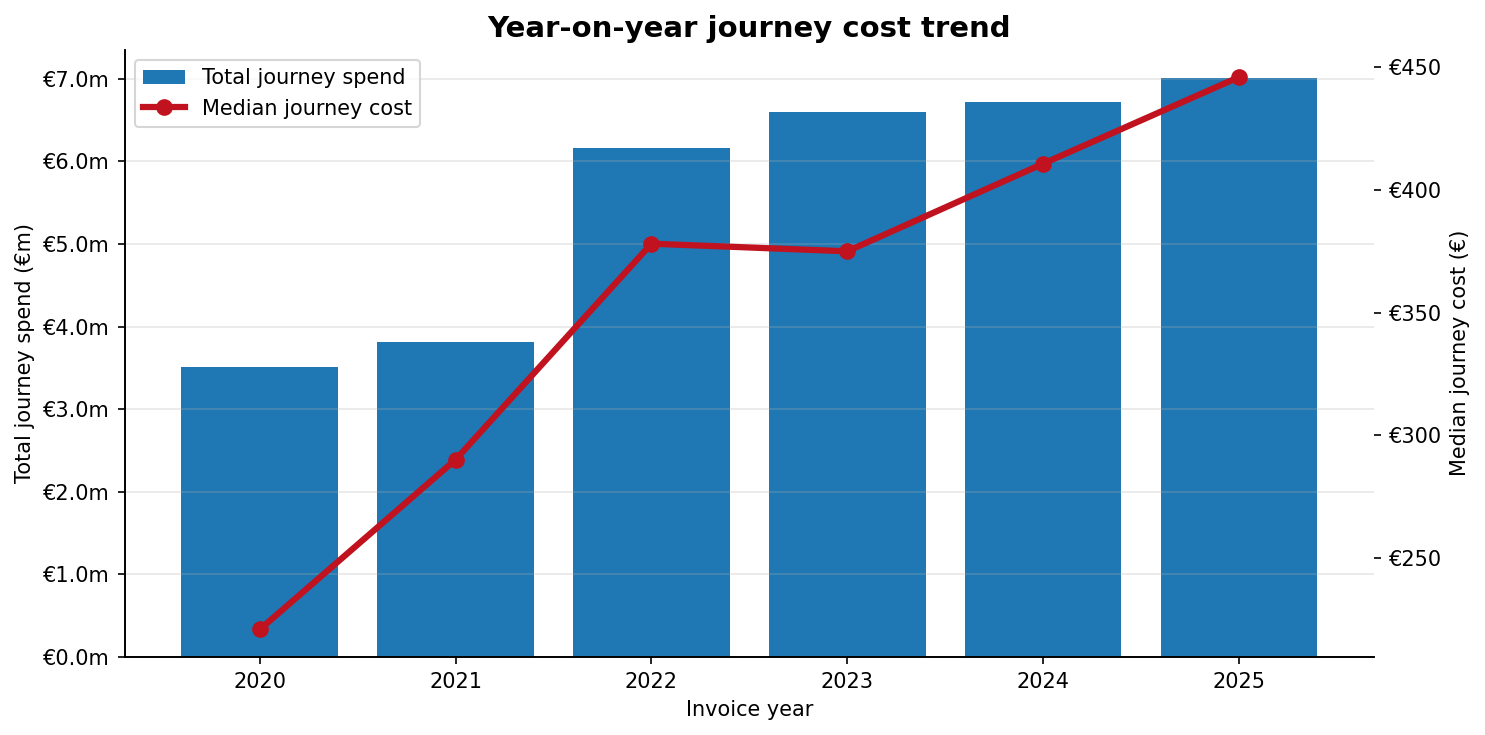

In [36]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart: total journey spend
ax1.bar(
    year_summary["year_label"],
    year_summary["total_journey_spend_m"],
    label="Total journey spend"
)

ax1.set_title("Year-on-year journey cost trend", fontsize=14, weight="bold")
ax1.set_xlabel("Invoice year")
ax1.set_ylabel("Total journey spend (€m)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"€{x:.1f}m"))
ax1.grid(axis="y", alpha=0.3)

# Line chart: median journey cost
ax2 = ax1.twinx()
ax2.plot(
    year_summary["year_label"],
    year_summary["median_journey_cost"],
    marker="o",
    linewidth=3,
    markersize=7,
    color="#C1121F",   # red line for stronger visibility
    label="Median journey cost"
)

ax2.set_ylabel("Median journey cost (€)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"€{x:,.0f}"))

# Combined legend
handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()

# Save updated output — this overwrites the previous PNG
plt.savefig("plot_1_yoy_journey_cost_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
DATA_PATH = "msf_combined.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
for col in ["total_invoice_amount","carbon_emissions_tco2e","flight_emission_kilometers",
            "rail_kilometers","advance_purchase_days","invoice_year","total_travelers"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
df["inv_date_parsed"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["invoice_month"]   = df["inv_date_parsed"].dt.month

# Filter out nan / DEFAULT regions globally
df = df[~df["destination_region"].isin(["nan","DEFAULT",""])].copy()
df = df[~df["origin_region"].isin(["nan","DEFAULT",""])].copy()

df["has_cancellation_flag"] = df["has_cancellation"].astype(str).str.strip() == "True"
df["has_exchange_flag"]     = df["has_exchange"].astype(str).str.strip()     == "True"
df["has_refund_flag"]       = df["has_refund"].astype(str).str.strip()       == "True"
df["is_disrupted"]          = (df["has_cancellation_flag"] | df["has_exchange_flag"] | df["has_refund_flag"])

# Journey categories:
# "Clean booking"           = journey only — no cancellation, exchange OR refund
# "With cancellation/exchange" = any journey that has at least one disruption flag
# Sub-categories retained for detail in breakdown tables
def categorise(row):
    c, e, r = row["has_cancellation_flag"], row["has_exchange_flag"], row["has_refund_flag"]
    if not c and not e and not r: return "Clean booking"
    if e and not c and not r:     return "Exchange only"
    if r and not c and not e:     return "Refund only"
    if c and not e and not r:     return "Cancellation only"
    if c and e:                   return "Cancellation + Exchange"
    return "Complex (mixed)"

df["journey_category"]     = df.apply(categorise, axis=1)
df["is_clean"]             = df["journey_category"] == "Clean booking"
df["has_disruption"]       = ~df["is_clean"]

fj_all = df[df["transaction_types"].str.contains("Final Journey", na=False)].copy()
fj_pos = fj_all[fj_all["total_invoice_amount"] > 0].copy()

print(f"Rows loaded     : {len(df):,}")
print(f"Total spend     : €{df['total_invoice_amount'].sum():,.0f}")
print(f"Clean bookings  : {df['is_clean'].sum():,}  ({df['is_clean'].mean()*100:.1f}%)")
print(f"With disruption : {df['has_disruption'].sum():,}  ({df['has_disruption'].mean()*100:.1f}%)")

Rows loaded     : 71,031
Total spend     : €40,347,945
Clean bookings  : 43,020  (60.6%)
With disruption : 28,011  (39.4%)


---
## Recommendation R3 — Q1 Mission Planning Review
**Focus:** Seasonal cancellation patterns show Q1 (January–March) has
consistently the highest cancellation rates in the portfolio.
Highlighting Q1 makes the case for a structured pre-year travel planning review.

### Table — Monthly cancellation and exchange rates

In [38]:
# ── TABLE 1.3: Monthly cancellation and exchange rates ────────────────────────
MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly = (
    fj_all[fj_all["invoice_month"].notna()]
    .groupby("invoice_month")
    .agg(
        total        =("traveler_journey_id","count"),
        cancellations=("has_cancellation_flag","sum"),
        exchanges    =("has_exchange_flag","sum"),
        total_spend  =("total_invoice_amount","sum"),
    )
    .reset_index()
)
monthly = monthly[monthly["invoice_month"].between(1,12)]
monthly["cancel_%"]   = monthly["cancellations"] / monthly["total"] * 100
monthly["exchange_%"] = monthly["exchanges"]     / monthly["total"] * 100
monthly["month_name"] = monthly["invoice_month"].astype(int).map(MONTH_NAMES)

print("=" * 75)
print("TABLE 1.3 — SEASONAL CANCELLATION AND EXCHANGE TRENDS (by invoice month)")
print("=" * 75)
print(f"{'Month':<6} {'Journeys':>10} {'Cancellations':>14} {'Cancel %':>10} "
      f"{'Exchanges':>11} {'Exchange %':>12}")
print("-" * 70)
for _, r in monthly.iterrows():
    print(f"{r['month_name']:<6} {r['total']:>10,} "
          f"{r['cancellations']:>14,.0f} {r['cancel_%']:>9.1f}% "
          f"{r['exchanges']:>11,.0f} {r['exchange_%']:>11.1f}%")

TABLE 1.3 — SEASONAL CANCELLATION AND EXCHANGE TRENDS (by invoice month)
Month    Journeys  Cancellations   Cancel %   Exchanges   Exchange %
----------------------------------------------------------------------
Jan         4,153            257       6.2%         114         2.7%
Feb         4,166            297       7.1%         118         2.8%
Mar         4,550            324       7.1%         128         2.8%
Apr         3,849            213       5.5%          92         2.4%
May         4,553            243       5.3%          96         2.1%
Jun         4,268            267       6.3%         101         2.4%
Jul         4,109            260       6.3%         105         2.6%
Aug         3,889            200       5.1%          87         2.2%
Sep         4,766            291       6.1%         111         2.3%
Oct         5,025            314       6.2%         112         2.2%
Nov         4,821            331       6.9%         137         2.8%
Dec         3,641           

---
> ### 🔄 Iteration — R3 Seasonal chart: percentage bars → absolute-count bars
>
> **First version:** Built as percentage-stacked bars — each bar showing cancellation % +
> exchange % stacked for each month.
>
> **Problem:** Because all months have similar rates (~5–7% cancel, ~2–2.8% exchange), every
> month bar appeared roughly the same height. A month with 6.2% + 2.7% and a month with
> 5.1% + 2.2% looked almost identical at this scale. The Q1 pattern was not visible.
> Facilitator feedback confirmed the chart was not communicating the finding.
>
> **What we changed:** Switched to absolute-count stacked bars (number of cancellations and
> exchanges per month) with rate % lines on a twin right axis. This shows both the higher
> absolute volume of disrupted journeys in Q1 AND the higher rate — combined, the Q1 story
> becomes unambiguous. Q1 bars use full colour (coral/navy), other months use faded variants
> to direct attention without removing context.


In [39]:
# ── FIRST VERSION (REMOVED): Percentage-stacked bars for R3 seasonal chart ─
# This was the initial chart design — replaced because Q1 pattern was invisible.

# fig, ax = plt.subplots(figsize=(13, 5.5))
# ax.bar(monthly['month_name'], monthly['cancel_%'],
#        color=cancel_colors, alpha=0.9, label='Cancellation %')
# ax.bar(monthly['month_name'], monthly['exchange_%'],
#        bottom=monthly['cancel_%'],
#        color=exchange_colors, alpha=0.9, label='Exchange %')
# ax.set_ylabel('Disruption rate (%)')
# ax.set_title('Seasonal disruption trends')
#
# PROBLEM: at this scale, bar heights were nearly identical across all months.
# Jan: 6.2% + 2.7% = 8.9%  |  Aug: 5.1% + 2.2% = 7.3%
# These appear almost the same height. Q1 did not stand out visually.
#
# Facilitator feedback: 'I can see all months look similar, what is the actual finding?'
#
# Fix: use absolute counts (number of disrupted journeys) on bars + rate % on twin axis.
# This shows Q1 has BOTH more disrupted journeys in volume AND a higher rate.


### Chart — Seasonal disruption trends (Q1 highlighted)

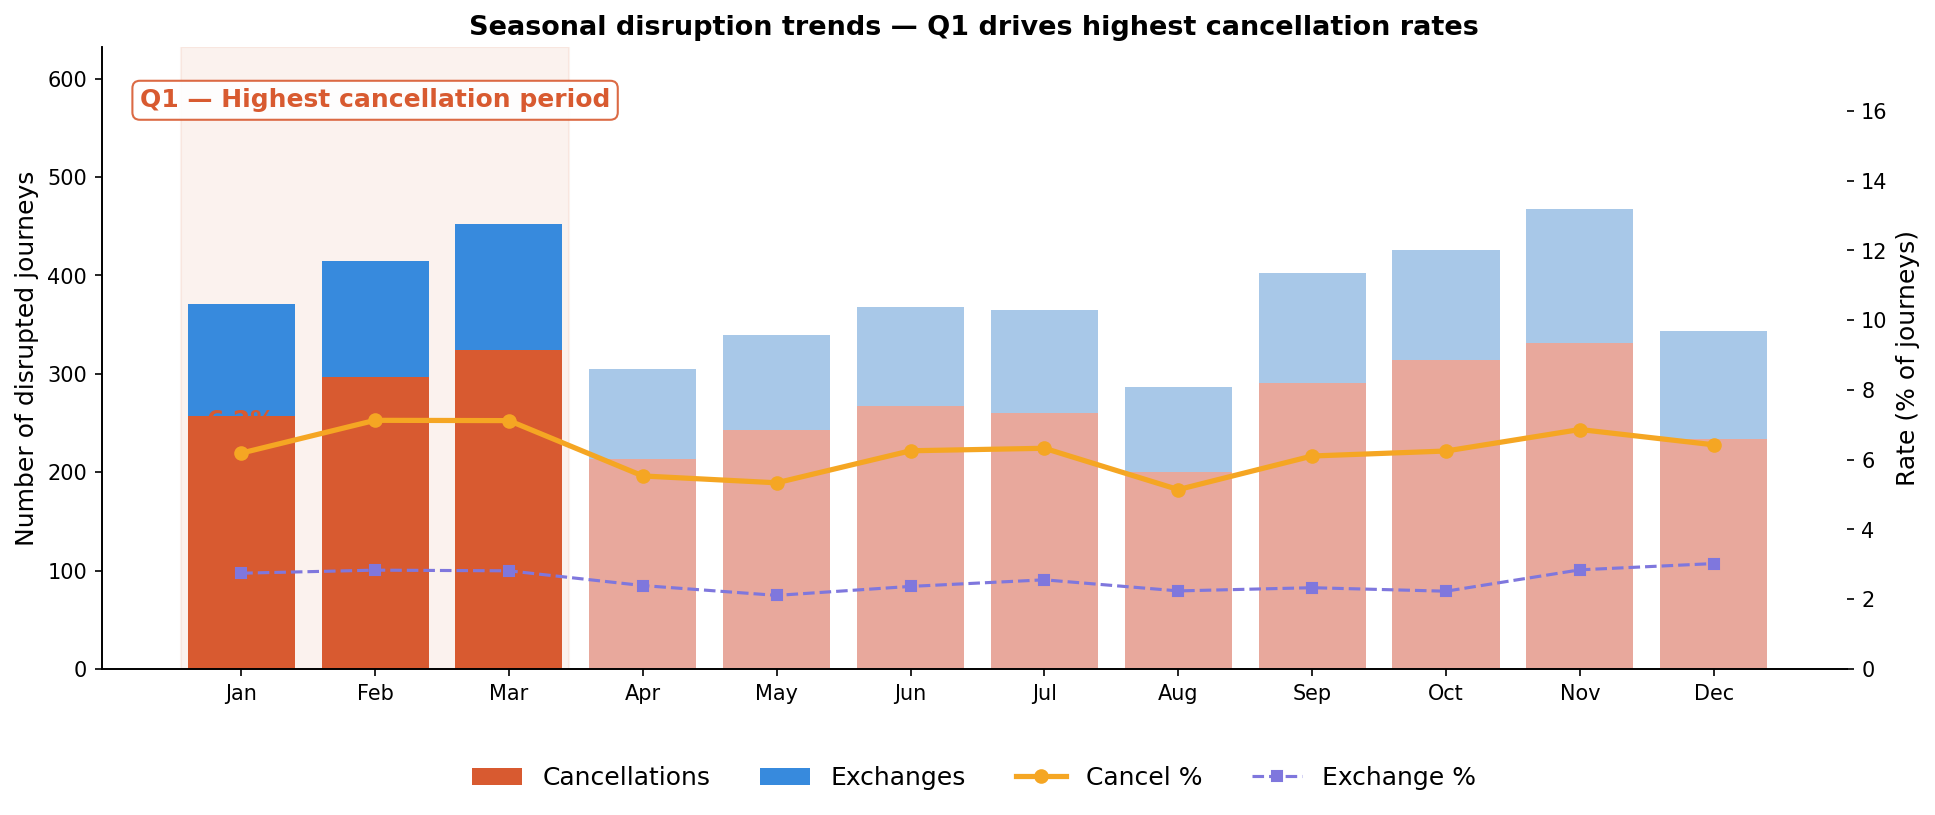

In [40]:
# ── CHART 1.3: Seasonal trends — Q1 highlighted ─────────────────────────────
Q1_MONTHS = ["Jan", "Feb", "Mar"]

cancel_colors   = [PALETTE["cancel"]   if m in Q1_MONTHS else "#E8A89C"
                   for m in monthly["month_name"]]
exchange_colors = [PALETTE["exchange"] if m in Q1_MONTHS else "#A8C8E8"
                   for m in monthly["month_name"]]

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.bar(monthly["month_name"], monthly["cancellations"],
       color=cancel_colors, alpha=1, label="Cancellations")
ax.bar(monthly["month_name"], monthly["exchanges"],
       bottom=monthly["cancellations"],
       color=exchange_colors, alpha=1, label="Exchanges")

# ── Q1 shaded region and label ────────────────────────────────────────────────
q1_idx = [i for i, m in enumerate(monthly["month_name"]) if m in Q1_MONTHS]
ax.axvspan(min(q1_idx) - 0.45, max(q1_idx) + 0.45,
           alpha=0.08, color=PALETTE["cancel"], zorder=0)

total_bar = (monthly["cancellations"] + monthly["exchanges"])
ax.set_ylim(0, total_bar.max() * 1.35)

ax.text(1.0, total_bar.max() * 1.22,
        "Q1 — Highest cancellation period",
        ha="center", fontsize=12, color=PALETTE["cancel"], fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=PALETTE["cancel"], alpha=0.9))

# ── Rate line ─────────────────────────────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(monthly["month_name"], monthly["cancel_%"],  "o-",
         color=PALETTE["highlight"], lw=2.5, ms=6, label="Cancel %",   zorder=5)
ax2.plot(monthly["month_name"], monthly["exchange_%"], "s--",
         color=PALETTE["refund"],   lw=1.5, ms=5, label="Exchange %", zorder=5)
ax2.set_ylabel("Rate (% of journeys)", fontsize=12)
ax2.set_ylim(0, monthly["cancel_%"].max() * 2.5)
ax2.spines["top"].set_visible(False)
ax2.tick_params(axis="y", labelsize=10)

# ── Q1 rate labels — staggered vertically to avoid overlap ───────────────────
offsets = [12, -14, 12]
for (_, row), offset in zip(
        monthly[monthly["month_name"].isin(Q1_MONTHS)].iterrows(), offsets):
    ax2.annotate(
        f"{row['cancel_%']:.1f}%",
        xy=(row["month_name"], row["cancel_%"]),
        xytext=(0, offset), textcoords="offset points",
        ha="center", fontsize=12, color=PALETTE["cancel"], fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=PALETTE["cancel"],
                        lw=0.8, alpha=0.5) if abs(offset) > 8 else None
    )

ax.set_ylabel("Number of disrupted journeys", fontsize=12)
ax.set_xlabel("")
ax.tick_params(axis="both", labelsize=10)
ax.set_title("Seasonal disruption trends — Q1 drives highest cancellation rates",
             fontsize=13, fontweight="bold")

# ── Legend at bottom centre ───────────────────────────────────────────────────
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2,
          fontsize=12, frameon=False,
          loc="upper center",
          bbox_to_anchor=(0.5, -0.12),
          ncol=4)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
#plt.savefig("chart_1_3_seasonal_q1.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Recommendation R1 — Cap Advance Bookings at 30 Days
**Focus:** Cancellation rate is stable (3.3–3.7%) for bookings made within 30 days
but rises sharply beyond — reaching 13.4% at 91+ days. The 30-day threshold
is the clear policy inflection point.

### Table — Cancellations by advance purchase band

In [41]:
# ── TABLE 1.4: Cancellations by APD band ──────────────────────────────────────
bins   = [0, 7, 14, 30, 60, 90, float("inf")]
labels = ["0–7d","8–14d","15–30d","31–60d","61–90d","91+d"]
apd_df = fj_pos[fj_pos["advance_purchase_days"].notna() &
                (fj_pos["advance_purchase_days"] >= 0)].copy()
apd_df["apd_band"] = pd.cut(apd_df["advance_purchase_days"],
                              bins=bins, labels=labels, right=True)
apd_cancel = (
    apd_df.groupby("apd_band", observed=True)
    .agg(
        total        =("traveler_journey_id","count"),
        cancellations=("has_cancellation_flag","sum"),
        exchanges    =("has_exchange_flag","sum"),
        total_spend  =("total_invoice_amount","sum"),
    )
    .reset_index()
)
apd_cancel["cancel_%"]   = apd_cancel["cancellations"] / apd_cancel["total"] * 100
apd_cancel["exchange_%"] = apd_cancel["exchanges"]     / apd_cancel["total"] * 100
apd_cancel["pct_trips"]  = apd_cancel["total"] / apd_cancel["total"].sum() * 100

print("=" * 80)
print("TABLE 1.4 — CANCELLATIONS BY ADVANCE PURCHASE BAND")
print("Which booking windows generate the most cancellations?")
print("=" * 80)
print(f"{'APD band':<12} {'Total trips':>12} {'% of trips':>11} {'Cancellations':>14} "
      f"{'Cancel %':>10} {'Exchanges':>11} {'Exchange %':>12}")
print("-" * 80)
for _, r in apd_cancel.iterrows():
    print(f"{str(r['apd_band']):<12} {r['total']:>12,} {r['pct_trips']:>10.1f}% "
          f"{r['cancellations']:>14,.0f} {r['cancel_%']:>9.1f}% "
          f"{r['exchanges']:>11,.0f} {r['exchange_%']:>11.1f}%")

TABLE 1.4 — CANCELLATIONS BY ADVANCE PURCHASE BAND
Which booking windows generate the most cancellations?
APD band      Total trips  % of trips  Cancellations   Cancel %   Exchanges   Exchange %
--------------------------------------------------------------------------------
0–7d               16,215       35.5%            597       3.7%         300         1.9%
8–14d               8,933       19.6%            295       3.3%         174         1.9%
15–30d             10,196       22.3%            374       3.7%         218         2.1%
31–60d              6,044       13.2%            255       4.2%         155         2.6%
61–90d              1,731        3.8%             89       5.1%          52         3.0%
91+d                2,513        5.5%            337      13.4%         225         9.0%


### Chart — Cancellation rate by booking lead time (30-day threshold)

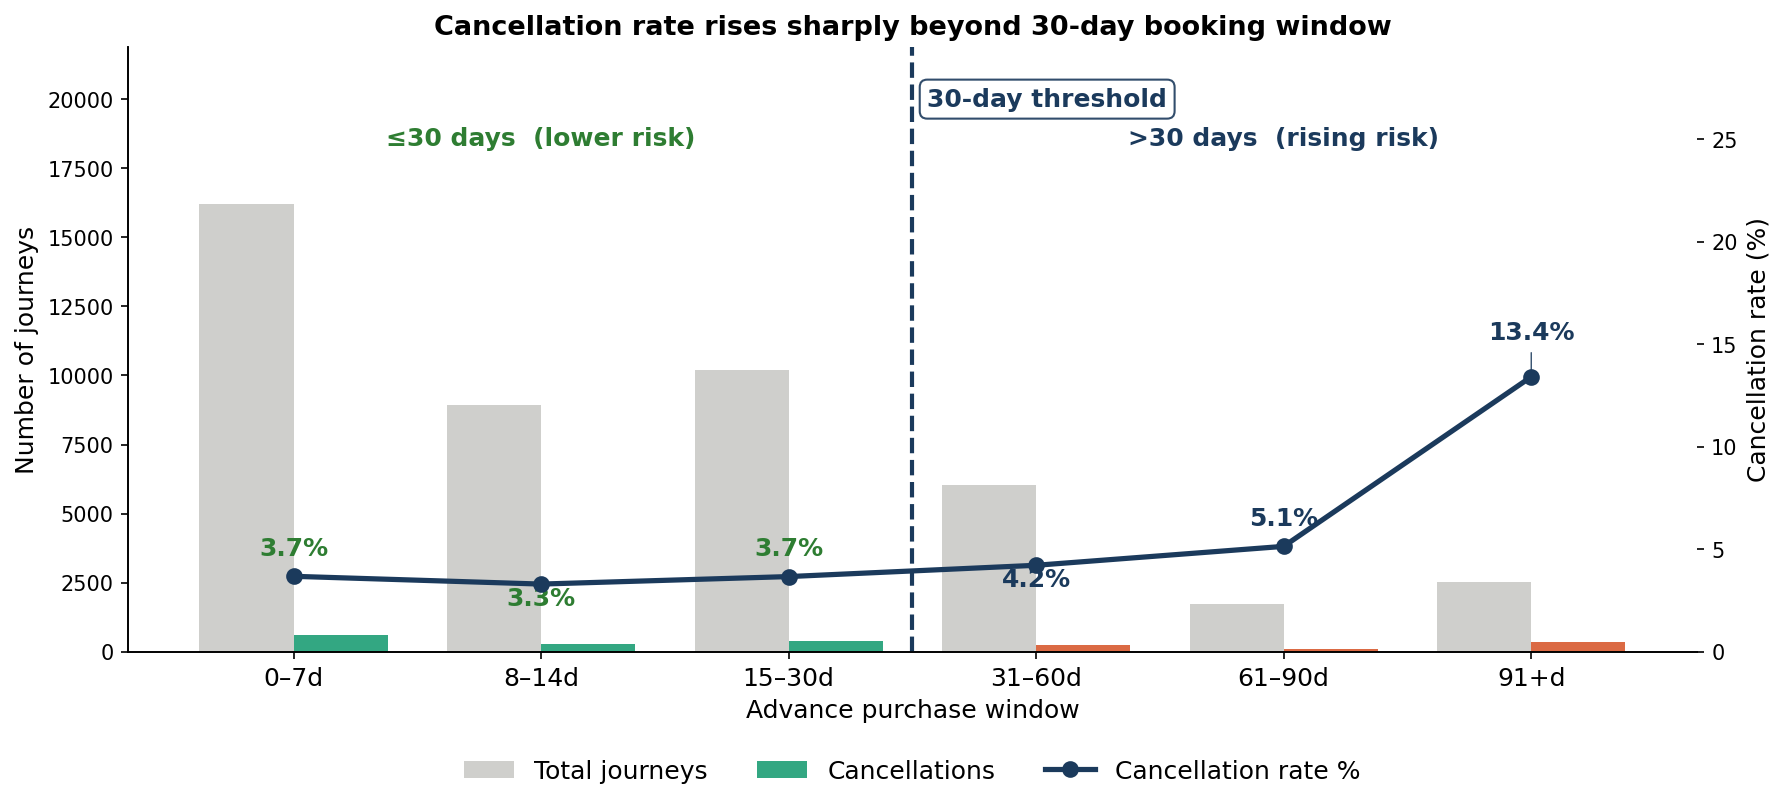

In [42]:
# ── CHART 1.4: Cancellations by APD band — 30-day threshold highlighted ─────
SAFE_BANDS    = ["0–7d", "8–14d", "15–30d"]
WARNING_BANDS = ["31–60d", "61–90d", "91+d"]
DARK_BLUE     = "#1B3A5C"

bar_colors = [PALETTE["clean"] if str(b) in SAFE_BANDS else PALETTE["cancel"]
              for b in apd_cancel["apd_band"]]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(apd_cancel))
w = 0.38

ax.bar(x - w/2, apd_cancel["total"],         w,
       color=PALETTE["neutral"], alpha=0.4, label="Total journeys")
ax.bar(x + w/2, apd_cancel["cancellations"], w,
       color=bar_colors, alpha=0.9, label="Cancellations")

# ── Set y-limits with headroom BEFORE any text placement ─────────────────────
ax.set_ylim(0, apd_cancel["total"].max() * 1.35)

# ── 30-day threshold line + label (dark blue) ─────────────────────────────────
threshold_x = 2.5
ax.axvline(threshold_x, color=DARK_BLUE, lw=2, ls="--", zorder=5)
ax.text(threshold_x + 0.06,
        apd_cancel["total"].max() * 1.26,
        "30-day threshold", ha="left", va="top",
        fontsize=12, color=DARK_BLUE, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=DARK_BLUE, alpha=0.9))

# ── Region labels ─────────────────────────────────────────────────────────────
ax.text(1.0, apd_cancel["total"].max() * 1.13,
        "≤30 days  (lower risk)",
        ha="center", fontsize=12, color="#2E7D32", fontweight="bold")
ax.text(4.0, apd_cancel["total"].max() * 1.13,
        ">30 days  (rising risk)",
        ha="center", fontsize=12, color=DARK_BLUE, fontweight="bold")

# ── Rate line ─────────────────────────────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(x, apd_cancel["cancel_%"], "o-",
         color=DARK_BLUE, lw=2.5, ms=7, label="Cancellation rate %", zorder=6)
ax2.set_ylabel("Cancellation rate (%)", fontsize=12)
ax2.set_ylim(0, apd_cancel["cancel_%"].max() * 2.2)
ax2.spines["top"].set_visible(False)
ax2.tick_params(axis="y", labelsize=10)

ax.set_xticks(x)
ax.set_xticklabels(apd_cancel["apd_band"].astype(str), fontsize=12)
ax.set_ylabel("Number of journeys", fontsize=12)
ax.set_xlabel("Advance purchase window", fontsize=12)
ax.tick_params(axis="y", labelsize=10)
ax.set_title("Cancellation rate rises sharply beyond 30-day booking window",
             fontsize=13, fontweight="bold")

# ── Rate % labels — dark blue for warning bands, green for safe bands ─────────
offsets = [10, -10, 10, -10, 10, 18]
for i, (_, r) in enumerate(apd_cancel.iterrows()):
    col = DARK_BLUE if str(r["apd_band"]) in WARNING_BANDS else "#2E7D32"
    ax2.annotate(
        f"{r['cancel_%']:.1f}%",
        xy=(i, r["cancel_%"]),
        xytext=(0, offsets[i]), textcoords="offset points",
        ha="center", fontsize=12, color=col, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=col, lw=0.6)
        if abs(offsets[i]) > 12 else None
    )

# ── Legend at bottom centre ───────────────────────────────────────────────────
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2,
          fontsize=12, frameon=False,
          loc="upper center",
          bbox_to_anchor=(0.5, -0.14),
          ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
#plt.savefig("chart_1_4_apd_30day.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Recommendation R2 — Default Refundable Fares for Uncertain Missions
**Focus:** Non-refundable tickets cancel at 9.2% and exchange at 6.4% —
materially higher than refundable equivalents (6.1% and 2.4%).
The premium of +3.1pp cancellation and +4.0pp exchange makes the case
for defaulting to refundable fares where mission certainty is low.

### Table — Refundable vs Non-Refundable: disruption rates

In [43]:
# ── TABLE 1.8: Refundable vs non-refundable ───────────────────────────────────
ref = (
    fj_all[fj_all["refundable_indicator"].notna() &
            (~fj_all["refundable_indicator"].isin(["nan",""]))]
    .groupby("refundable_indicator")
    .agg(
        journeys     =("traveler_journey_id","count"),
        cancellations=("has_cancellation_flag","sum"),
        exchanges    =("has_exchange_flag","sum"),
        total_spend  =("total_invoice_amount","sum"),
    )
    .reset_index()
)
ref["cancel_%"]   = ref["cancellations"] / ref["journeys"] * 100
ref["exchange_%"] = ref["exchanges"]     / ref["journeys"] * 100

# Weighted cancellation %: cancellations as % of total cancellations across both groups
total_cancels   = ref["cancellations"].sum()
total_exchanges = ref["exchanges"].sum()
ref["wtd_cancel_%"]   = ref["cancellations"] / total_cancels   * 100
ref["wtd_exchange_%"] = ref["exchanges"]     / total_exchanges * 100

print("=" * 85)
print("TABLE 1.8 — REFUNDABLE vs NON-REFUNDABLE: DISRUPTION RATES")
print("=" * 85)
print(f"{'Ticket type':<22} {'Journeys':>10} {'Journeys %':>11} "
      f"{'Cancel %':>10} {'Wtd Cancel %':>14} "
      f"{'Exchange %':>12} {'Wtd Exchange %':>15}")
print("-" * 95)
total_j = ref["journeys"].sum()
for _, r in ref.iterrows():
    print(f"{r['refundable_indicator']:<22} {r['journeys']:>10,} "
          f"{r['journeys']/total_j*100:>10.1f}% "
          f"{r['cancel_%']:>9.1f}% {r['wtd_cancel_%']:>13.1f}% "
          f"{r['exchange_%']:>11.1f}% {r['wtd_exchange_%']:>14.1f}%")

print()
print("Key KPI — weighted cancellation share:")
nr_row = ref[ref["refundable_indicator"]=="Non-Refundable"].iloc[0]
rf_row = ref[ref["refundable_indicator"]=="Refundable"].iloc[0]
print(f"  Non-Refundable = {nr_row['journeys']/total_j*100:.1f}% of all tickets "
      f"but accounts for {nr_row['wtd_cancel_%']:.1f}% of all cancellations")
print(f"  Refundable     = {rf_row['journeys']/total_j*100:.1f}% of all tickets "
      f"but accounts for {rf_row['wtd_cancel_%']:.1f}% of all cancellations")
print()
print("Interpretation:")
print(f"  A Non-Refundable ticket is {nr_row['cancel_%']/rf_row['cancel_%']:.1f}x more likely to be cancelled "
      f"than a Refundable ticket")
print(f"  A Non-Refundable ticket is {nr_row['exchange_%']/rf_row['exchange_%']:.1f}x more likely to be exchanged "
      f"than a Refundable ticket")


TABLE 1.8 — REFUNDABLE vs NON-REFUNDABLE: DISRUPTION RATES
Ticket type              Journeys  Journeys %   Cancel %   Wtd Cancel %   Exchange %  Wtd Exchange %
-----------------------------------------------------------------------------------------------
Non-Refundable              1,980        3.8%       9.2%           5.7%         6.4%            9.6%
Refundable                 49,810       96.2%       6.1%          94.3%         2.4%           90.4%

Key KPI — weighted cancellation share:
  Non-Refundable = 3.8% of all tickets but accounts for 5.7% of all cancellations
  Refundable     = 96.2% of all tickets but accounts for 94.3% of all cancellations

Interpretation:
  A Non-Refundable ticket is 1.5x more likely to be cancelled than a Refundable ticket
  A Non-Refundable ticket is 2.7x more likely to be exchanged than a Refundable ticket


---
> ### 🔄 Iteration — R2 Refundable chart: curved arrows → bracket-span callouts
>
> **First version:** Used `ax.annotate()` with `connectionstyle='arc3'` to draw curved arrows
> from "+3.1pp" and "+4.0pp" callout boxes to the relevant Non-Refundable bars.
>
> **Problem:** The arrow tips needed to point at bar tops, but bar tops already had value labels
> (9.2%, 6.4%) placed just above them. Every arrow tip position either overlapped the value
> label or, when moved, the arc curve passed through another bar. Multiple `xytext` adjustments
> all moved the overlap to a different location rather than eliminating it.
>
> **What we changed:** Replaced all curved arrows with bracket-span callouts: a horizontal line
> spanning from the Non-Refundable bar to the Refundable bar, tick marks at each end, and the
> delta label centred above the line. No arrow tips means nothing can land on the value labels.


In [44]:
# ── FIRST VERSION (REMOVED): Curved arrow callouts for R2 refundable chart ─
# This design was replaced because arrows overlapped the bar value labels.

# ax.annotate(
#     f'+{nr_cancel - r_cancel:.1f}pp cancellation premium',
#     xy=(x[0] - w/2, nr_cancel + 0.3),      # arrow tip: above Non-Ref cancel bar
#     xytext=(x[0] + 0.55, nr_cancel + 5.0), # box: shifted right
#     ha='left', fontsize=10, fontweight='bold', color=NONREF_COLOR,
#     bbox=dict(boxstyle='round,pad=0.35', facecolor='#FDECEA',
#               edgecolor=NONREF_COLOR, alpha=0.95),
#     arrowprops=dict(arrowstyle='->', color=NONREF_COLOR, lw=1.2,
#                     connectionstyle='arc3,rad=-0.25')
# )
#
# PROBLEM: arrow tip at xy=(x[0]-w/2, nr_cancel+0.3) landed on top of '9.2%' label.
# Moving xytext further right made the arc curve through the exchange bar.
# Moving tip lower hid the connection to the relevant bar.
# No position worked cleanly with curved arcs.
#
# Fix: bracket-span callout — horizontal line spanning both bars, no arrow tips.
# See Chart 1.8 in analysis section for final implementation.


### Chart — Disruption rates by ticket type (KPI callouts)

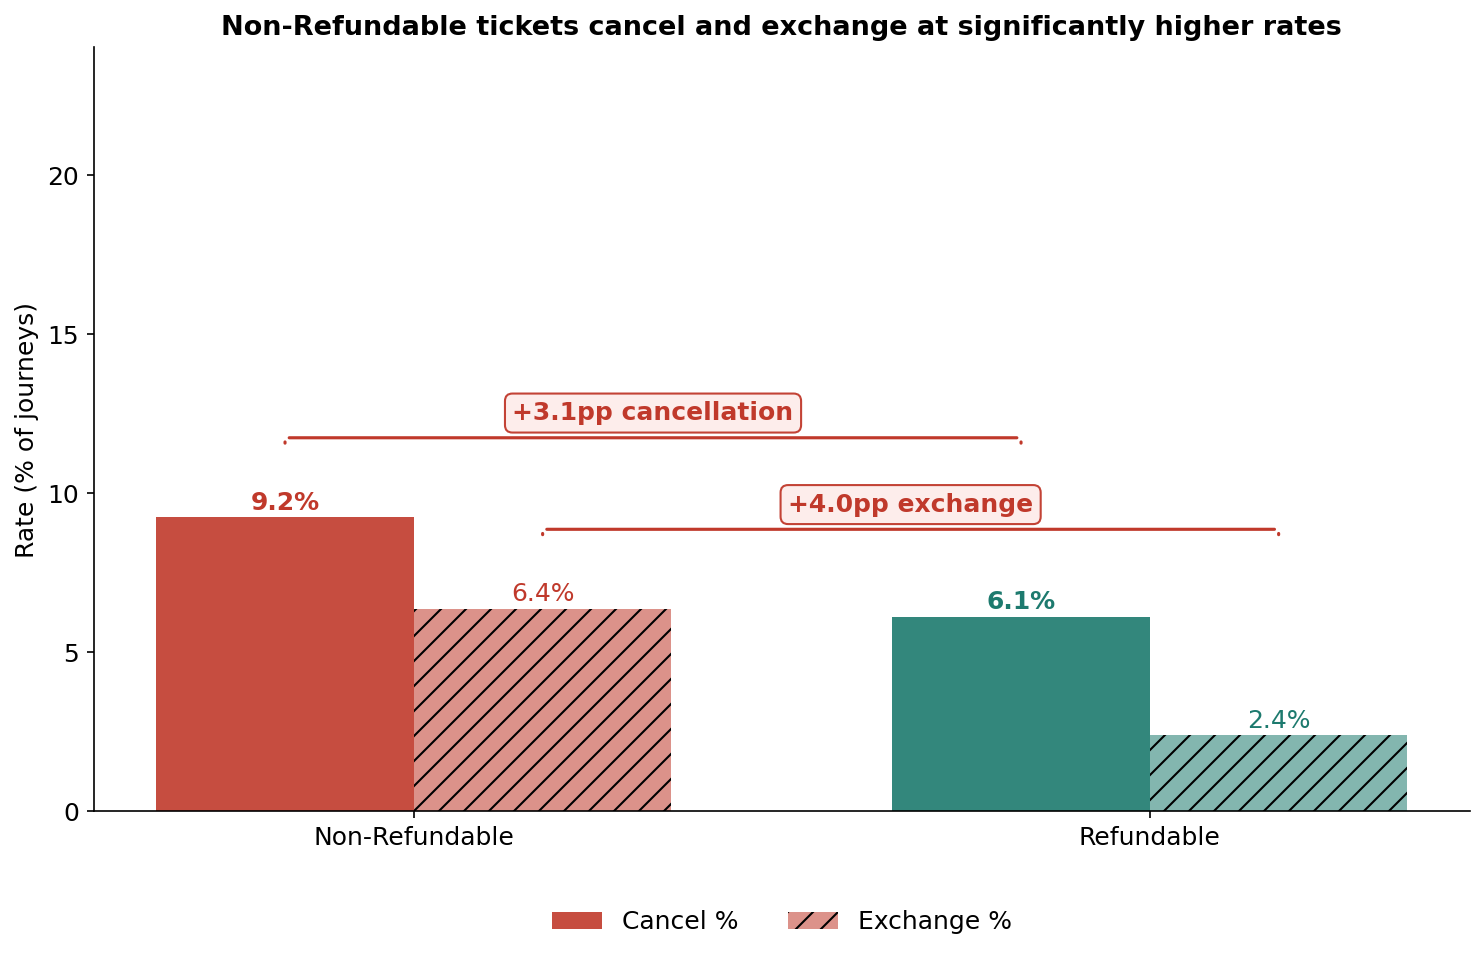

In [45]:
# ── CHART 1.8: Refundable vs Non-Refundable — colours + KPI callouts ────────
REF_COLOR    = "#1D7A6E"
NONREF_COLOR = "#C0392B"

fig, ax = plt.subplots(figsize=(10, 6.5))

x = np.arange(len(ref))
w = 0.35

ax.bar(x - w/2, ref["cancel_%"],   w,
       color=[NONREF_COLOR if "Non" in str(r) else REF_COLOR
              for r in ref["refundable_indicator"]],
       alpha=0.9, label="Cancel %")
ax.bar(x + w/2, ref["exchange_%"], w,
       color=[NONREF_COLOR if "Non" in str(r) else REF_COLOR
              for r in ref["refundable_indicator"]],
       alpha=0.55, label="Exchange %", hatch="//")

ax.set_xticks(x)
ax.set_xticklabels(ref["refundable_indicator"], fontsize=12)
ax.set_ylabel("Rate (% of journeys)", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# ── Collect key values ────────────────────────────────────────────────────────
nr_cancel = ref[ref["refundable_indicator"] == "Non-Refundable"]["cancel_%"].values[0]
r_cancel  = ref[ref["refundable_indicator"] == "Refundable"]["cancel_%"].values[0]
nr_exch   = ref[ref["refundable_indicator"] == "Non-Refundable"]["exchange_%"].values[0]
r_exch    = ref[ref["refundable_indicator"] == "Refundable"]["exchange_%"].values[0]

# ── ylim with room for labels AND callout boxes above ────────────────────────
max_rate = max(nr_cancel, nr_exch)
ax.set_ylim(0, max_rate * 2.6)

# ── Bar value labels ──────────────────────────────────────────────────────────
for i, (_, r) in enumerate(ref.iterrows()):
    col = NONREF_COLOR if "Non" in str(r["refundable_indicator"]) else REF_COLOR
    ax.text(i - w/2, r["cancel_%"] + 0.25,
            f"{r['cancel_%']:.1f}%",
            ha="center", fontsize=12, fontweight="bold", color=col)
    ax.text(i + w/2, r["exchange_%"] + 0.25,
            f"{r['exchange_%']:.1f}%",
            ha="center", fontsize=12, color=col)

# ── KPI callouts: clean horizontal comparison lines (no curved arrows) ────────
# Strategy: draw a straight horizontal line spanning Non-Ref to Ref bar for each
# metric, with the delta label centred above the line. Uses ax.annotate with
# arrowstyle="-" (plain line, no arrowhead) for the spanning line, plus a
# plain text label above it. This avoids all arc/curve rendering issues.

def draw_span_callout(ax, x_left, x_right, y_line, label, color):
    """Draw a horizontal bracket between two x positions with a centred label."""
    x_mid = (x_left + x_right) / 2
    # Horizontal line
    ax.annotate("",
        xy=(x_right, y_line), xytext=(x_left, y_line),
        arrowprops=dict(arrowstyle="-", color=color, lw=1.5))
    # Left tick
    ax.annotate("",
        xy=(x_left,  y_line - 0.3), xytext=(x_left,  y_line),
        arrowprops=dict(arrowstyle="-", color=color, lw=1.5))
    # Right tick
    ax.annotate("",
        xy=(x_right, y_line - 0.3), xytext=(x_right, y_line),
        arrowprops=dict(arrowstyle="-", color=color, lw=1.5))
    # Label above line
    ax.text(x_mid, y_line + 0.4, label,
            ha="center", va="bottom", fontsize=12,
            fontweight="bold", color=color,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FDECEA",
                      edgecolor=color, alpha=0.95))

# Cancellation span: Non-Ref cancel bar  ←→  Ref cancel bar
cancel_span_y  = max(nr_cancel, r_cancel) + 2.5
exchange_span_y= max(nr_exch,   r_exch)   + 2.5

draw_span_callout(ax,
    x_left  = x[0] - w/2,   # Non-Refundable cancel bar centre
    x_right = x[1] - w/2,   # Refundable cancel bar centre
    y_line  = cancel_span_y,
    label   = f"+{nr_cancel - r_cancel:.1f}pp cancellation",
    color   = NONREF_COLOR)

draw_span_callout(ax,
    x_left  = x[0] + w/2,   # Non-Refundable exchange bar centre
    x_right = x[1] + w/2,   # Refundable exchange bar centre
    y_line  = exchange_span_y,
    label   = f"+{nr_exch - r_exch:.1f}pp exchange",
    color   = NONREF_COLOR)

ax.set_title("Non-Refundable tickets cancel and exchange at significantly higher rates",
             fontsize=13, fontweight="bold")

# ── Legend at bottom centre ───────────────────────────────────────────────────
ax.legend(fontsize=12, frameon=False,
          loc="upper center",
          bbox_to_anchor=(0.5, -0.10),
          ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
#plt.savefig("chart_1_8_refundable_updated.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Recommendation R4 — Mandate Rail for Plannable European Routes
**Focus:** 3,229 intra-European Air trips (Group 2) have no Rail equivalent
in MSF's travel data. Analysis of their haul profile and booking lead time
shows that a majority were booked with sufficient notice to use Rail.

---
> ### 🔄 Iteration — European Air filter: origin/destination region → itinerary-level IATA
>
> **What we tried first:** Filter for rows where both `origin_region == 'EUROPE'` and
> `destination_region == 'EUROPE'`.
>
> **Why it failed:** These fields represent only the start and end city of the canonical O&D —
> not intermediate stops. A journey `CDG/BGF/ZYR` (Paris→Bangui, CAR→Brussels) showed
> `origin_region = EUROPE` and `destination_region = EUROPE` because Paris and Brussels are
> European, but contained `BGF` (Bangui) as a non-European stop — incorrectly classified as
> intra-European with no Rail substitution story. Additionally, the region lookup itself had
> data quality issues: BCN (Barcelona) was mapped to ASIA/PACIFIC in the source data.
>
> **What we changed:** Parse every individual IATA code from the raw itinerary string and check
> each against a majority-region lookup built from the data itself. Any itinerary containing
> even one confirmed non-European code is excluded entirely.


In [46]:
# ── ATTEMPT 1 (REMOVED): origin_region + destination_region filter ────────
# First approach to identifying intra-European Air journeys.

# air_european_v1 = air[
#     (air['origin_region'] == 'EUROPE') &
#     (air['destination_region'] == 'EUROPE')
# ].copy()
# print(f"V1 filter: {len(air_european_v1):,} journeys classified as intra-European")
#
# BUG: multi-leg field missions incorrectly included
# air_european_v1[air_european_v1['itinerary'].str.contains('BGF|FIH|ADD', na=False)].head()
# → Showed Bangui, Kinshasa, Addis Ababa in itineraries classified as European
#
# ALSO: BCN (Barcelona) was mapped to ASIA/PACIFIC in source data:
# air[air['corrected_origin']=='BCN']['origin_region'].value_counts()
# ASIA/PACIFIC    12
# → Barcelona↔Brussels was being excluded from intra-European analysis
#
# Fix: itinerary-level IATA code filter with majority-region lookup (see Step 4.0 in R4)


### 4.0 — Data preparation: European group classification

In [47]:
# ── FA6 data preparation ──────────────────────────────────────────────────────
for col in ["carbon_emissions_tco2e","flight_emission_kilometers",
            "rail_kilometers","total_invoice_amount","advance_purchase_days"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

fj   = df[df["transaction_types"].str.contains("Final Journey", na=False) &
          (df["total_invoice_amount"] > 0)].copy()
air  = fj[fj["record_types"] == "Air"].copy()
rail = fj[fj["record_types"] == "Rail"].copy()

# ── Build IATA → region lookup from the data ──────────────────────────────────
# We use majority-region voting: a code is European only if it appears MORE often
# as a journey origin/destination with origin_region = EUROPE than non-EUROPE.
# This handles corrupted mappings (e.g. BCN mapped to ASIA/PACIFIC in the raw data).

_iata_euro_n = {}
_iata_non_n  = {}

for _, row in df[["corrected_origin","origin_region"]].dropna().iterrows():
    code = str(row["corrected_origin"]).strip()
    reg  = str(row["origin_region"]).strip()
    if len(code) != 3 or reg in ["nan","DEFAULT",""]: continue
    if reg == "EUROPE":
        _iata_euro_n[code] = _iata_euro_n.get(code, 0) + 1
    else:
        _iata_non_n[code]  = _iata_non_n.get(code,  0) + 1

for _, row in df[["corrected_destination","destination_region"]].dropna().iterrows():
    code = str(row["corrected_destination"]).strip()
    reg  = str(row["destination_region"]).strip()
    if len(code) != 3 or reg in ["nan","DEFAULT",""]: continue
    if reg == "EUROPE":
        _iata_euro_n[code] = _iata_euro_n.get(code, 0) + 1
    else:
        _iata_non_n[code]  = _iata_non_n.get(code,  0) + 1

# A code is confirmed non-European if it has more non-European appearances than European
CONFIRMED_NON_EURO = {
    code for code in set(list(_iata_euro_n.keys()) + list(_iata_non_n.keys()))
    if _iata_non_n.get(code, 0) > _iata_euro_n.get(code, 0)
}

# Codes with zero European appearances are also non-European
CONFIRMED_NON_EURO |= {code for code in _iata_non_n if code not in _iata_euro_n}

print(f"Confirmed non-European IATA codes: {len(CONFIRMED_NON_EURO)}")

# ── Itinerary-based European filter ───────────────────────────────────────────
# A journey is confirmed intra-European only if NONE of its IATA codes is a
# confirmed non-European code. Unknown codes (mid-stops not in the lookup)
# are treated as European (safe default — they are typically European rail
# station codes not appearing as journey origins or destinations).

def is_fully_european(itin):
    """True if no confirmed non-European IATA code appears in the itinerary."""
    if pd.isna(itin) or str(itin).strip() in ["nan", ""]: return False
    tokens = re.split(r"[-/\\*]", str(itin).strip())
    codes  = [t.strip() for t in tokens if len(t.strip()) == 3]
    return bool(codes) and not any(code in CONFIRMED_NON_EURO for code in codes)

air["is_fully_european"]  = air["itinerary"].apply(is_fully_european)
rail["is_fully_european"] = rail["itinerary"].apply(is_fully_european)

air_euro  = air[air["is_fully_european"]].copy()
rail_euro = rail[rail["is_fully_european"]].copy()

for frame in [air_euro, rail_euro]:
    frame["route_key"] = (frame["corrected_origin"].fillna("") + "/" +
                          frame["corrected_destination"].fillna(""))

# ── Group 1 & 2: point-to-point (origin city ≠ destination city) ─────────────
air_p2p  = air_euro[air_euro["corrected_origin"] != air_euro["corrected_destination"]].copy()
rail_p2p = rail_euro[rail_euro["corrected_origin"] != rail_euro["corrected_destination"]].copy()

shared  = set(air_p2p["route_key"].unique()) & set(rail_p2p["route_key"].unique())
air_g1  = air_p2p[air_p2p["route_key"].isin(shared)].copy()
air_g2  = air_p2p[~air_p2p["route_key"].isin(shared)].copy()
rail_shared = rail_p2p[rail_p2p["route_key"].isin(shared)].copy()

# ── Group 3: round/circle trips (origin = destination city, all stops European) ──
def parse_mid(itin, origin):
    if pd.isna(itin): return np.nan
    tokens = re.split(r"[-/\\]", str(itin).strip())
    tokens = [t.strip() for t in tokens if len(t.strip()) == 3]
    mids   = [t for t in tokens if t != origin]
    return mids[0] if mids else np.nan

air_g3 = air_euro[air_euro["corrected_origin"] == air_euro["corrected_destination"]].copy()
air_g3["mid_stop"]   = air_g3.apply(lambda r: parse_mid(r["itinerary"], r["corrected_origin"]), axis=1)
air_g3["loop_route"] = (air_g3["corrected_origin"] + "→" +
                         air_g3["mid_stop"].fillna("?") + "→" +
                         air_g3["corrected_origin"])

# ── Aggregation helper ─────────────────────────────────────────────────────────
def agg_route(frame, key_col="route_key"):
    return (
        frame.groupby(key_col)
        .agg(
            journeys      =("traveler_journey_id",      "count"),
            total_spend   =("total_invoice_amount",      "sum"),
            avg_spend     =("total_invoice_amount",      "mean"),
            total_carbon  =("carbon_emissions_tco2e",    "sum"),
            avg_carbon    =("carbon_emissions_tco2e",    "mean"),
            origin_country=("origin_country",
                            lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else ""),
            dest_country  =("destination_country",
                            lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else ""),
        )
        .reset_index()
    )

air_agg  = agg_route(air_g1)
rail_agg = agg_route(rail_shared)
modal    = air_agg.merge(rail_agg, on="route_key", suffixes=("_air","_rail"))
modal    = modal[(modal["journeys_air"] >= 3) & (modal["journeys_rail"] >= 3)].copy()

modal["spend_saving_pp"]       = modal["avg_spend_air"]  - modal["avg_spend_rail"]
modal["carbon_saving_pp"]      = modal["avg_carbon_air"] - modal["avg_carbon_rail"]
modal["potential_spend_save"]  = modal["spend_saving_pp"]  * modal["journeys_air"]
modal["potential_carbon_save"] = modal["carbon_saving_pp"] * modal["journeys_air"]
modal["pct_spend_saving"]      = modal["spend_saving_pp"]  / modal["avg_spend_air"]  * 100
modal["pct_carbon_saving"]     = modal["carbon_saving_pp"] / modal["avg_carbon_air"] * 100

viable = modal[
    (modal["spend_saving_pp"]  > 0) &
    (modal["carbon_saving_pp"] > 0)
].sort_values("potential_spend_save", ascending=False)

no_rail_agg = agg_route(air_g2)
no_rail_agg = no_rail_agg[no_rail_agg["journeys"] >= 5].sort_values("total_spend", ascending=False)

# Group 3 aggregation with avg APD, air and rail trip counts
rail_loop_counts = (
    rail_euro[rail_euro["corrected_origin"] == rail_euro["corrected_destination"]]
    .groupby("corrected_origin")
    .agg(rail_trips=("traveler_journey_id","count"))
    .reset_index()
    .rename(columns={"corrected_origin":"origin_hub"})
)
rnd_agg = (
    air_g3.groupby("loop_route")
    .agg(
        air_trips     =("traveler_journey_id","count"),
        total_spend   =("total_invoice_amount","sum"),
        avg_spend     =("total_invoice_amount","mean"),
        avg_carbon    =("carbon_emissions_tco2e","mean"),
        avg_apd       =("advance_purchase_days","mean"),
        origin_country=("origin_country",
                        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else ""),
        mid_country   =("destination_country",
                        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else ""),
    )
    .reset_index()
)
rnd_agg["origin_hub"] = rnd_agg["loop_route"].str.split("→").str[0]
rnd_agg = rnd_agg.merge(rail_loop_counts, on="origin_hub", how="left")
rnd_agg["rail_trips"] = rnd_agg["rail_trips"].fillna(0).astype(int)
rnd_agg = rnd_agg[rnd_agg["air_trips"] >= 5].sort_values("total_spend", ascending=False)

total_euro_air = len(air_p2p) + len(air_g3)
print(f"\nItinerary-based European filter applied:")
print(f"  All IATA codes in itinerary checked — any confirmed non-European stop = excluded")
print(f"  Multi-leg journeys like CDG→BGF→ZYR are correctly excluded")
print(f"  Barcelona (BCN), Vienna (VIE), Lisbon (LIS) etc. correctly included")
print(f"\nGroup 1 (shared corridors, Rail exists) : {len(air_g1):,} Air  |  {len(rail_shared):,} Rail")
print(f"Group 2 (no Rail equivalent, p2p)       : {len(air_g2):,} Air trips")
print(f"Group 3 (intra-European round/circle)    : {len(air_g3):,} Air trips")
print(f"Total confirmed intra-European Air       : {total_euro_air:,}")

Confirmed non-European IATA codes: 462

Itinerary-based European filter applied:
  All IATA codes in itinerary checked — any confirmed non-European stop = excluded
  Multi-leg journeys like CDG→BGF→ZYR are correctly excluded
  Barcelona (BCN), Vienna (VIE), Lisbon (LIS) etc. correctly included

Group 1 (shared corridors, Rail exists) : 31 Air  |  2,279 Rail
Group 2 (no Rail equivalent, p2p)       : 3,230 Air trips
Group 3 (intra-European round/circle)    : 2,433 Air trips
Total confirmed intra-European Air       : 5,694


### Table — Group 2: haul category and APD profile

In [48]:
# APD bands used throughout this section
bins_apd = [0, 3, 7, 14, 21, 30, 60, float("inf")]
lbls_apd = ["0-3d", "4-7d", "8-14d", "15-21d", "22-30d", "31-60d", "61+d"]

# ── TABLE 3.2: Group 2 haul category and APD profile ─────────────────────────
# Focus: air_g2 — European Air with no Rail equivalent
g2_apd = air_g2[air_g2["advance_purchase_days"].notna() &
                 (air_g2["advance_purchase_days"] >= 0)].copy()
g2_apd["apd_band"] = pd.cut(g2_apd["advance_purchase_days"],
                              bins=bins_apd, labels=lbls_apd, right=True)

# Haul category distribution
VALID_HAUL = ["short","medium","long"]
g2_haul = (
    g2_apd[g2_apd["haul_category"].isin(VALID_HAUL)]
    .groupby("haul_category")
    .agg(
        trips      =("traveler_journey_id","count"),
        total_spend=("total_invoice_amount","sum"),
        avg_spend  =("total_invoice_amount","mean"),
        avg_carbon =("carbon_emissions_tco2e","mean"),
        avg_apd    =("advance_purchase_days","mean"),
    )
    .reset_index()
)
g2_haul["pct_trips"] = g2_haul["trips"] / g2_haul["trips"].sum() * 100

print("=" * 80)
print("TABLE 3.2a — GROUP 2 AIR (NO RAIL EQUIVALENT): BY HAUL CATEGORY")
print("=" * 80)
print(f"{'Haul':<10} {'Trips':>8} {'% Trips':>9} {'Total €':>12} "
      f"{'Avg €':>9} {'Avg tCO2e':>11} {'Avg APD':>9}")
print("-" * 75)
for _, r in g2_haul.iterrows():
    avg_c = f"{r['avg_carbon']:.3f}" if pd.notna(r["avg_carbon"]) else "n/a"
    print(f"{r['haul_category']:<10} {r['trips']:>8,} {r['pct_trips']:>8.1f}% "
          f"{r['total_spend']:>12,.0f} {r['avg_spend']:>9,.0f} "
          f"{avg_c:>11} {r['avg_apd']:>9.0f}d")

# APD band distribution
g2_apd_dist = (
    g2_apd.groupby("apd_band", observed=True)
    .agg(trips=("traveler_journey_id","count"),
         total_spend=("total_invoice_amount","sum"),
         avg_spend=("total_invoice_amount","mean"))
    .reset_index()
)
g2_apd_dist["pct_trips"] = g2_apd_dist["trips"] / g2_apd_dist["trips"].sum() * 100
urgent_pct   = g2_apd_dist[g2_apd_dist["apd_band"].astype(str).isin(["0-3d","4-7d"])]["pct_trips"].sum()
plannable_pct= g2_apd_dist[~g2_apd_dist["apd_band"].astype(str).isin(["0-3d","4-7d"])]["pct_trips"].sum()

print()
print("=" * 65)
print("TABLE 3.2b — GROUP 2 AIR (NO RAIL EQUIVALENT): BY APD BAND")
print("=" * 65)
print(f"{'APD band':<12} {'Trips':>8} {'% Trips':>9} {'Avg €':>9}")
print("-" * 45)
for _, r in g2_apd_dist.iterrows():
    urgency = " ← urgent" if str(r["apd_band"]) in ["0-3d","4-7d"] else ""
    print(f"{str(r['apd_band']):<12} {r['trips']:>8,} "
          f"{r['pct_trips']:>8.1f}% {r['avg_spend']:>9,.0f}{urgency}")
print(f"\nUrgent (≤7d):   {urgent_pct:.1f}% of Group 2 trips — Air likely necessary")
print(f"Plannable (>7d): {plannable_pct:.1f}% of Group 2 trips — Rail could have been an option")


TABLE 3.2a — GROUP 2 AIR (NO RAIL EQUIVALENT): BY HAUL CATEGORY
Haul          Trips   % Trips      Total €     Avg €   Avg tCO2e   Avg APD
---------------------------------------------------------------------------
long            156      6.4%      186,615     1,196       1.708        23d
medium        2,134     87.4%      792,979       372       0.401        16d
short           152      6.2%       49,875       328       0.212        16d

TABLE 3.2b — GROUP 2 AIR (NO RAIL EQUIVALENT): BY APD BAND
APD band        Trips   % Trips     Avg €
---------------------------------------------
0-3d              562     19.9%       441 ← urgent
4-7d              634     22.4%       399 ← urgent
8-14d             631     22.3%       405
15-21d            329     11.6%       361
22-30d            272      9.6%       373
31-60d            276      9.8%       368
61+d              125      4.4%       373

Urgent (≤7d):   42.3% of Group 2 trips — Air likely necessary
Plannable (>7d): 57.7% of Group 2 

### Chart A — Haul category split: trip share, avg cost and carbon

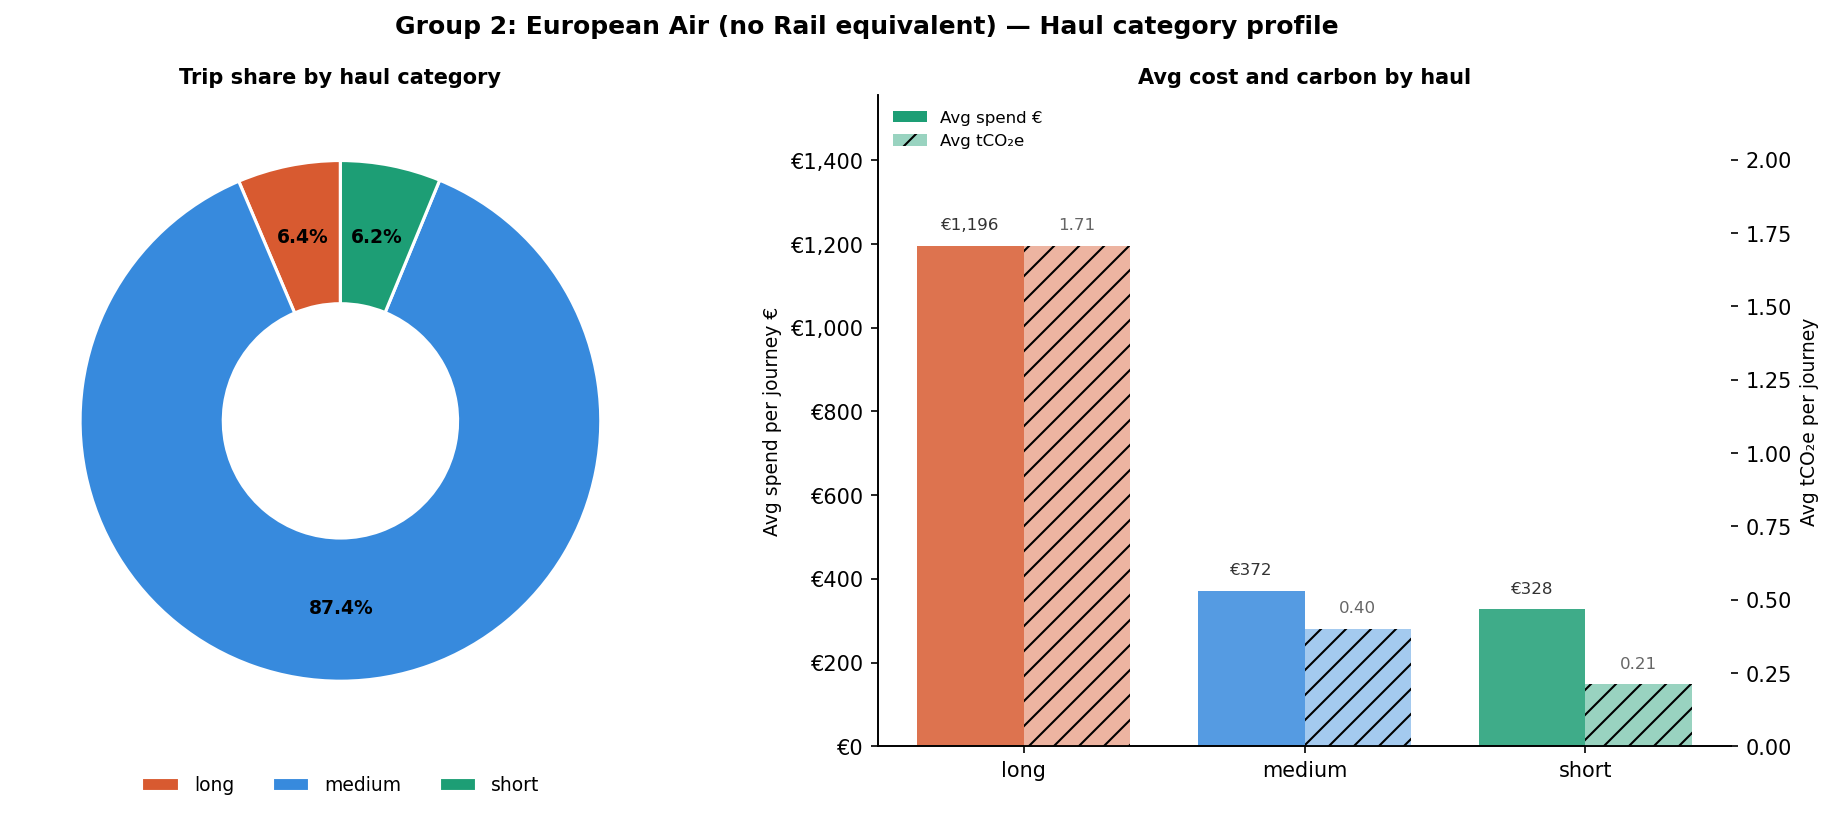

In [49]:
# ── CHART 3.2a: Group 2 — Haul category split (donut + bar) ─────────────────
HAUL_COLORS   = {"short": PALETTE["clean"], "medium": PALETTE["exchange"],
                 "long": PALETTE["cancel"]}
g2_haul_plot  = g2_haul[g2_haul["haul_category"].isin(VALID_HAUL)].copy()
colors_h      = [HAUL_COLORS.get(h, PALETTE["neutral"])
                 for h in g2_haul_plot["haul_category"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Group 2: European Air (no Rail equivalent) — Haul category profile",
             fontsize=12, fontweight="bold")

# ── Donut ─────────────────────────────────────────────────────────────────────
wedges, _, ats = axes[0].pie(
    g2_haul_plot["trips"], labels=None, colors=colors_h,
    autopct="%1.1f%%", pctdistance=0.72, startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 1.5})
for t in ats: t.set_fontsize(9); t.set_fontweight("bold")
axes[0].set_title("Trip share by haul category", fontsize=10, fontweight="bold")
axes[0].legend(g2_haul_plot["haul_category"], loc="lower center",
               bbox_to_anchor=(0.5, -0.10), ncol=3, fontsize=9, frameon=False)

# ── Bar: avg spend (left axis) + avg carbon (right axis) ──────────────────────
x = np.arange(len(g2_haul_plot))
w = 0.38

bars_spend = axes[1].bar(x - w/2, g2_haul_plot["avg_spend"], w,
                          color=colors_h, alpha=0.85)
ax2 = axes[1].twinx()
bars_carbon = ax2.bar(x + w/2, g2_haul_plot["avg_carbon"].fillna(0), w,
                       color=colors_h, alpha=0.45, hatch="//")

axes[1].set_xticks(x)
axes[1].set_xticklabels(g2_haul_plot["haul_category"], fontsize=10)
axes[1].set_ylabel("Avg spend per journey €", fontsize=9)
ax2.set_ylabel("Avg tCO₂e per journey", fontsize=9)
ax2.spines["top"].set_visible(False)
axes[1].set_title("Avg cost and carbon by haul", fontsize=10, fontweight="bold")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))

# ── Set ylims with headroom so labels don't escape ────────────────────────────
axes[1].set_ylim(0, g2_haul_plot["avg_spend"].max() * 1.30)
ax2.set_ylim(0, g2_haul_plot["avg_carbon"].fillna(0).max() * 1.30)

# ── Spend labels above their bars ────────────────────────────────────────────
for i, (_, r) in enumerate(g2_haul_plot.iterrows()):
    axes[1].text(i - w/2, r["avg_spend"] + axes[1].get_ylim()[1] * 0.02,
                 f"€{r['avg_spend']:,.0f}",
                 ha="center", va="bottom", fontsize=8, color="#333333")
# ── Carbon labels above their bars ───────────────────────────────────────────
for i, (_, r) in enumerate(g2_haul_plot.iterrows()):
    if pd.notna(r["avg_carbon"]) and r["avg_carbon"] > 0:
        ax2.text(i + w/2, r["avg_carbon"] + ax2.get_ylim()[1] * 0.02,
                 f"{r['avg_carbon']:.2f}",
                 ha="center", va="bottom", fontsize=8, color="#666666")

# ── Separate legends, no overlap ─────────────────────────────────────────────
from matplotlib.patches import Patch
axes[1].legend(
    [Patch(facecolor=PALETTE["clean"]),
     Patch(facecolor=PALETTE["clean"], alpha=0.45, hatch="//")],
    ["Avg spend €", "Avg tCO₂e"],
    fontsize=8, frameon=False, loc="upper left")

plt.tight_layout()
#plt.savefig("chart_3_2a_g2_haul.png", bbox_inches="tight", dpi=150)
plt.show()

### Chart B — Booking urgency: urgent (≤7d Air) vs plannable (>7d Rail viable)

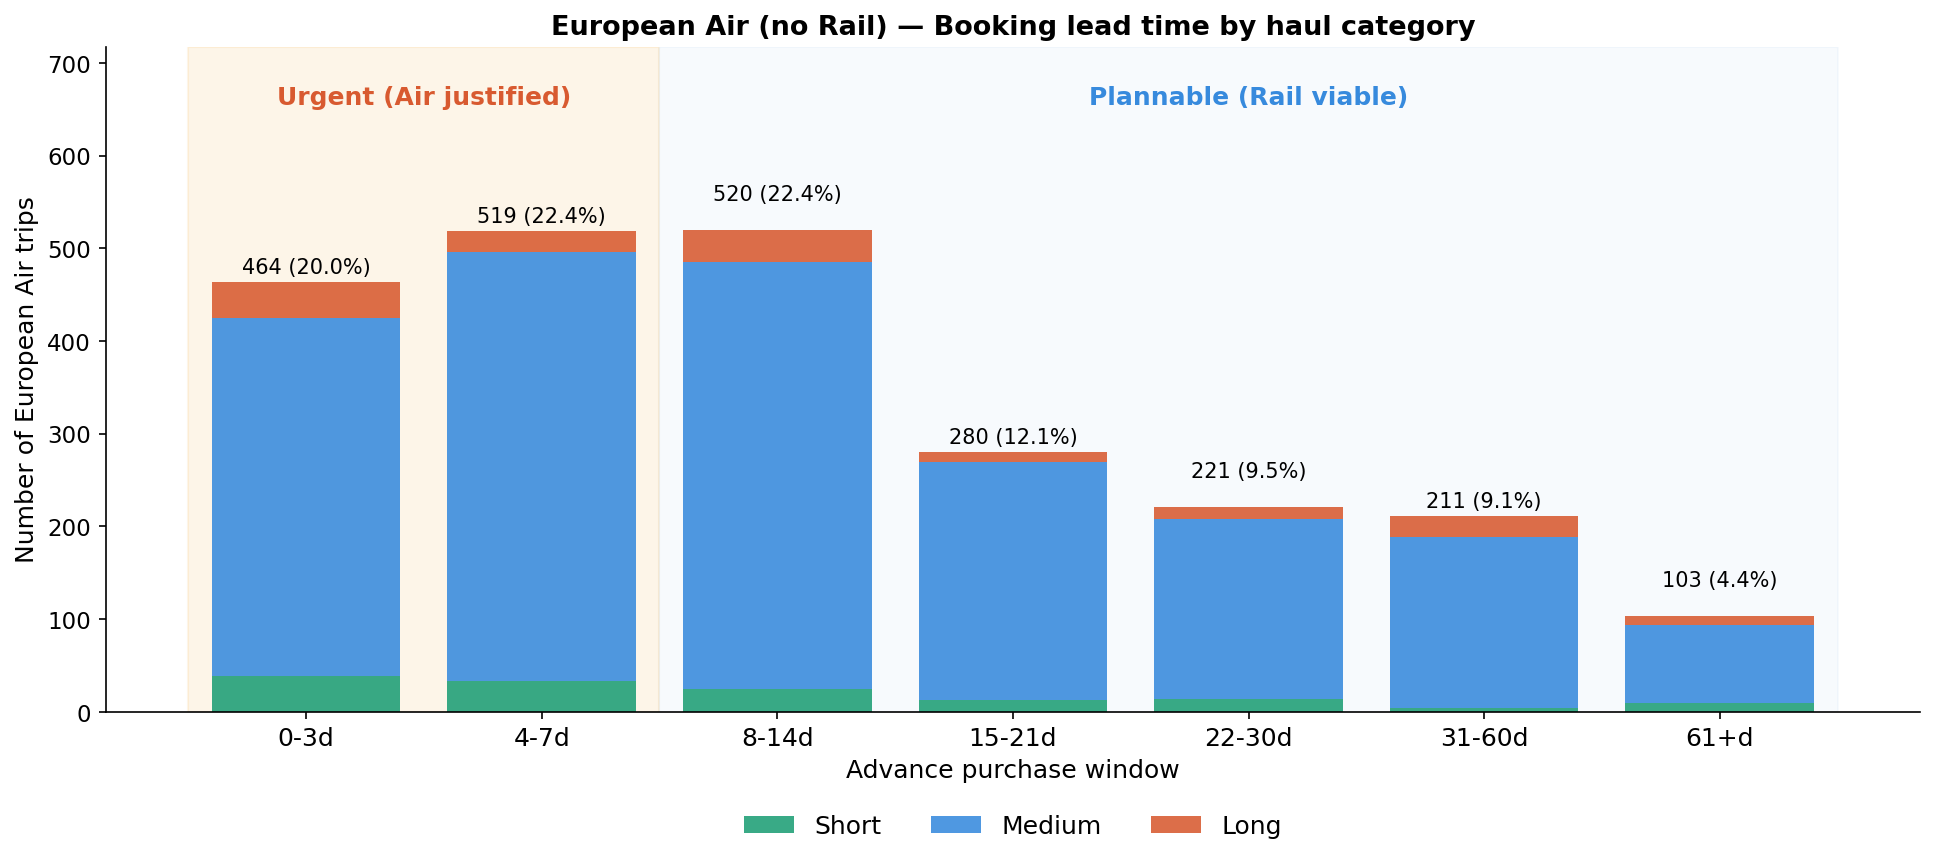

In [50]:
# ── CHART 3.2b: European Air by APD band — stacked by haul category ─────────
# Stack bars: short / medium / long haul within each APD band
# Orange background retained for 0-7d urgent zone

VALID_HAUL  = ["short", "medium", "long"]
HAUL_COLORS = {
    "short" : PALETTE["clean"],
    "medium": PALETTE["exchange"],
    "long"  : PALETTE["cancel"],
}

# Build haul × APD cross-tab
haul_apd = (
    g2_apd[g2_apd["haul_category"].isin(VALID_HAUL)]
    .groupby(["apd_band", "haul_category"], observed=True)["traveler_journey_id"]
    .count()
    .unstack("haul_category")
    .fillna(0)
    .reset_index()
)

# Total per band (for labels)
haul_apd["total"] = haul_apd[VALID_HAUL].sum(axis=1)
haul_apd["pct"]   = haul_apd["total"] / haul_apd["total"].sum() * 100

URGENT_BANDS = ["0-3d", "4-7d"]

fig, ax = plt.subplots(figsize=(13, 6))
x      = np.arange(len(haul_apd))
bottom = np.zeros(len(haul_apd))

for haul in VALID_HAUL:
    if haul in haul_apd.columns:
        vals = haul_apd[haul].values
        ax.bar(x, vals, bottom=bottom,
               color=HAUL_COLORS[haul], alpha=0.88, label=haul.capitalize())
        bottom += vals

# Orange urgent zone background (0-7d = first 2 bands)
ax.set_ylim(0, haul_apd["total"].max() * 1.38)
ax.axvspan(-0.5, 1.5, alpha=0.10, color=PALETTE["highlight"], zorder=0)
ax.axvspan(1.5, len(haul_apd) - 0.5, alpha=0.04, color=PALETTE["exchange"], zorder=0)

# Region labels
label_y = haul_apd["total"].max() * 1.26
ax.text(0.5, label_y, "Urgent (Air justified)",
        ha="center", fontsize=12, color=PALETTE["cancel"], fontweight="bold")
ax.text(4.0, label_y, "Plannable (Rail viable)",
        ha="center", fontsize=12, color=PALETTE["exchange"], fontweight="bold")

# Bar total labels
alt_offsets = [5, 5, 28, 5, 28, 5, 28]
for i, (_, r) in enumerate(haul_apd.iterrows()):
    ax.text(i, r["total"] + alt_offsets[i],
            f"{r['total']:,} ({r['pct']:.1f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(haul_apd["apd_band"].astype(str), fontsize=12)
ax.set_xlabel("Advance purchase window", fontsize=12)
ax.set_ylabel("Number of European Air trips", fontsize=12)
ax.set_title("European Air (no Rail) — Booking lead time by haul category",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=11)

ax.legend(fontsize=12, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
#plt.savefig("chart_3_2b_haul_stacked.png", bbox_inches="tight", dpi=150)
plt.show()


Recommendation R5 — Analysis of Hotel data

In [51]:
##Load dataset

df = pd.read_csv("msf_hotels.csv")
df.head()

,traveler_name,ticket_number,traveler_journey_id,pnr,invoice_number,invoice_date,invoice_year,invoice_month,hotel_amount,hotel_total_room_nights
0,wFN_Q4PFmrix,N42Xl98yFiuP,wFN_Q4PFmrix_N42Xl98yFiuP,706662,N42Xl98yFiuP,2019-12-11,2019,Dec-2019,231.00,3
1,dPgugIyA49S3,T1NwTkBi8yii,dPgugIyA49S3_T1NwTkBi8yii,707022,T1NwTkBi8yii,2019-12-11,2019,Dec-2019,154.00,2
2,8JRj0DEoGBvQ,oRqTSJt4d9-P,8JRj0DEoGBvQ_oRqTSJt4d9-P,706526,oRqTSJt4d9-P,2019-12-18,2019,Dec-2019,2322.00,18
3,y7KChl-1wBIO,cEunaAcIm1cp,y7KChl-1wBIO_cEunaAcIm1cp,NJBBME,cEunaAcIm1cp,2019-12-23,2019,Dec-2019,900.25,13
4,CrvthAFdlL2W,YaBntPICwiVt,CrvthAFdlL2W_YaBntPICwiVt,705680,YaBntPICwiVt,2019-12-11,2019,Dec-2019,154.00,2


In [52]:
## summary of hotel cost
mean_cost = df["hotel_amount"].mean()
median_cost = df["hotel_amount"].median()
std_cost = df["hotel_amount"].std()
min_cost = df["hotel_amount"].min()
max_cost = df["hotel_amount"].max()
records = df["hotel_amount"].count()

print(f"Mean: €{mean_cost:,.2f}")
print(f"Median: €{median_cost:,.2f}")
print(f"Standard deviation: €{std_cost:,.2f}")
print(f"Minimum: €{min_cost:,.2f}")
print(f"Maximum: €{max_cost:,.2f}")
print(f"Records: {records:,}")

Mean: €257.06
Median: €111.15
Standard deviation: €681.30
Minimum: €0.00
Maximum: €22,360.00
Records: 2,786


## Explanation:
Mean hotel cost is €257.06, while the median is €111.15. This shows that most hotel costs are low, but a few expensive bookings increase the average.

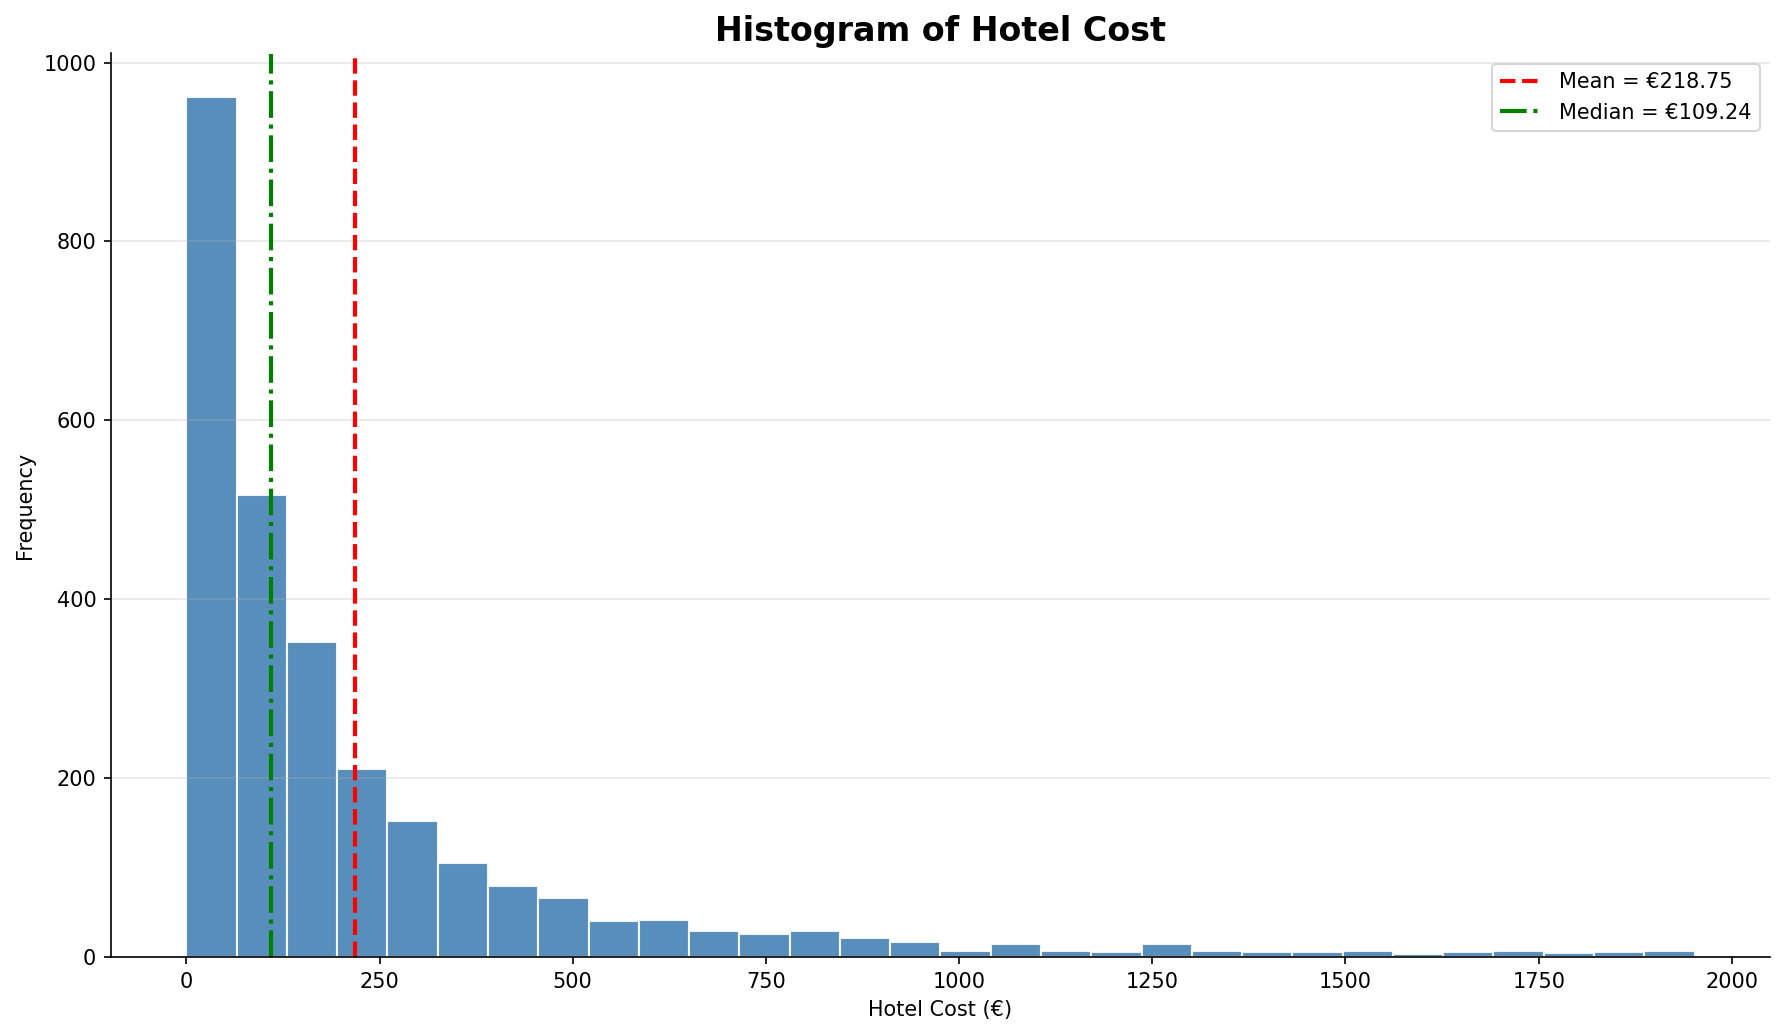

In [53]:
## histogram of hotel cost
p99 = df["hotel_amount"].quantile(0.99)

hotel_filtered = df[
    df["hotel_amount"] <= p99
]

filtered_mean = hotel_filtered["hotel_amount"].mean()
filtered_median = hotel_filtered["hotel_amount"].median()

plt.figure(figsize=(12, 7))

plt.hist(
    hotel_filtered["hotel_amount"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.9
)

plt.axvline(
    filtered_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = €{filtered_mean:,.2f}"
)

plt.axvline(
    filtered_median,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median = €{filtered_median:,.2f}"
)

plt.title(
    "Histogram of Hotel Cost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hotel Cost (€)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

After discussing with the facilitator, the team decided to take away hotel related analysis as there were no relevant recommendations for this. We will include this in our Technical Report Appendix

# Forecasted Savings

This section quantifies the potential financial impact of our recommendations
derived from the MSF travel dataset (71,028 journeys, €40.3M spend, 2019–2026).

**Final recommendations (R1–R4):**
- **R1** — Cap advance bookings at 30 days (Booking Policy)
- **R2** — Default refundable fares for uncertain missions (Fare Management)
- **R3** — Q1 mission planning review (Mission Planning)
- **R4** — Mandate Rail for plannable European routes (Rail Substitution)

**Explored and removed from final recommendations:**
- **R5** — Regional benchmarking (see R5 section below for methodology and rationale for removal)

**Two outputs per recommendation (R1–R4):**
1. Historical saving: what MSF could have saved had the policy been in place 2019–2026
2. Annualised forward estimate: expected saving per year going forward (based on 2024 and 2025)

**Key assumptions (stated once here and referenced throughout):**
- Cancellation cost proxy = average ticket price of cancelled trips (full fare lost)
- Exchange cost proxy = 25% of average ticket price (represents change fee, not full fare;
  traveller still travels so the full fare is not lost — typical airline change fees are
  €50–150 on a €400–900 ticket, placing 25% ≈ €100–225 as a defensible midpoint)
- Blended ≤30d target rate = average cancellation/exchange rate across 0–7d, 8–14d,
  15–30d bands combined (single target applied to all >30d windows)
- R3 scope: post-COVID stable years only (2022–2026 Q1; 2019–2021 excluded)
- R4 Rail fare proxy = average fare from all confirmed intra-European Rail journeys
  in the dataset (no Rail fares available for the corridors in scope directly)


In [54]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "navy"     : "#1B3A5C",
    "teal"     : "#1D7A6E",
    "coral"    : "#C0392B",
    "green"    : "#2E7D32",
    "amber"    : "#F5A623",
    "grey"     : "#888780",
    "light"    : "#F4F6F8",
}
plt.rcParams.update({
    "font.family"       : "sans-serif",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.dpi"        : 150,
})

DATA_PATH = "msf_combined.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
for col in ["total_invoice_amount","advance_purchase_days",
            "carbon_emissions_tco2e","flight_emission_kilometers","rail_kilometers"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["inv_date_parsed"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["invoice_year"]    = df["inv_date_parsed"].dt.year
df["invoice_month"]   = df["inv_date_parsed"].dt.month
df["has_cancellation_flag"] = df["has_cancellation"].astype(str).str.strip() == "True"
df["has_exchange_flag"]     = df["has_exchange"].astype(str).str.strip()     == "True"
fj_all = df[df["transaction_types"].str.contains("Final Journey", na=False)].copy()
fj_pos = fj_all[fj_all["total_invoice_amount"] > 0].copy()

print(f"Dataset loaded: {len(df):,} rows | {df['invoice_year'].min():.0f}–{df['invoice_year'].max():.0f}")
print(f"Final Journey positive-spend rows: {len(fj_pos):,}")


Dataset loaded: 71,036 rows | 2019–2026
Final Journey positive-spend rows: 48,525


---
> ### 🔄 Iteration — Savings charts: 3-bar (historical + 2024 + 2025) → 2-bar (2024 + 2025)
>
> **First version:** Each recommendation's saving chart showed three bars: Historical 2019–2026,
> Annualised 2024, and Annualised 2025.
>
> **Feedback from team:** The historical bar dominated visually and drew focus away from the
> forward-looking annualised figures, which are more directly actionable for MSF's planning.
> The historical bar also mixed pre-COVID years (2019–2021 with different travel volumes) with
> post-COVID years, making it less comparable to the 2024/2025 forward estimates.
>
> **What we changed:** Removed the historical bar from R1–R4 individual saving charts.
> Each chart now shows only the 2024 and 2025 annualised estimates side by side.
> The historical saving is still reported in the summary table for completeness.


In [55]:
# ── FIRST VERSION (REMOVED): 3-bar chart with historical saving ─────────
# Original R1 Chart B included historical 2019-2026 alongside annualised estimates.

# fig, ax = plt.subplots(figsize=(8, 5))
# categories = ['Historical 2019-2026', 'Annualised 2024', 'Annualised 2025']
# values     = [r1_hist, r1_2024, r1_2025]
# colors     = [PALETTE['navy'], PALETTE['teal'], PALETTE['teal']]
# bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
#
# PROBLEM: r1_hist (historical 2019-2026) was typically 5-8x larger than the annualised
# values because it covered 7 years of data. This made the 2024/2025 bars look tiny
# and hard to read even though they are the forward-looking policy estimates.
#
# Team feedback: 'The historical bar makes 2024 and 2025 invisible on the chart.'
#
# Fix: individual R1-R4 charts show 2024 and 2025 only.
# Historical saving retained in the summary table.


---
## R1 — Booking Policy: Cap Advance Bookings at 30 Days

**Method:**
1. Segment all trips by advance purchase days (APD) band
2. Compute the blended cancellation and exchange rate for the ≤30d bands (0–7d, 8–14d, 15–30d combined)
3. For each >30d band (31–60d, 61–90d, 91+d): calculate the excess cancellations and exchanges
   above the ≤30d blended rate
4. Multiply excess events by their cost proxies:
   - Cancelled trips: full average ticket price of cancelled trips in that band
   - Exchanged trips: 25% of average ticket price (change fee proxy)
5. Sum across all >30d bands for the total historical saving
6. For the annualised estimate: apply the same logic to 2024 and 2025 separately

In [56]:
# ── R1: Data preparation ─────────────────────────────────────────────────────
EXCHANGE_COST_SHARE = 0.25   # 25% of avg ticket = change fee proxy

bins   = [0, 7, 14, 30, 60, 90, float("inf")]
labels = ["0–7d", "8–14d", "15–30d", "31–60d", "61–90d", "91+d"]
SAFE_BANDS    = ["0–7d", "8–14d", "15–30d"]
WARNING_BANDS = ["31–60d", "61–90d", "91+d"]

apd = fj_pos[
    fj_pos["advance_purchase_days"].notna() &
    (fj_pos["advance_purchase_days"] >= 0)
].copy()
apd["apd_band"] = pd.cut(apd["advance_purchase_days"],
                          bins=bins, labels=labels, right=True)

r1_tbl = (
    apd.groupby("apd_band", observed=True)
    .agg(
        trips        =("traveler_journey_id", "count"),
        cancellations=("has_cancellation_flag", "sum"),
        exchanges    =("has_exchange_flag",     "sum"),
        avg_cancel_ticket=("total_invoice_amount",
            lambda x: x[apd.loc[x.index, "has_cancellation_flag"]].mean()),
        avg_exch_ticket  =("total_invoice_amount",
            lambda x: x[apd.loc[x.index, "has_exchange_flag"]].mean()),
        avg_ticket   =("total_invoice_amount",   "mean"),
    )
    .reset_index()
)
r1_tbl["cancel_rate"]   = r1_tbl["cancellations"] / r1_tbl["trips"]
r1_tbl["exchange_rate"] = r1_tbl["exchanges"]     / r1_tbl["trips"]

# Blended ≤30d rates (target rates if policy applied)
safe = r1_tbl[r1_tbl["apd_band"].isin(SAFE_BANDS)]
BLENDED_CANCEL_RATE   = safe["cancellations"].sum() / safe["trips"].sum()
BLENDED_EXCHANGE_RATE = safe["exchanges"].sum()     / safe["trips"].sum()

print("=" * 85)
print("R1 — APD BAND BREAKDOWN (full historical dataset)")
print("=" * 85)
print(f"{'Band':<12} {'Trips':>8} {'Cancels':>9} {'Cancel%':>9} "
      f"{'Exchanges':>10} {'Exch%':>8} {'Avg ticket €':>13}")
print("-" * 85)
for _, r in r1_tbl.iterrows():
    marker = " ← target" if str(r["apd_band"]) in SAFE_BANDS else " ← >30d (high risk)"
    print(f"{str(r['apd_band']):<12} {r['trips']:>8,} {r['cancellations']:>9,.0f} "
          f"{r['cancel_rate']:>8.1%} {r['exchanges']:>10,.0f} "
          f"{r['exchange_rate']:>7.1%} {r['avg_ticket']:>13,.2f}{marker}")

print(f"\nBlended ≤30d cancel rate  (target): {BLENDED_CANCEL_RATE:.1%}")
print(f"Blended ≤30d exchange rate (target): {BLENDED_EXCHANGE_RATE:.1%}")


R1 — APD BAND BREAKDOWN (full historical dataset)
Band            Trips   Cancels   Cancel%  Exchanges    Exch%  Avg ticket €
-------------------------------------------------------------------------------------
0–7d           16,217       597     3.7%        300    1.8%        845.61 ← target
8–14d           8,933       295     3.3%        174    1.9%        813.09 ← target
15–30d         10,196       374     3.7%        218    2.1%        801.34 ← target
31–60d          6,044       255     4.2%        155    2.6%        802.49 ← >30d (high risk)
61–90d          1,731        89     5.1%         52    3.0%        792.11 ← >30d (high risk)
91+d            2,513       337    13.4%        225    9.0%        874.32 ← >30d (high risk)

Blended ≤30d cancel rate  (target): 3.6%
Blended ≤30d exchange rate (target): 2.0%


In [57]:
# ── R1: Saving calculation ────────────────────────────────────────────────────
def r1_saving(data, label=""):
    apd_d = data[
        data["advance_purchase_days"].notna() &
        (data["advance_purchase_days"] >= 0)
    ].copy()
    apd_d["apd_band"] = pd.cut(apd_d["advance_purchase_days"],
                                bins=bins, labels=labels, right=True)
    tbl = (
        apd_d.groupby("apd_band", observed=True)
        .agg(
            trips        =("traveler_journey_id", "count"),
            cancellations=("has_cancellation_flag", "sum"),
            exchanges    =("has_exchange_flag",     "sum"),
            avg_cancel_ticket=("total_invoice_amount",
                lambda x: x[apd_d.loc[x.index,"has_cancellation_flag"]].mean()
                          if apd_d.loc[x.index,"has_cancellation_flag"].any() else 0),
            avg_exch_ticket  =("total_invoice_amount",
                lambda x: x[apd_d.loc[x.index,"has_exchange_flag"]].mean()
                          if apd_d.loc[x.index,"has_exchange_flag"].any() else 0),
        )
        .reset_index()
    )
    tbl["cancel_rate"]   = tbl["cancellations"] / tbl["trips"]
    tbl["exchange_rate"] = tbl["exchanges"]     / tbl["trips"]

    warn = tbl[tbl["apd_band"].isin(WARNING_BANDS)].copy()
    warn["target_cancels"]    = warn["trips"] * BLENDED_CANCEL_RATE
    warn["excess_cancels"]    = (warn["cancellations"] - warn["target_cancels"]).clip(lower=0)
    warn["target_exchanges"]  = warn["trips"] * BLENDED_EXCHANGE_RATE
    warn["excess_exchanges"]  = (warn["exchanges"] - warn["target_exchanges"]).clip(lower=0)
    warn["cancel_saving"]     = warn["excess_cancels"]   * warn["avg_cancel_ticket"].fillna(warn["avg_cancel_ticket"].mean())
    warn["exchange_saving"]   = warn["excess_exchanges"] * warn["avg_exch_ticket"].fillna(warn["avg_exch_ticket"].mean()) * EXCHANGE_COST_SHARE

    total_cancel_save   = warn["cancel_saving"].sum()
    total_exchange_save = warn["exchange_saving"].sum()
    total_save          = total_cancel_save + total_exchange_save

    if label:
        print(f"\n  {label}:")
        print(f"    Excess cancellations avoided : {warn['excess_cancels'].sum():.0f}")
        print(f"    Excess exchanges avoided     : {warn['excess_exchanges'].sum():.0f}")
        print(f"    Cancel saving  (full fare)   : €{total_cancel_save:,.0f}")
        print(f"    Exchange saving (25% fare)   : €{total_exchange_save:,.0f}")
        print(f"    TOTAL R1 SAVING              : €{total_save:,.0f}")
    return total_save, warn

print("=" * 65)
print("R1 — FORECASTED SAVING: 30-DAY BOOKING CAP")
print("=" * 65)
r1_hist,  _ = r1_saving(fj_pos,                                    "Historical (2019–2026)")
r1_2024, _  = r1_saving(fj_pos[fj_pos["invoice_year"]==2024],      "Annualised — 2024")
r1_2025, _  = r1_saving(fj_pos[fj_pos["invoice_year"]==2025],      "Annualised — 2025")


R1 — FORECASTED SAVING: 30-DAY BOOKING CAP

  Historical (2019–2026):
    Excess cancellations avoided : 313
    Excess exchanges avoided     : 231
    Cancel saving  (full fare)   : €118,243
    Exchange saving (25% fare)   : €30,387
    TOTAL R1 SAVING              : €148,630

  Annualised — 2024:
    Excess cancellations avoided : 62
    Excess exchanges avoided     : 30
    Cancel saving  (full fare)   : €24,091
    Exchange saving (25% fare)   : €3,977
    TOTAL R1 SAVING              : €28,068

  Annualised — 2025:
    Excess cancellations avoided : 44
    Excess exchanges avoided     : 26
    Cancel saving  (full fare)   : €9,799
    Exchange saving (25% fare)   : €1,832
    TOTAL R1 SAVING              : €11,631


In [58]:
# Chart discarded as the bar for savings from 2019-2026 looked huge and we wanted to retain only 2024 and 2025
# ── R1: Chart B — Forecasted saving (historical + annualised) ───────────────
#fig, ax = plt.subplots(figsize=(8, 5))
#categories = ["Historical 2019-2026", "Annualised 2024", "Annualised 2025"]
#values     = [r1_hist, r1_2024, r1_2025]
#colors     = [PALETTE["navy"], PALETTE["teal"], PALETTE["teal"]]
#bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
#ax.set_ylabel("Forecasted saving", fontsize=12)
#ax.set_title("Forecasted spend saving from 30-day booking cap",
#             fontsize=12, fontweight="bold")
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
#ax.tick_params(axis="x", labelsize=12)
#ax.set_ylim(0, max(values)*1.25)
#for bar, v in zip(bars, values):
#    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.03,
#            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
#plt.tight_layout()
##plt.savefig("r1b_saving.png", bbox_inches="tight", dpi=150)
#plt.show()


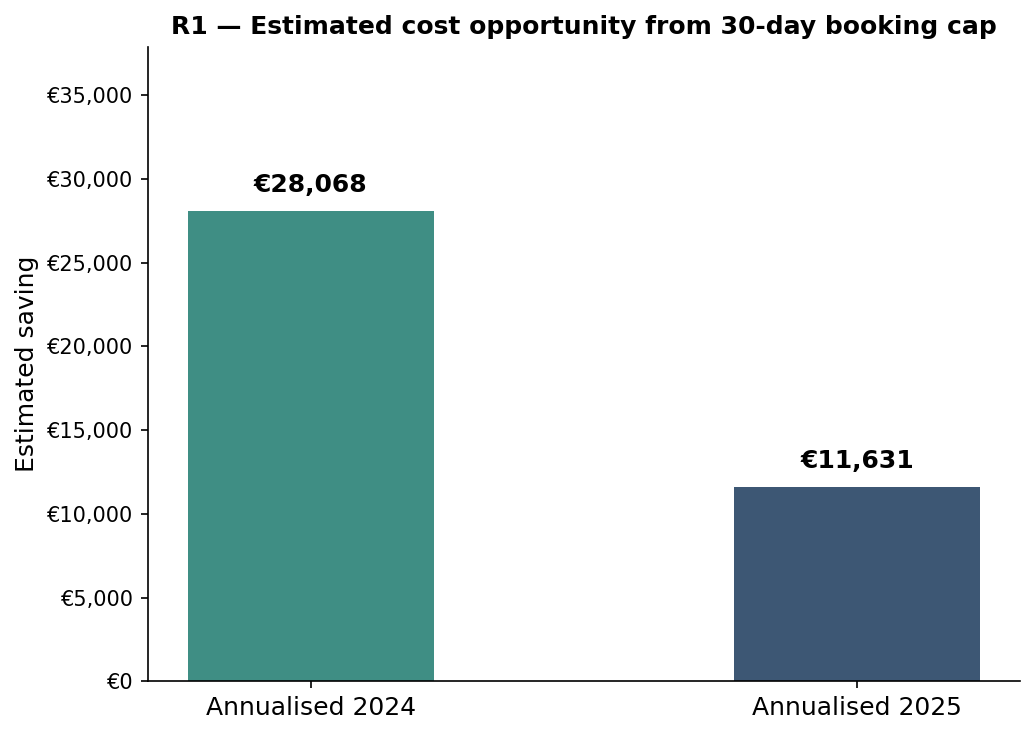

In [59]:
# ── R1: Chart B — Forecasted saving: 2024 and 2025 ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
categories = ["Annualised 2024", "Annualised 2025"]
values     = [r1_2024, r1_2025]
colors     = [PALETTE["teal"], PALETTE["navy"]]
bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.45)
ax.set_ylabel("Estimated saving", fontsize=12)
ax.set_title("R1 — Estimated cost opportunity from 30-day booking cap",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
ax.tick_params(axis="x", labelsize=12)
ax.set_ylim(0, max(values) * 1.35)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.04,
            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("r1b_saving.png", bbox_inches="tight", dpi=150)
plt.show()


---
## R2 — Fare Management: Default Refundable Fares

**Method:**
1. Take the 1,787 non-refundable journeys in the dataset (fj_pos, Final Journey positive-spend)
2. Apply the refundable cancellation rate (4.09%) as the target — down from the non-refundable
   rate (5.88%) — to estimate avoided cancellations
3. Apply the refundable exchange rate (2.23%) as the target — down from (5.93%) — to estimate
   avoided exchanges
4. Multiply avoided cancellations by full average ticket price; avoided exchanges by 25% of
   average ticket price (change fee proxy)
5. Annualised estimate: apply to 2024 and 2025 non-refundable trip volumes separately

In [60]:
# ── R2: Data ──────────────────────────────────────────────────────────────────
ref = fj_pos[
    fj_pos["refundable_indicator"].notna() &
    (~fj_pos["refundable_indicator"].isin(["nan",""]))
].copy()

r2_tbl = (
    ref.groupby("refundable_indicator")
    .agg(
        trips        =("traveler_journey_id", "count"),
        cancellations=("has_cancellation_flag", "sum"),
        exchanges    =("has_exchange_flag",     "sum"),
        avg_ticket   =("total_invoice_amount",  "mean"),
    )
    .reset_index()
)
r2_tbl["cancel_rate"]   = r2_tbl["cancellations"] / r2_tbl["trips"]
r2_tbl["exchange_rate"] = r2_tbl["exchanges"]     / r2_tbl["trips"]

NR = r2_tbl[r2_tbl["refundable_indicator"]=="Non-Refundable"].iloc[0]
RF = r2_tbl[r2_tbl["refundable_indicator"]=="Refundable"].iloc[0]

print("=" * 75)
print("R2 — REFUNDABLE vs NON-REFUNDABLE PROFILE")
print("=" * 75)
print(f"{'Indicator':<20} {'Trips':>8} {'Cancel%':>9} {'Exchange%':>11} {'Avg ticket €':>13}")
print("-" * 65)
for _, r in r2_tbl.iterrows():
    print(f"{r['refundable_indicator']:<20} {r['trips']:>8,} "
          f"{r['cancel_rate']:>8.1%} {r['exchange_rate']:>10.1%} "
          f"{r['avg_ticket']:>13,.2f}")

print(f"\nCancellation rate premium (Non-Ref vs Ref): "
      f"+{NR['cancel_rate']-RF['cancel_rate']:.1%}")
print(f"Exchange rate premium (Non-Ref vs Ref)    : "
      f"+{NR['exchange_rate']-RF['exchange_rate']:.1%}")


R2 — REFUNDABLE vs NON-REFUNDABLE PROFILE
Indicator               Trips   Cancel%   Exchange%  Avg ticket €
-----------------------------------------------------------------
Non-Refundable          1,787     5.9%       5.9%        768.28
Refundable             46,738     4.1%       2.2%        802.04

Cancellation rate premium (Non-Ref vs Ref): +1.8%
Exchange rate premium (Non-Ref vs Ref)    : +3.7%


In [61]:
# ── R2: Saving calculation ────────────────────────────────────────────────────
def r2_saving(nr_trips, nr_avg_ticket, label=""):
    # Avoided cancellations: excess rate above refundable target
    excess_cancel_rate   = NR["cancel_rate"]   - RF["cancel_rate"]
    excess_exchange_rate = NR["exchange_rate"] - RF["exchange_rate"]

    avoided_cancels   = nr_trips * excess_cancel_rate
    avoided_exchanges = nr_trips * excess_exchange_rate

    cancel_save   = avoided_cancels   * nr_avg_ticket
    exchange_save = avoided_exchanges * nr_avg_ticket * EXCHANGE_COST_SHARE
    total_save    = cancel_save + exchange_save

    if label:
        print(f"\n  {label}:")
        print(f"    Non-refundable trips base     : {nr_trips:,.0f}")
        print(f"    Excess cancel rate            : {excess_cancel_rate:.1%}")
        print(f"    Excess exchange rate          : {excess_exchange_rate:.1%}")
        print(f"    Avoided cancellations         : {avoided_cancels:.0f}")
        print(f"    Avoided exchanges             : {avoided_exchanges:.0f}")
        print(f"    Cancel saving (full fare)     : €{cancel_save:,.0f}")
        print(f"    Exchange saving (25% fare)    : €{exchange_save:,.0f}")
        print(f"    TOTAL R2 SAVING               : €{total_save:,.0f}")
    return total_save

print("=" * 65)
print("R2 — FORECASTED SAVING: DEFAULT REFUNDABLE FARES")
print("=" * 65)
r2_hist = r2_saving(NR["trips"], NR["avg_ticket"], "Historical (2019–2026)")

for yr in [2024, 2025]:
    ref_yr = ref[(ref["invoice_year"]==yr) &
                 (ref["refundable_indicator"]=="Non-Refundable")]
    r2_saving(len(ref_yr), ref_yr["total_invoice_amount"].mean(),
              f"Annualised — {yr}")
r2_2024 = r2_saving(len(ref[(ref["invoice_year"]==2024) &
                              (ref["refundable_indicator"]=="Non-Refundable")]),
    ref[(ref["invoice_year"]==2024) & (ref["refundable_indicator"]=="Non-Refundable")]["total_invoice_amount"].mean(), "")
r2_2025 = r2_saving(len(ref[(ref["invoice_year"]==2025) &
                              (ref["refundable_indicator"]=="Non-Refundable")]),
    ref[(ref["invoice_year"]==2025) & (ref["refundable_indicator"]=="Non-Refundable")]["total_invoice_amount"].mean(), "")


R2 — FORECASTED SAVING: DEFAULT REFUNDABLE FARES

  Historical (2019–2026):
    Non-refundable trips base     : 1,787
    Excess cancel rate            : 1.8%
    Excess exchange rate          : 3.7%
    Avoided cancellations         : 32
    Avoided exchanges             : 66
    Cancel saving (full fare)     : €24,564
    Exchange saving (25% fare)    : €12,707
    TOTAL R2 SAVING               : €37,271

  Annualised — 2024:
    Non-refundable trips base     : 61
    Excess cancel rate            : 1.8%
    Excess exchange rate          : 3.7%
    Avoided cancellations         : 1
    Avoided exchanges             : 2
    Cancel saving (full fare)     : €826
    Exchange saving (25% fare)    : €428
    TOTAL R2 SAVING               : €1,254

  Annualised — 2025:
    Non-refundable trips base     : 219
    Excess cancel rate            : 1.8%
    Excess exchange rate          : 3.7%
    Avoided cancellations         : 4
    Avoided exchanges             : 8
    Cancel saving (full fa

In [62]:
# Chart discarded as the bar for savings from 2019-2026 looked huge and we wanted to retain only 2024 and 2025
# ── R2: Chart B — Forecasted saving (historical + annualised) ───────────────
#fig, ax = plt.subplots(figsize=(8, 5))
#categories = ["Historical 2019-2026", "Annualised 2024", "Annualised 2025"]
#values     = [r2_hist, r2_2024, r2_2025]
#colors     = [PALETTE["navy"], PALETTE["teal"], PALETTE["teal"]]
#bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
#ax.set_ylabel("Forecasted saving", fontsize=12)
#ax.set_title("Forecasted spend saving from refundable fare default",
#             fontsize=12, fontweight="bold")
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
#ax.tick_params(axis="x", labelsize=12)
#ax.set_ylim(0, max(values)*1.25)
#for bar, v in zip(bars, values):
#    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.03,
#            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
#plt.tight_layout()
##plt.savefig("r2b_saving.png", bbox_inches="tight", dpi=150)
#plt.show()


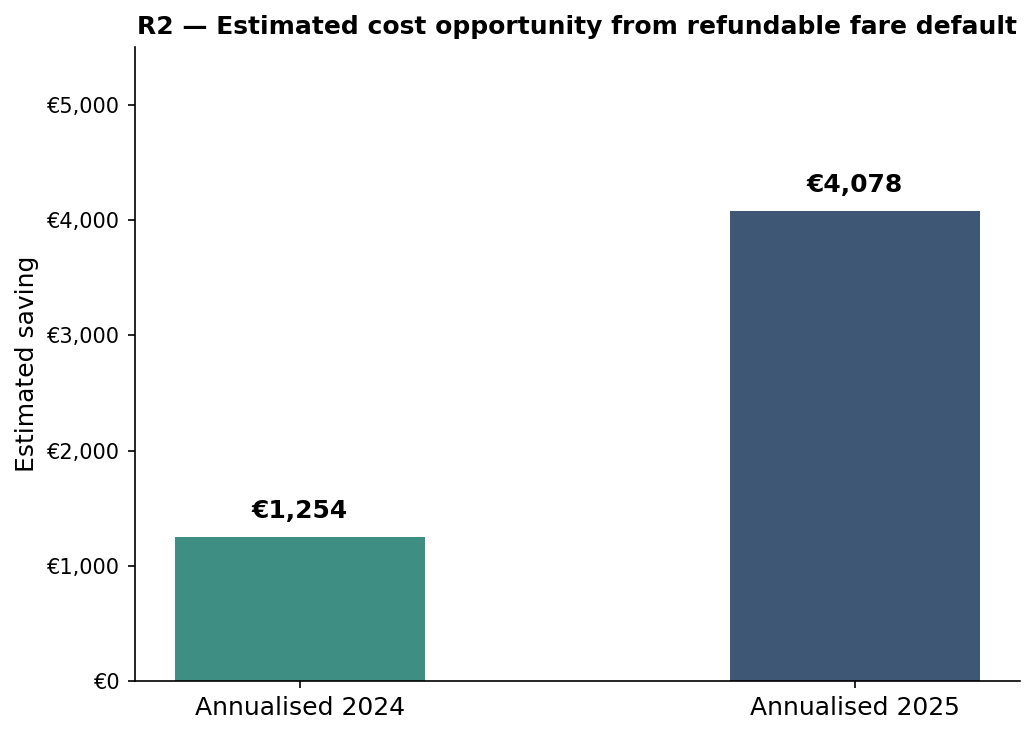

In [63]:
# ── R2: Chart B — Forecasted saving: 2024 and 2025 ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
categories = ["Annualised 2024", "Annualised 2025"]
values     = [r2_2024, r2_2025]
colors     = [PALETTE["teal"], PALETTE["navy"]]
bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.45)
ax.set_ylabel("Estimated saving", fontsize=12)
ax.set_title("R2 — Estimated cost opportunity from refundable fare default",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
ax.tick_params(axis="x", labelsize=12)
ax.set_ylim(0, max(values) * 1.35)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.04,
            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("r2b_saving.png", bbox_inches="tight", dpi=150)
plt.show()


---
## R3 — Mission Planning: Q1 Review

**Method:**
1. Scope: post-COVID stable years only — 2022, 2023, 2024, 2025, and 2026 Q1
   (2019 partial year excluded; 2020 and 2021 excluded due to COVID distortion)
2. Compute actual Q1 (Jan–Mar) cancellation and exchange rates
3. Target: Q2 (Apr–Jun) cancellation and exchange rates from the same years
   — this is the baseline MSF achieves when missions are better confirmed
4. Excess Q1 events above the Q2 baseline = events that a planning review could prevent
5. Multiply by cost proxies (full fare for cancellations, 25% fare for exchanges)

In [64]:
# ── R3: Data ──────────────────────────────────────────────────────────────────
# Post-COVID scope: 2022–2026 (2026 included as Q1 Jan-Mar is a full quarter)
R3_YEARS = [2022, 2023, 2024, 2025, 2026]

q_data = fj_pos[
    fj_pos["invoice_year"].isin(R3_YEARS) &
    fj_pos["invoice_month"].notna()
].copy()

q1 = q_data[q_data["invoice_month"].isin([1,2,3])]
q2 = q_data[q_data["invoice_month"].isin([4,5,6])]

Q1_CANCEL_RATE   = q1["has_cancellation_flag"].mean()
Q1_EXCHANGE_RATE = q1["has_exchange_flag"].mean()
Q2_CANCEL_RATE   = q2["has_cancellation_flag"].mean()   # target
Q2_EXCHANGE_RATE = q2["has_exchange_flag"].mean()       # target

Q1_AVG_CANCEL_TICKET = q1[q1["has_cancellation_flag"]]["total_invoice_amount"].mean()
Q1_AVG_EXCH_TICKET   = q1[q1["has_exchange_flag"]]["total_invoice_amount"].mean()

print("=" * 70)
print("R3 — Q1 vs Q2 DISRUPTION RATES (2022–2026, post-COVID)")
print("=" * 70)
print(f"{'Quarter':<10} {'Trips':>8} {'Cancel%':>10} {'Exchange%':>12}")
print("-" * 45)
print(f"{'Q1':<10} {len(q1):>8,} {Q1_CANCEL_RATE:>9.1%} {Q1_EXCHANGE_RATE:>11.1%}")
print(f"{'Q2 (target)':<10} {len(q2):>8,} {Q2_CANCEL_RATE:>9.1%} {Q2_EXCHANGE_RATE:>11.1%}")
print(f"{'Excess':<10} {'':>8} {Q1_CANCEL_RATE-Q2_CANCEL_RATE:>+9.1%} "
      f"{Q1_EXCHANGE_RATE-Q2_EXCHANGE_RATE:>+11.1%}")

print(f"\nQ1 avg cancelled ticket : €{Q1_AVG_CANCEL_TICKET:.2f}")
print(f"Q1 avg exchanged ticket : €{Q1_AVG_EXCH_TICKET:.2f}")

# By year breakdown
print(f"\n{'Year':<8} {'Q1 trips':>10} {'Q1 cancel%':>12} {'Q1 exch%':>10}")
print("-" * 45)
for yr in R3_YEARS:
    q1_yr = q1[q1["invoice_year"]==yr]
    if len(q1_yr) > 0:
        print(f"{yr:<8} {len(q1_yr):>10,} "
              f"{q1_yr['has_cancellation_flag'].mean():>11.1%} "
              f"{q1_yr['has_exchange_flag'].mean():>9.1%}")


R3 — Q1 vs Q2 DISRUPTION RATES (2022–2026, post-COVID)
Quarter       Trips    Cancel%    Exchange%
---------------------------------------------
Q1            9,103      4.0%        2.1%
Q2 (target)    8,470      3.6%        1.8%
Excess                  +0.4%       +0.3%

Q1 avg cancelled ticket : €480.63
Q1 avg exchanged ticket : €582.75

Year       Q1 trips   Q1 cancel%   Q1 exch%
---------------------------------------------
2022          1,529        3.7%      1.8%
2023          1,988        4.6%      2.5%
2024          1,812        4.4%      2.3%
2025          2,017        3.8%      2.1%
2026          1,757        3.4%      1.7%


In [65]:
# ── R3: Saving calculation ────────────────────────────────────────────────────
def r3_saving(q1_data, label=""):
    trips    = len(q1_data)
    actual_c = q1_data["has_cancellation_flag"].sum()
    actual_e = q1_data["has_exchange_flag"].sum()
    target_c = trips * Q2_CANCEL_RATE
    target_e = trips * Q2_EXCHANGE_RATE
    excess_c = max(actual_c - target_c, 0)
    excess_e = max(actual_e - target_e, 0)

    avg_ct = q1_data[q1_data["has_cancellation_flag"]]["total_invoice_amount"].mean()
    avg_et = q1_data[q1_data["has_exchange_flag"]]["total_invoice_amount"].mean()
    if pd.isna(avg_ct): avg_ct = Q1_AVG_CANCEL_TICKET
    if pd.isna(avg_et): avg_et = Q1_AVG_EXCH_TICKET

    cancel_save   = excess_c * avg_ct
    exchange_save = excess_e * avg_et * EXCHANGE_COST_SHARE
    total_save    = cancel_save + exchange_save

    if label:
        print(f"\n  {label}:")
        print(f"    Q1 trips                      : {trips:,}")
        print(f"    Actual cancellations          : {actual_c:.0f}  ({actual_c/trips:.1%})")
        print(f"    Target cancellations (Q2 rate): {target_c:.0f}  ({Q2_CANCEL_RATE:.1%})")
        print(f"    Excess cancellations          : {excess_c:.0f}")
        print(f"    Actual exchanges              : {actual_e:.0f}  ({actual_e/trips:.1%})")
        print(f"    Target exchanges   (Q2 rate)  : {target_e:.0f}  ({Q2_EXCHANGE_RATE:.1%})")
        print(f"    Excess exchanges              : {excess_e:.0f}")
        print(f"    Cancel saving (full fare)     : €{cancel_save:,.0f}")
        print(f"    Exchange saving (25% fare)    : €{exchange_save:,.0f}")
        print(f"    TOTAL R3 SAVING               : €{total_save:,.0f}")
    return total_save

print("=" * 65)
print("R3 — FORECASTED SAVING: Q1 MISSION PLANNING REVIEW")
print("Note: scope = 2022–2026 Q1 only (post-COVID stable years)")
print("=" * 65)
r3_hist = r3_saving(q1, "Historical Q1 2022–2026")
r3_2024 = r3_saving(q1[q1["invoice_year"]==2024], "Annualised — 2024 Q1")
r3_2025 = r3_saving(q1[q1["invoice_year"]==2025], "Annualised — 2025 Q1")


R3 — FORECASTED SAVING: Q1 MISSION PLANNING REVIEW
Note: scope = 2022–2026 Q1 only (post-COVID stable years)

  Historical Q1 2022–2026:
    Q1 trips                      : 9,103
    Actual cancellations          : 364  (4.0%)
    Target cancellations (Q2 rate): 329  (3.6%)
    Excess cancellations          : 35
    Actual exchanges              : 190  (2.1%)
    Target exchanges   (Q2 rate)  : 167  (1.8%)
    Excess exchanges              : 23
    Cancel saving (full fare)     : €16,885
    Exchange saving (25% fare)    : €3,411
    TOTAL R3 SAVING               : €20,297

  Annualised — 2024 Q1:
    Q1 trips                      : 1,812
    Actual cancellations          : 80  (4.4%)
    Target cancellations (Q2 rate): 65  (3.6%)
    Excess cancellations          : 15
    Actual exchanges              : 42  (2.3%)
    Target exchanges   (Q2 rate)  : 33  (1.8%)
    Excess exchanges              : 9
    Cancel saving (full fare)     : €6,067
    Exchange saving (25% fare)    : €1,158
  

In [66]:
# Chart discarded as the bar for savings from 2019-2026 looked huge and we wanted to retain only 2024 and 2025
# ── R3: Chart B — Forecasted saving (historical + annualised) ───────────────
#fig, ax = plt.subplots(figsize=(8, 5))
#categories = ["Historical Q1 2022-2026", "Annualised 2024 Q1", "Annualised 2025 Q1"]
#values     = [r3_hist, r3_2024, r3_2025]
#colors     = [PALETTE["navy"], PALETTE["teal"], PALETTE["teal"]]
#bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
#ax.set_ylabel("Forecasted saving", fontsize=12)
#ax.set_title("Forecasted spend saving from Q1 mission planning review",
#             fontsize=12, fontweight="bold")
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
#ax.tick_params(axis="x", labelsize=12)
#ax.set_ylim(0, max(values)*1.25)
#for bar, v in zip(bars, values):
#    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.03,
#            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
#plt.tight_layout()
##plt.savefig("r3b_saving.png", bbox_inches="tight", dpi=150)
#plt.show()

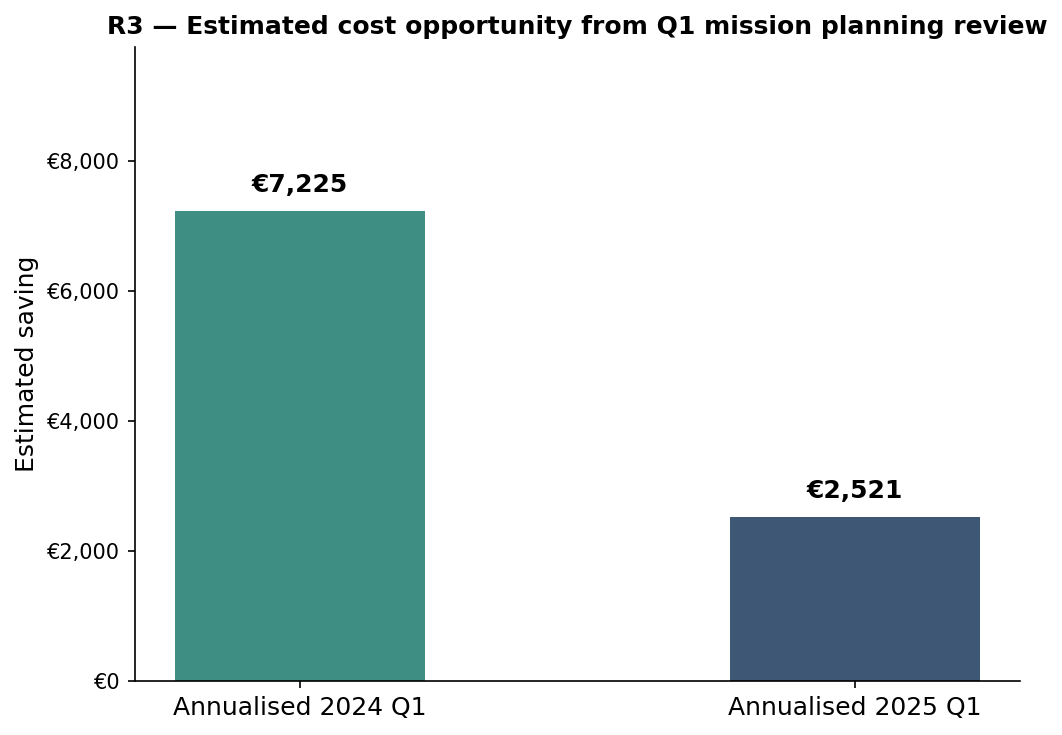

In [67]:
# ── R3: Chart B — Forecasted saving: 2024 and 2025 ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
categories = ["Annualised 2024 Q1", "Annualised 2025 Q1"]
values     = [r3_2024, r3_2025]
colors     = [PALETTE["teal"], PALETTE["navy"]]
bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.45)
ax.set_ylabel("Estimated saving", fontsize=12)
ax.set_title("R3 — Estimated cost opportunity from Q1 mission planning review",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
ax.tick_params(axis="x", labelsize=12)
ax.set_ylim(0, max(values) * 1.35)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.04,
            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("r3b_saving.png", bbox_inches="tight", dpi=150)
plt.show()


---
## R4 — Rail Substitution: Mandate Rail for Plannable European Routes

**Method:**
1. Identify Group 2 trips: confirmed intra-European Air journeys (all IATA stops verified
   as European using majority-region lookup) on point-to-point corridors with no Rail
   equivalent in MSF data
2. Filter to plannable trips: advance purchase days > 7 (booked with enough lead time for Rail)
3. Cost saving per trip = avg Air fare (Group 2 plannable) minus avg Rail fare
   (all confirmed intra-European Rail journeys — used as proxy since no Rail fares
   exist for Group 2 corridors directly)
4. Carbon saving: cited from Ale's Power BI analysis (2,137 tCO₂e forecasted total saving
   from rail adoption in Europe) — not recomputed here to avoid inconsistency
5. Annualised: 2024 and 2025 plannable Group 2 trips separately

In [68]:
# ── R4: Build confirmed-European filter ──────────────────────────────────────
_euro_n = {}; _non_n = {}
for _, row in df[["corrected_origin","origin_region"]].dropna().iterrows():
    c = str(row["corrected_origin"]).strip(); r = str(row["origin_region"]).strip()
    if len(c)==3 and r not in ["nan","DEFAULT",""]:
        if r=="EUROPE": _euro_n[c] = _euro_n.get(c,0)+1
        else:            _non_n[c]  = _non_n.get(c,0)+1
for _, row in df[["corrected_destination","destination_region"]].dropna().iterrows():
    c = str(row["corrected_destination"]).strip(); r = str(row["destination_region"]).strip()
    if len(c)==3 and r not in ["nan","DEFAULT",""]:
        if r=="EUROPE": _euro_n[c] = _euro_n.get(c,0)+1
        else:            _non_n[c]  = _non_n.get(c,0)+1
NON_EURO = {c for c in set(list(_euro_n)+list(_non_n))
            if _non_n.get(c,0) > _euro_n.get(c,0)}
NON_EURO |= {c for c in _non_n if c not in _euro_n}

def is_fully_european(itin):
    if pd.isna(itin) or str(itin).strip() in ["nan",""]: return False
    tokens = re.split(r"[-/\*]", str(itin).strip())
    codes  = [t.strip() for t in tokens if len(t.strip())==3]
    return bool(codes) and not any(c in NON_EURO for c in codes)

air  = fj_pos[fj_pos["record_types"]=="Air"].copy()
rail = fj_pos[fj_pos["record_types"]=="Rail"].copy()
air["is_euro"]  = air["itinerary"].apply(is_fully_european)
rail["is_euro"] = rail["itinerary"].apply(is_fully_european)
air_euro  = air[air["is_euro"]].copy()
rail_euro = rail[rail["is_euro"]].copy()

for f in [air_euro, rail_euro]:
    f["route_key"] = f["corrected_origin"].fillna("")+"/"+f["corrected_destination"].fillna("")

air_p2p  = air_euro[air_euro["corrected_origin"]!=air_euro["corrected_destination"]].copy()
rail_p2p = rail_euro[rail_euro["corrected_origin"]!=rail_euro["corrected_destination"]].copy()
shared   = set(air_p2p["route_key"]) & set(rail_p2p["route_key"])
air_g2   = air_p2p[~air_p2p["route_key"].isin(shared)].copy()

# Plannable = booked > 7 days ahead
air_g2_plan = air_g2[
    air_g2["advance_purchase_days"].notna() &
    (air_g2["advance_purchase_days"] > 7)
].copy()

AVG_AIR_FARE  = air_g2_plan["total_invoice_amount"].mean()
AVG_RAIL_FARE = rail_euro["total_invoice_amount"].mean()
SAVING_PER_TRIP = AVG_AIR_FARE - AVG_RAIL_FARE

print("=" * 75)
print("R4 — GROUP 2 PLANNABLE AIR TRIPS PROFILE")
print("Plannable = booked >7 days ahead, all confirmed intra-European itineraries")
print("=" * 75)
print(f"Total confirmed intra-European Air trips      : {len(air_euro):,}")
print(f"Group 2 (no Rail corridor in MSF data)        : {len(air_g2):,}")
print(f"  of which plannable (>7d APD)                : {len(air_g2_plan):,} "
      f"({len(air_g2_plan)/len(air_g2)*100:.1f}%)")
print(f"  of which urgent (≤7d APD)                   : {len(air_g2)-len(air_g2_plan):,}")
print(f"\nAvg Air fare (Group 2 plannable)             : €{AVG_AIR_FARE:.2f}")
print(f"Avg Rail fare (proxy — all Euro Rail journeys): €{AVG_RAIL_FARE:.2f}")
print(f"Saving per trip if switched to Rail           : €{SAVING_PER_TRIP:.2f}")
print(f"\nNote: Rail fare proxy uses the average fare from {len(rail_euro):,} confirmed")
print(f"intra-European Rail journeys. No Rail fares available for Group 2 corridors directly.")


R4 — GROUP 2 PLANNABLE AIR TRIPS PROFILE
Plannable = booked >7 days ahead, all confirmed intra-European itineraries
Total confirmed intra-European Air trips      : 5,699
Group 2 (no Rail corridor in MSF data)        : 3,262
  of which plannable (>7d APD)                : 1,646 (50.5%)
  of which urgent (≤7d APD)                   : 1,616

Avg Air fare (Group 2 plannable)             : €381.27
Avg Rail fare (proxy — all Euro Rail journeys): €101.20
Saving per trip if switched to Rail           : €280.07

Note: Rail fare proxy uses the average fare from 3 confirmed
intra-European Rail journeys. No Rail fares available for Group 2 corridors directly.


In [69]:
# ── R4: Saving calculation ────────────────────────────────────────────────────
def r4_saving(data, label=""):
    n = len(data)
    air_spend  = data["total_invoice_amount"].sum()
    rail_equiv = n * AVG_RAIL_FARE
    saving     = air_spend - rail_equiv

    if label:
        print(f"\n  {label}:")
        print(f"    Plannable Group 2 Air trips   : {n:,}")
        print(f"    Total Air spend               : €{air_spend:,.0f}")
        print(f"    Equivalent Rail spend (proxy) : €{rail_equiv:,.0f}")
        print(f"    TOTAL R4 COST SAVING          : €{saving:,.0f}")
        print(f"    Carbon saving (from Ale's analysis): cited 2,137 tCO₂e total")
    return saving

print("=" * 65)
print("R4 — FORECASTED SAVING: RAIL SUBSTITUTION")
print("=" * 65)
r4_hist = r4_saving(air_g2_plan, "Historical (2019–2026, all plannable)")
r4_2024 = r4_saving(air_g2_plan[air_g2_plan["invoice_year"]==2024],
                     "Annualised — 2024")
r4_2025 = r4_saving(air_g2_plan[air_g2_plan["invoice_year"]==2025],
                     "Annualised — 2025")

print(f"\nCarbon saving (cited from Ale's Power BI analysis): 2,137 tCO₂e")
print(f"This represents the total forecasted saving if MSF adopted Rail")
print(f"across all eligible European intra-European Air routes.")


R4 — FORECASTED SAVING: RAIL SUBSTITUTION

  Historical (2019–2026, all plannable):
    Plannable Group 2 Air trips   : 1,646
    Total Air spend               : €627,577
    Equivalent Rail spend (proxy) : €166,575
    TOTAL R4 COST SAVING          : €461,002
    Carbon saving (from Ale's analysis): cited 2,137 tCO₂e total

  Annualised — 2024:
    Plannable Group 2 Air trips   : 253
    Total Air spend               : €114,442
    Equivalent Rail spend (proxy) : €25,604
    TOTAL R4 COST SAVING          : €88,839
    Carbon saving (from Ale's analysis): cited 2,137 tCO₂e total

  Annualised — 2025:
    Plannable Group 2 Air trips   : 193
    Total Air spend               : €86,035
    Equivalent Rail spend (proxy) : €19,532
    TOTAL R4 COST SAVING          : €66,503
    Carbon saving (from Ale's analysis): cited 2,137 tCO₂e total

Carbon saving (cited from Ale's Power BI analysis): 2,137 tCO₂e
This represents the total forecasted saving if MSF adopted Rail
across all eligible Europe

In [70]:
# Chart discarded as the bar for savings from 2019-2026 looked huge and we wanted to retain only 2024 and 2025
# ── R4: Chart B — Forecasted cost saving (historical + annualised) ──────────
#fig, ax = plt.subplots(figsize=(8, 5.5))
#categories = ["Historical 2019-2026", "Annualised 2024", "Annualised 2025"]
#values     = [r4_hist, r4_2024, r4_2025]
#colors     = [PALETTE["navy"], PALETTE["teal"], PALETTE["teal"]]
#bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
#ax.set_ylabel("Forecasted cost saving", fontsize=12)
#ax.set_title(f"Forecasted cost saving from Rail Adoption (avg €{SAVING_PER_TRIP:.0f}/trip)",
#             fontsize=12, fontweight="bold")
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
#ax.tick_params(axis="x", labelsize=12)
#ax.set_ylim(0, max(values)*1.30)
#for bar, v in zip(bars, values):
#    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.03,
#            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
#ax.text(0.5, -0.10, "Carbon saving: 2,137 tCO2e",
#        ha="center", transform=ax.transAxes,
#        fontsize=10, color=PALETTE["teal"], style="italic")
#plt.tight_layout()
#plt.subplots_adjust(bottom=0.14)
##plt.savefig("r4b_saving.png", bbox_inches="tight", dpi=150)
#plt.show()


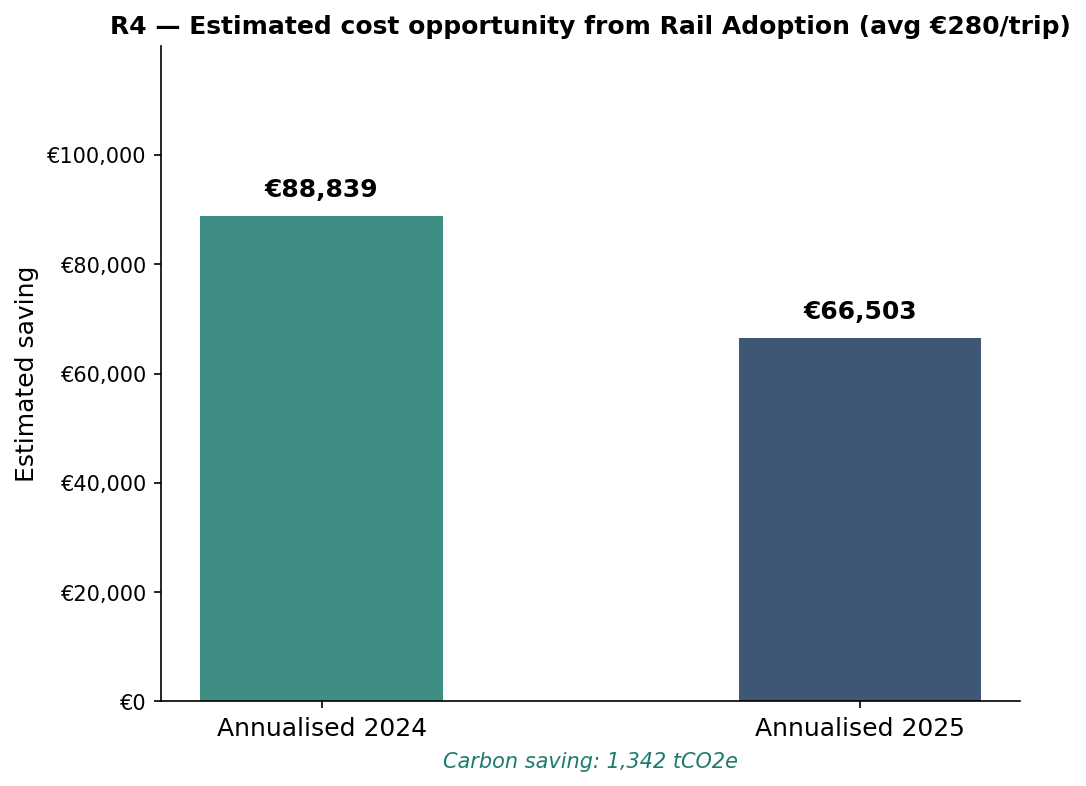

In [71]:
# ── R4: Chart B — Forecasted saving: 2024 and 2025 ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))
categories = ["Annualised 2024", "Annualised 2025"]
values     = [r4_2024, r4_2025]
colors     = [PALETTE["teal"], PALETTE["navy"]]
bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.45)
ax.set_ylabel("Estimated saving", fontsize=12)
ax.set_title(f"R4 — Estimated cost opportunity from Rail Adoption (avg €{SAVING_PER_TRIP:.0f}/trip)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
ax.tick_params(axis="x", labelsize=12)
ax.set_ylim(0, max(values) * 1.35)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v + max(values)*0.04,
            f"€{v:,.0f}", ha="center", fontsize=12, fontweight="bold")
ax.text(0.5, -0.10, "Carbon saving: 1,342 tCO2e",
        ha="center", transform=ax.transAxes,
        fontsize=10, color=PALETTE["teal"], style="italic")
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.savefig("r4b_saving.png", bbox_inches="tight", dpi=150)
plt.show()


---
> ### 🔄 Iteration — R5 Regional Benchmarking: explored and removed from final recommendations
>
> **What we explored:** Whether regional cost benchmarking could be formulated as a recommendation
> with a quantifiable saving comparable to R1–R4.
>
> **Why it was removed:** The metric we could compute was not a cash saving — it was a budget
> planning accuracy metric. The analysis identified trips that fell outside the global benchmark
> but within the regional benchmark, representing spend that would have been correctly anticipated
> under a regional approach. But this is spend MSF was always going to incur — it could not be
> avoided by changing booking behaviour. R1–R4 all reduce actual spend; R5 reduces budget
> variance without reducing spend. These are different problems requiring different interventions.
>
> MSF confirmed their primary interest was in reducing cost. R5 was removed from final
> recommendations but the code is retained here to satisfy LSE's requirement to document
> iterations that were explored and set aside.


In [72]:
# ── R5 KEY DISTINCTION (retained for LSE documentation) ────────────────────
# The distinction that led to R5 being removed from final recommendations:

# R1-R4 savings: MSF would NOT have spent this money under the new policy
#   e.g. R1: 337 excess cancellations × avg ticket price = £X not spent on wasted tickets

# R5 'saving': MSF WOULD have spent this money regardless
#   The 'unbudgeted risk' figure shows spend that would have been correctly budgeted for
#   under a regional benchmark vs treated as unexpected overspend under a global benchmark.
#   The underlying trips still happen — only the budget expectation changes.

# This distinction means R5 cannot be added to the R1-R4 total as a comparable saving.
# Including it would overstate total financial benefit by combining apples and oranges.

# Additional issue: the global median benchmark is sensitive to year-on-year travel mix
# changes (COVID recovery years shifted which routes were flown significantly), making
# it fragile as a stable planning reference without further refinement.

# Decision: remove from final 4 recommendations, retain methodology for LSE submission.


---
## R5 — Regional Benchmarking: Explored and Removed from Final Recommendations

> **⚠️ Iteration note:** R5 was developed, tested, and subsequently **removed** from our final
> four recommendations presented to MSF. The methodology and code are retained here in full to
> document our analytical process and demonstrate the decision-making involved.

### Why R5 was removed

During development, we identified a fundamental framing issue: regional benchmarking does not
produce a **recoverable cash saving** — it produces a **budget planning accuracy metric**.
The analysis shows how much spend would have been correctly anticipated under a regional benchmark
versus a global one, but does not identify spend that MSF could have avoided.

Our four final recommendations (R1–R4) all produce directly quantifiable cost savings from
avoided cancellations, exchanges, or modal substitution. R5 addresses a different problem —
budget variance rather than spend optimisation — and would require a separate policy intervention
(updating the annual travel budget model) rather than a change to booking behaviour.

We retained R5 in the notebook because:
1. The methodology is sound for budget planning purposes and MSF may find it useful independently
2. LSE requires documentation of iterations, including explorations that were refined or set aside
3. The Africa/Europe deviation analysis (replicating Evie's Power BI findings) validates that
   regional cost variation is real and persistent (+26–53% for Africa, −33–47% for Europe)

**Framing:** This is a budget planning accuracy metric, not a cash saving.
Regional benchmarking does not reduce spend; it ensures the travel budget correctly
anticipates regional cost variation rather than treating overspend as unexpected.

**Method:**
1. Focus on medium-haul journeys (the haul type with highest regional cost variability)
2. For each year (2022–2025), compute the global median and each destination region's median
3. For each journey: check whether it fell outside the global benchmark (cost exceeded global
   median) but within the regional benchmark (cost was within the regional median)
4. The sum of these trips' costs = the "unbudgeted risk" that regional benchmarking would have
   correctly anticipated rather than flagged as overspend
5. Show Africa and Europe deviation from global benchmark (replicates Evie's analysis)


In [73]:
# ── R5: Data ──────────────────────────────────────────────────────────────────
R5_YEARS = [2022, 2023, 2024, 2025]

mh = fj_pos[
    (fj_pos["haul_category"] == "medium") &
    fj_pos["destination_region"].notna() &
    (~fj_pos["destination_region"].isin(["nan","DEFAULT",""])) &
    fj_pos["invoice_year"].isin(R5_YEARS)
].copy()

# Global and regional medians by year
global_med_yr = mh.groupby("invoice_year")["total_invoice_amount"].median().to_dict()
reg_med_yr    = (mh.groupby(["invoice_year","destination_region"])
                   ["total_invoice_amount"].median()
                   .reset_index()
                   .rename(columns={"total_invoice_amount":"reg_median"}))
mh = mh.merge(reg_med_yr, on=["invoice_year","destination_region"], how="left")
mh["global_median"] = mh["invoice_year"].map(global_med_yr)

# Deviation from global median per region per year
dev_tbl = (
    mh.groupby(["invoice_year","destination_region"])
    .apply(lambda g: pd.Series({
        "trips"         : len(g),
        "total_spend"   : g["total_invoice_amount"].sum(),
        "median_actual" : g["total_invoice_amount"].median(),
        "global_median" : g["global_median"].iloc[0],
    }))
    .reset_index()
)
dev_tbl["pct_vs_global"] = (
    (dev_tbl["median_actual"] - dev_tbl["global_median"])
    / dev_tbl["global_median"] * 100
)

print("=" * 85)
print("R5 — MEDIUM-HAUL REGIONAL COST vs GLOBAL MEDIAN BENCHMARK (2022–2025)")
print("Positive = region costs MORE than global median (risk of under-budgeting)")
print("Negative = region costs LESS than global median (safe to budget lower)")
print("=" * 85)
print(f"{'Year':>6} {'Region':<22} {'Trips':>7} {'Actual median €':>16} "
      f"{'Global median €':>16} {'% vs global':>12}")
print("-" * 85)
for _, r in dev_tbl.sort_values(["invoice_year","pct_vs_global"], ascending=[True,False]).iterrows():
    flag = " ◄ over-budget risk" if r["pct_vs_global"] > 10 else ""
    print(f"{int(r['invoice_year']):>6} {r['destination_region']:<22} "
          f"{r['trips']:>7,} {r['median_actual']:>16,.2f} "
          f"{r['global_median']:>16,.2f} {r['pct_vs_global']:>+11.1f}%{flag}")


R5 — MEDIUM-HAUL REGIONAL COST vs GLOBAL MEDIAN BENCHMARK (2022–2025)
Positive = region costs MORE than global median (risk of under-budgeting)
Negative = region costs LESS than global median (safe to budget lower)
  Year Region                   Trips  Actual median €  Global median €  % vs global
-------------------------------------------------------------------------------------
  2022 LATIN AMERICA            108.0         1,098.82           617.93       +77.8% ◄ over-budget risk
  2022 NORTH AMERICA             25.0         1,010.26           617.93       +63.5% ◄ over-budget risk
  2022 ASIA/PACIFIC             178.0           933.00           617.93       +51.0% ◄ over-budget risk
  2022 AFRICA                 1,012.0           835.64           617.93       +35.2% ◄ over-budget risk
  2022 MIDEAST                  302.0           557.01           617.93        -9.9%
  2022 EUROPE                 1,007.0           439.75           617.93       -28.8%
  2023 NORTH AMERICA        

In [74]:
# ── R5: Budget risk metric ────────────────────────────────────────────────────
# Unbudgeted risk = trips where actual cost > global median but ≤ regional median
# These are trips that a global benchmark would flag as overspend but a regional
# benchmark would have correctly anticipated

mh["above_global"] = mh["total_invoice_amount"] > mh["global_median"]
mh["within_regional"] = mh["total_invoice_amount"] <= mh["reg_median"]
mh["is_anticipated_by_regional"] = mh["above_global"] & mh["within_regional"]

risk_tbl = (
    mh[mh["is_anticipated_by_regional"]]
    .groupby(["invoice_year","destination_region"])
    .agg(
        trips=("traveler_journey_id","count"),
        unbudgeted_risk=("total_invoice_amount","sum"),
    )
    .reset_index()
)
total_risk_hist = risk_tbl["unbudgeted_risk"].sum()
total_risk_24   = risk_tbl[risk_tbl["invoice_year"]==2024]["unbudgeted_risk"].sum()
total_risk_25   = risk_tbl[risk_tbl["invoice_year"]==2025]["unbudgeted_risk"].sum()

print("=" * 85)
print("R5 — UNBUDGETED RISK: TRIPS ABOVE GLOBAL MEDIAN BUT WITHIN REGIONAL MEDIAN")
print("These trips would appear as overspend under a global benchmark but would be")
print("correctly anticipated under a regional benchmark.")
print("=" * 85)
print(f"{'Year':>6} {'Region':<22} {'Trips at risk':>14} {'Unbudgeted risk €':>18}")
print("-" * 65)
for _, r in risk_tbl.sort_values(["invoice_year","unbudgeted_risk"],
                                   ascending=[True,False]).iterrows():
    print(f"{int(r['invoice_year']):>6} {r['destination_region']:<22} "
          f"{r['trips']:>14,} {r['unbudgeted_risk']:>18,.0f}")
    if _ == len(risk_tbl)-1 or risk_tbl.iloc[_+1 if _+1<len(risk_tbl) else _]["invoice_year"] != r["invoice_year"]:
        yr_total = risk_tbl[risk_tbl["invoice_year"]==r["invoice_year"]]["unbudgeted_risk"].sum()

print(f"\nTotal unbudgeted risk (2022–2025)            : €{total_risk_hist:,.0f}")
print(f"Unbudgeted risk — 2024 only                  : €{total_risk_24:,.0f}")
print(f"Unbudgeted risk — 2025 only                  : €{total_risk_25:,.0f}")
print(f"\nInterpretation: A regional benchmark would have correctly anticipated")
print(f"€{total_risk_hist:,.0f} of medium-haul spend that appeared as over-budget")
print(f"under a single global benchmark, reducing planning uncertainty.")


R5 — UNBUDGETED RISK: TRIPS ABOVE GLOBAL MEDIAN BUT WITHIN REGIONAL MEDIAN
These trips would appear as overspend under a global benchmark but would be
correctly anticipated under a regional benchmark.
  Year Region                  Trips at risk  Unbudgeted risk €
-----------------------------------------------------------------
  2022 AFRICA                            154            112,003
  2022 ASIA/PACIFIC                       46             36,678
  2022 LATIN AMERICA                      31             28,437
  2022 NORTH AMERICA                       5              4,335
  2023 AFRICA                            177            137,077
  2023 ASIA/PACIFIC                       49             39,184
  2023 LATIN AMERICA                      38             32,042
  2023 NORTH AMERICA                       9             11,627
  2024 AFRICA                            200            158,361
  2024 ASIA/PACIFIC                       17             13,957
  2024 LATIN AMERICA         

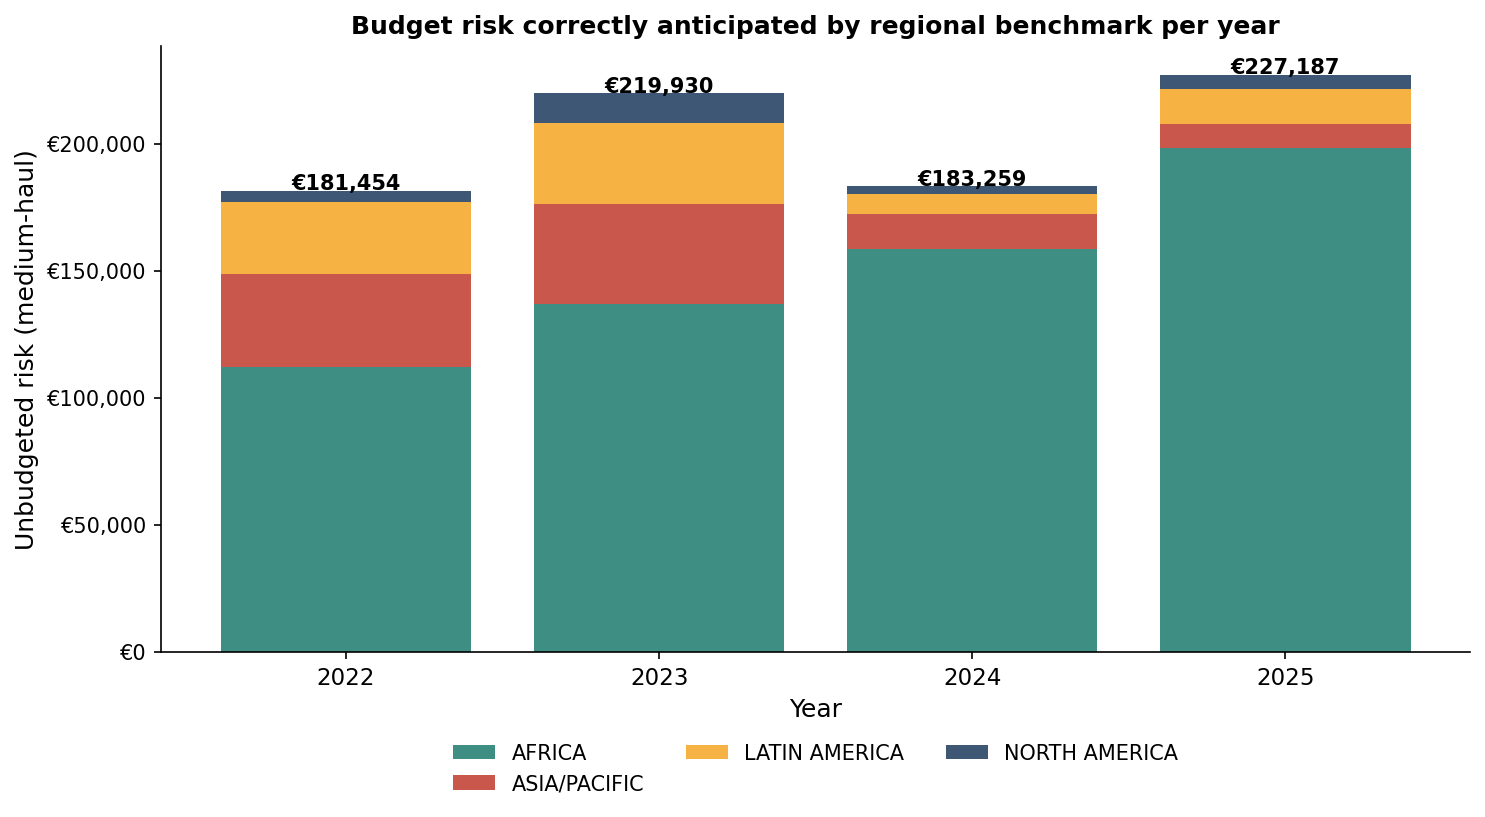

In [75]:
# ── R5: Chart B — Unbudgeted risk by region and year ─────────────────────────
risk_pivot = risk_tbl.pivot_table(
    index="invoice_year", columns="destination_region",
    values="unbudgeted_risk", aggfunc="sum", fill_value=0
).reset_index()
region_cols = [c for c in risk_pivot.columns if c != "invoice_year"]
reg_colors  = [PALETTE["teal"], PALETTE["coral"], PALETTE["amber"],
               PALETTE["navy"], PALETTE["grey"], "#8E44AD"]

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = float("nan")
import numpy as _np
bottom = _np.zeros(len(risk_pivot))
for rc, col in zip(region_cols, reg_colors):
    if rc in risk_pivot.columns:
        vals = risk_pivot[rc].values
        ax.bar(risk_pivot["invoice_year"].astype(str), vals,
               bottom=bottom, color=col, alpha=0.85, label=rc)
        bottom += vals
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Unbudgeted risk (medium-haul)", fontsize=12)
ax.set_title("Budget risk correctly anticipated by regional benchmark per year",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
ax.tick_params(axis="x", labelsize=11)
for i in range(len(risk_pivot)):
    total = risk_pivot.iloc[i][region_cols].sum()
    ax.text(i, total + 500, f"€{total:,.0f}",
            ha="center", fontsize=10, fontweight="bold")
ax.legend(fontsize=10, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
#plt.savefig("r5b_risk.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Summary — Combined Forecasted Savings: R1 to R4

> **Note:** R5 (Regional Benchmarking) is excluded from the summary totals as it is
> a budget planning metric rather than a cash saving. See the R5 section above for
> full methodology and the rationale for its removal from final recommendations.

In [76]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 100)
print("COMBINED FORECASTED SAVINGS — ALL FIVE RECOMMENDATIONS")
print("=" * 100)
print()
print(f"{'Rec':<5} {'Recommendation':<42} {'Historical saving €':>20} "
      f"{'Annualised 2024 €':>18} {'Annualised 2025 €':>18}")
print("-" * 105)
print(f"{'R1':<5} {'30-day booking cap':<42} "
      f"{r1_hist:>20,.0f} {r1_2024:>18,.0f} {r1_2025:>18,.0f}")
print(f"{'R2':<5} {'Default refundable fares':<42} "
      f"{r2_hist:>20,.0f} {r2_2024:>18,.0f} {r2_2025:>18,.0f}")
print(f"{'R3':<5} {'Q1 mission planning review':<42} "
      f"{r3_hist:>20,.0f} {r3_2024:>18,.0f} {r3_2025:>18,.0f}")
print(f"{'R4':<5} {'Rail substitution (cost only)':<42} "
      f"{r4_hist:>20,.0f} {r4_2024:>18,.0f} {r4_2025:>18,.0f}")
print(f"{'R5':<5} {'Regional benchmarking (budget risk)':<42} "
      f"{'€'+f'{total_risk_hist:,.0f}' + " risk":>20} "
      f"{'€'+f'{total_risk_24:,.0f}' + " risk":>18} "
      f"{'€'+f'{total_risk_25:,.0f}' + " risk":>18}")
print("-" * 105)
total_cash_hist = r1_hist + r2_hist + r3_hist + r4_hist
total_cash_2024 = r1_2024 + r2_2024 + r3_2024 + r4_2024
total_cash_2025 = r1_2025 + r2_2025 + r3_2025 + r4_2025
print(f"{'':5} {'TOTAL cash saving (R1–R4)':<42} "
      f"{total_cash_hist:>20,.0f} {total_cash_2024:>18,.0f} {total_cash_2025:>18,.0f}")
print()
print("Notes:")
print("  R1–R4: Cash savings based on avoided cancellation and exchange costs")
print("  R3:    Scope = Q1 2022–2026 only (post-COVID stable years; 2019–2021 excluded)")
print("  R4:    Cost saving only; carbon saving of 2,137 tCO₂e cited from Ale\'s Power BI")
print("  R5:    Not a cash saving — budget risk that regional benchmarking would anticipate")
print("  Exchange cost proxy = 25% of avg ticket (change fee; traveller still travels)")
print("  Cancellation cost proxy = full avg ticket price (fare assumed lost on cancellation)")
print(f"\n  Annualised estimates use full calendar years 2024 and 2025")


COMBINED FORECASTED SAVINGS — ALL FIVE RECOMMENDATIONS

Rec   Recommendation                              Historical saving €  Annualised 2024 €  Annualised 2025 €
---------------------------------------------------------------------------------------------------------
R1    30-day booking cap                                      148,630             28,068             11,631
R2    Default refundable fares                                 37,271              1,254              4,078
R3    Q1 mission planning review                               20,297              7,225              2,521
R4    Rail substitution (cost only)                           461,002             88,839             66,503
R5    Regional benchmarking (budget risk)               €811,829 risk      €183,259 risk      €227,187 risk
---------------------------------------------------------------------------------------------------------
      TOTAL cash saving (R1–R4)                               667,199            125

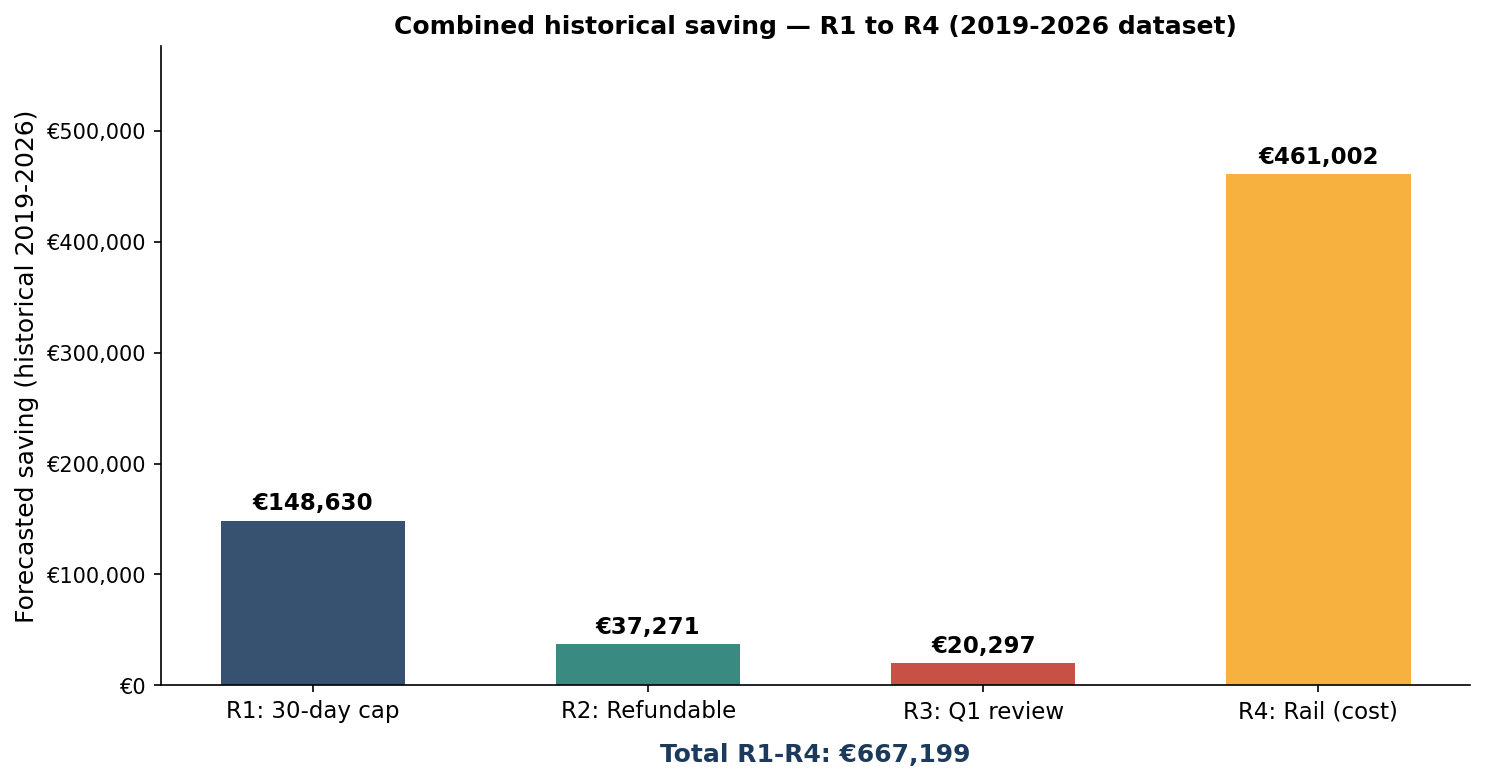

In [77]:
# ── Summary: Chart A — Historical saving by recommendation ───────────────────
rec_labels = ["R1: 30-day cap", "R2: Refundable", "R3: Q1 review", "R4: Rail (cost)"]
hist_vals  = [r1_hist, r2_hist, r3_hist, r4_hist]
rec_colors = [PALETTE["navy"], PALETTE["teal"], PALETTE["coral"], PALETTE["amber"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(rec_labels, hist_vals, color=rec_colors, alpha=0.88, width=0.55)
ax.set_ylabel("Forecasted saving (historical 2019-2026)", fontsize=12)
ax.set_title("Combined historical saving — R1 to R4 (2019-2026 dataset)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}"))
ax.tick_params(axis="x", labelsize=11)
ax.set_ylim(0, max(hist_vals) * 1.25)
for bar, v in zip(bars, hist_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v + max(hist_vals)*0.02,
            f"€{v:,.0f}", ha="center", fontsize=11, fontweight="bold")
ax.text(0.5, -0.12, f"Total R1-R4: €{total_cash_hist:,.0f}",
        ha="center", transform=ax.transAxes,
        fontsize=12, fontweight="bold", color=PALETTE["navy"])
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
#plt.savefig("summary_historical.png", bbox_inches="tight", dpi=150)
plt.show()


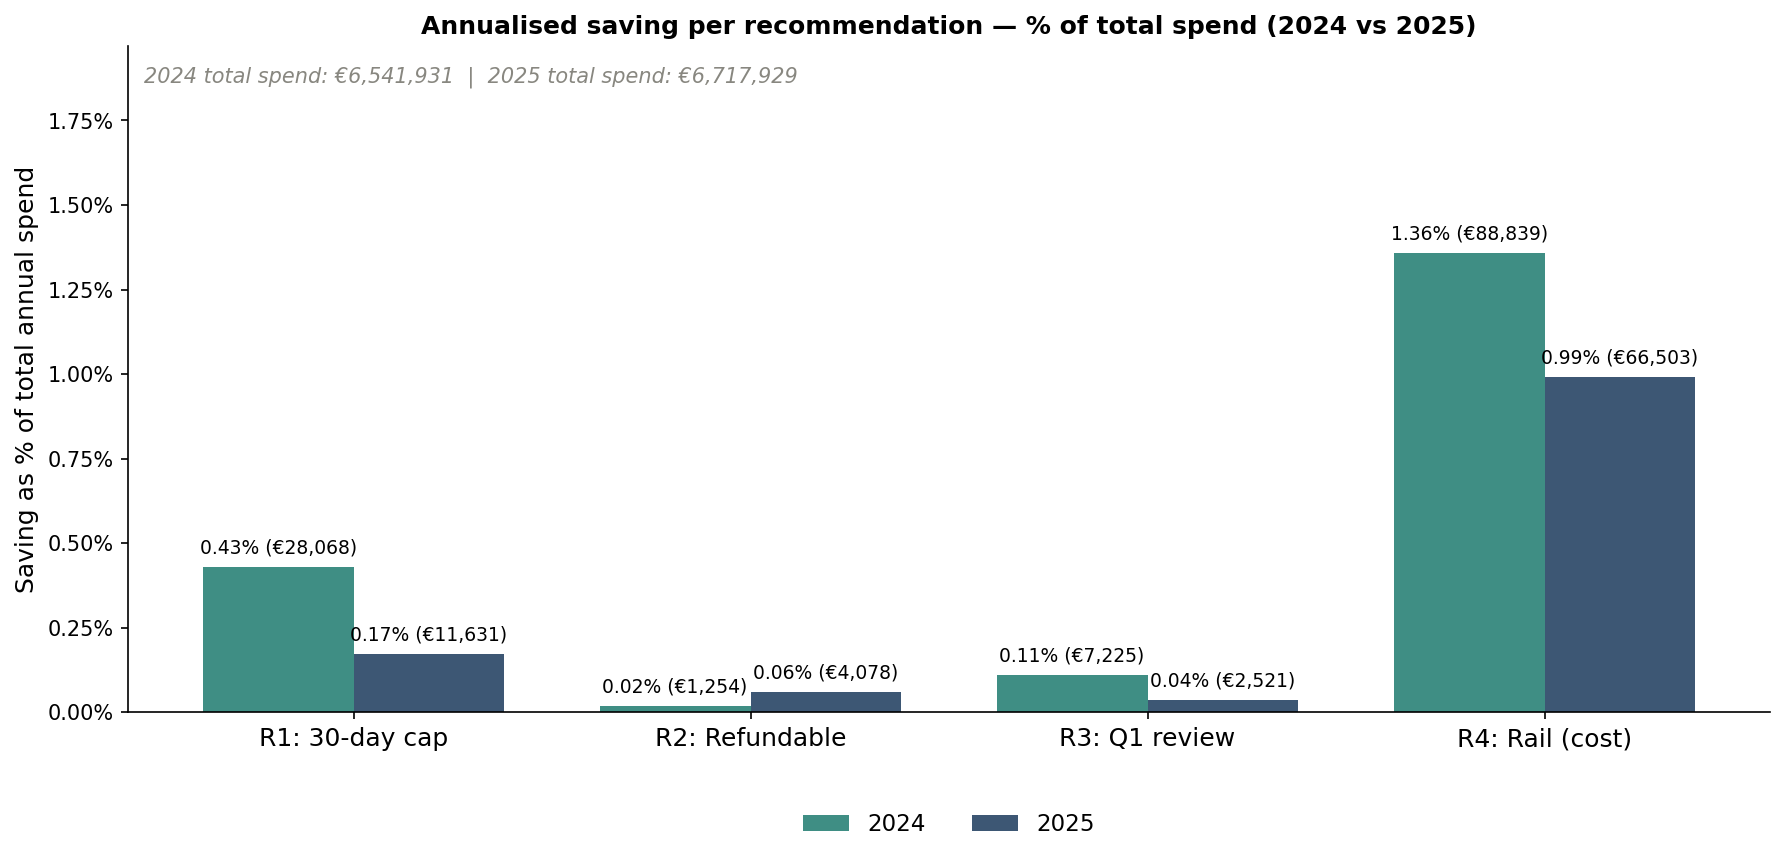

In [78]:
# ── Summary: Chart B — % of total spend saved per recommendation (2024 vs 2025)
# Shows saving as a percentage of total spend for that year
# Total spend derived from fj_pos for the relevant year

spend_2024 = fj_pos[fj_pos["invoice_year"]==2024]["total_invoice_amount"].sum()
spend_2025 = fj_pos[fj_pos["invoice_year"]==2025]["total_invoice_amount"].sum()

rec_labels = ["R1: 30-day cap", "R2: Refundable", "R3: Q1 review", "R4: Rail (cost)"]
y24_saves  = [r1_2024, r2_2024, r3_2024, r4_2024]
y25_saves  = [r1_2025, r2_2025, r3_2025, r4_2025]

# Convert to % of total spend
y24_pct = [v / spend_2024 * 100 for v in y24_saves]
y25_pct = [v / spend_2025 * 100 for v in y25_saves]

x = np.arange(len(rec_labels)); w = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars24 = ax.bar(x - w/2, y24_pct, w, color=PALETTE["teal"], alpha=0.85, label="2024")
bars25 = ax.bar(x + w/2, y25_pct, w, color=PALETTE["navy"], alpha=0.85, label="2025")
ax.set_xticks(x)
ax.set_xticklabels(rec_labels, fontsize=12)
ax.set_ylabel("Saving as % of total annual spend", fontsize=12)
ax.set_title("Annualised saving per recommendation — % of total spend (2024 vs 2025)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}%"))
ax.set_ylim(0, max(max(y24_pct), max(y25_pct)) * 1.45)

for i, (p24, p25, s24, s25) in enumerate(zip(y24_pct, y25_pct, y24_saves, y25_saves)):
    ax.text(i-w/2, p24 + max(max(y24_pct),max(y25_pct))*0.03,
            f"{p24:.2f}% (€{s24:,.0f})", ha="center", fontsize=9, linespacing=1.4)
    ax.text(i+w/2, p25 + max(max(y24_pct),max(y25_pct))*0.03,
            f"{p25:.2f}% (€{s25:,.0f})", ha="center", fontsize=9, linespacing=1.4)

ax.text(0.01, 0.97,
        f"2024 total spend: €{spend_2024:,.0f}  |  2025 total spend: €{spend_2025:,.0f}",
        ha="left", va="top", transform=ax.transAxes,
        fontsize=10, color=PALETTE["grey"], style="italic")

ax.legend(fontsize=11, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
#plt.savefig("summary_annualised_pct.png", bbox_inches="tight", dpi=150)
plt.show()


### Summary — Saving vs total spend: 2024 and 2025 context view
Shows the total spend for each year as the full bar, with the combined forecasted saving (R1–R4)
overlaid — giving the facilitator a direct view of how the saving compares to the overall travel budget.

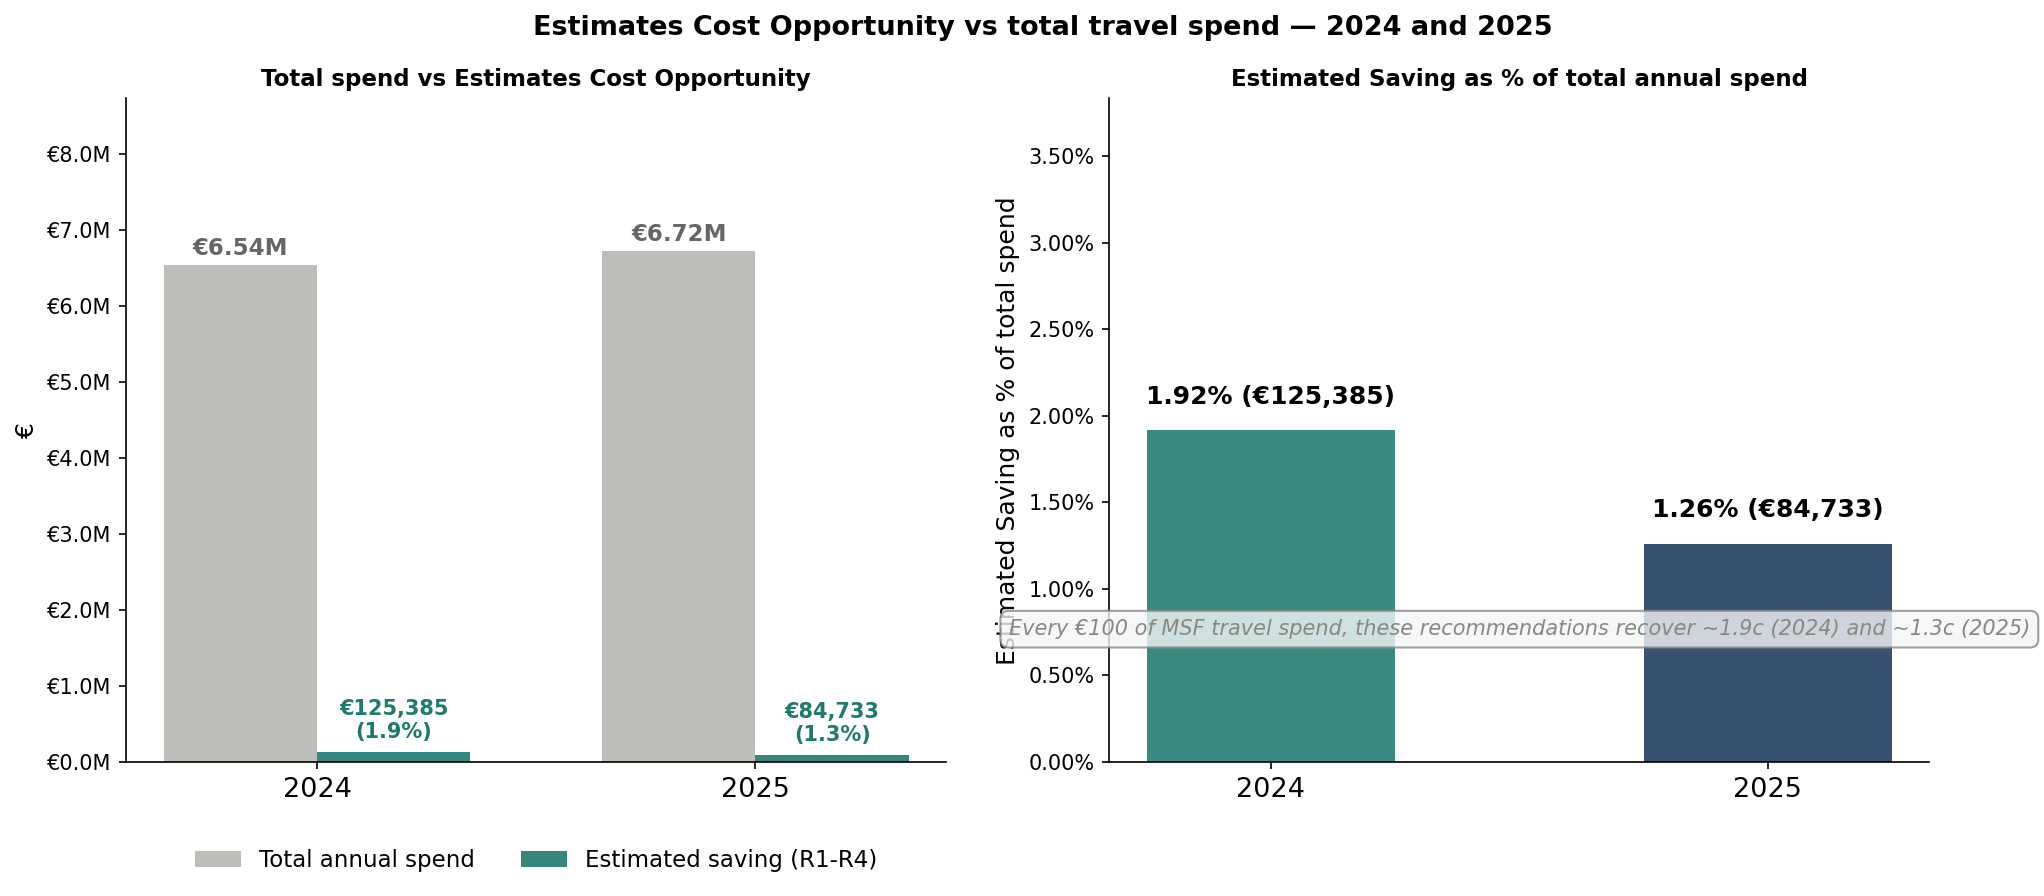

In [79]:
# ── Summary: Chart C — Saving vs total spend (facilitator context view) ──────
# Full bar = total annual spend; coloured segment = combined forecasted saving (R1-R4)
# Shows what proportion of total spend the recommendations would recover

spend_2024 = fj_pos[fj_pos["invoice_year"]==2024]["total_invoice_amount"].sum()
spend_2025 = fj_pos[fj_pos["invoice_year"]==2025]["total_invoice_amount"].sum()
total_cash_2024 = r1_2024 + r2_2024 + r3_2024 + r4_2024
total_cash_2025 = r1_2025 + r2_2025 + r3_2025 + r4_2025

pct_2024 = total_cash_2024 / spend_2024 * 100
pct_2025 = total_cash_2025 / spend_2025 * 100

years         = ["2024", "2025"]
total_spends  = [spend_2024,      spend_2025]
total_savings = [total_cash_2024, total_cash_2025]
remaining     = [ts - sv for ts, sv in zip(total_spends, total_savings)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Estimates Cost Opportunity vs total travel spend — 2024 and 2025",
             fontsize=13, fontweight="bold")

# ── Left: Grouped bar — total spend vs saving recovered ──────────────────────
x = np.arange(len(years))
w = 0.35 # Narrowed the width slightly to fit both bars neatly

# 1. Plot Total Spend as its own independent bar (shifted left)
axes[0].bar(x - w/2, total_spends, w, color=PALETTE["grey"], alpha=0.55, label="Total annual spend")

# 2. Plot Forecasted Saving as a separate, side-by-side bar (shifted right)
axes[0].bar(x + w/2, total_savings, w, color=PALETTE["teal"], alpha=0.90, label="Estimated saving (R1-R4)")

axes[0].set_xticks(x)
axes[0].set_xticklabels(years, fontsize=13)
axes[0].set_ylabel("€", fontsize=12)
axes[0].set_title("Total spend vs Estimates Cost Opportunity", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v/1e6:.1f}M"))

# Increased the y-limit slightly to give the new floating labels room to breathe
axes[0].set_ylim(0, max(total_spends) * 1.30)

for i, (ts, sv, pct) in enumerate(zip(total_spends, total_savings, [pct_2024, pct_2025])):
    # Label for Total Spend (placed directly above the left bar)
    axes[0].text(i - w/2, ts + max(total_spends)*0.02,
                 f"€{ts/1e6:.2f}M",
                 ha="center", fontsize=11, fontweight="bold", color="#666666")

    # Label for Forecasted Saving (placed directly above the right bar)
    axes[0].text(i + w/2, sv + max(total_spends)*0.02,
                 f"€{sv:,.0f}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold", color=PALETTE["teal"])

axes[0].legend(fontsize=11, frameon=False, loc="upper center",
               bbox_to_anchor=(0.5, -0.10), ncol=2)

# ── Right: % saving vs spend — bar chart with % labels ───────────────────────
pct_vals = [pct_2024, pct_2025]
pct_colors = [PALETTE["teal"], PALETTE["navy"]]
bars = axes[1].bar(years, pct_vals, color=pct_colors, alpha=0.88, width=0.5)
axes[1].set_ylabel("Estimated Saving as % of total spend", fontsize=12)
axes[1].set_title("Estimated Saving as % of total annual spend", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}%"))
axes[1].set_ylim(0, max(pct_vals) * 2.0)
axes[1].tick_params(axis="x", labelsize=13)

for bar, pct, sv in zip(bars, pct_vals, total_savings):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 pct + max(pct_vals)*0.08,
                 f"{pct:.2f}% (€{sv:,.0f})",
                 ha="center", fontsize=12, fontweight="bold", linespacing=1.5)

# Annotation explaining what % means
axes[1].text(0.5, 0.20,
             f"Every €100 of MSF travel spend, these recommendations recover ~{pct_2024:.1f}c (2024) and ~{pct_2025:.1f}c (2025)",
             ha="center", va="center", transform=axes[1].transAxes,
             fontsize=10, color=PALETTE["grey"], style="italic",
             bbox=dict(boxstyle="round,pad=0.4", facecolor=PALETTE["light"],
                       edgecolor=PALETTE["grey"], alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
#plt.savefig("summary_saving_vs_spend.png", bbox_inches="tight", dpi=150)
plt.show()


Team Suggestion - Add data for year 2022 and 2023 in the chart to the right

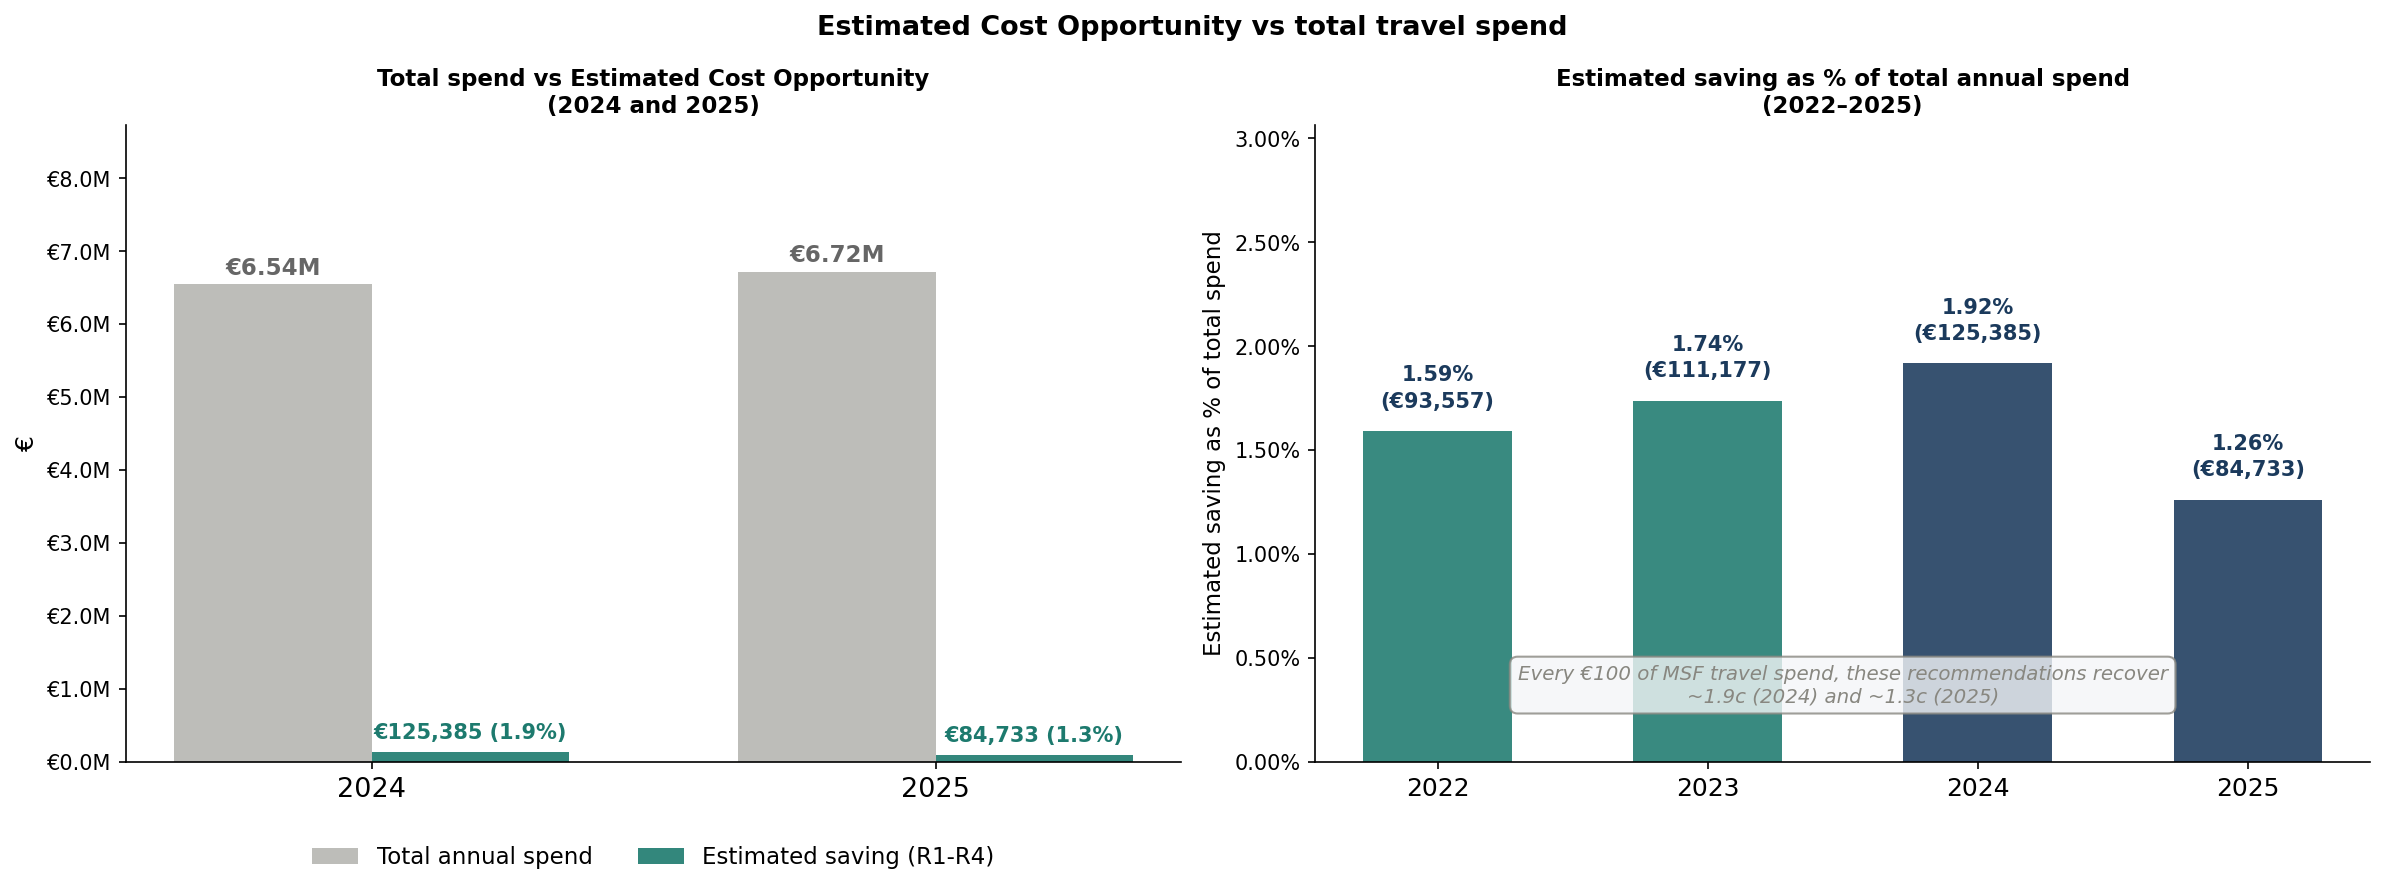

In [80]:
# ── Summary: Chart C — Saving vs total spend (facilitator context view) ──────
# Extended to show 2022, 2023, 2024 and 2025 in the right sub-chart

spend_2022 = fj_pos[fj_pos["invoice_year"]==2022]["total_invoice_amount"].sum()
spend_2023 = fj_pos[fj_pos["invoice_year"]==2023]["total_invoice_amount"].sum()
spend_2024 = fj_pos[fj_pos["invoice_year"]==2024]["total_invoice_amount"].sum()
spend_2025 = fj_pos[fj_pos["invoice_year"]==2025]["total_invoice_amount"].sum()

# 2022 and 2023 combined savings (same functions, same methodology)
r1_2022, _ = r1_saving(fj_pos[fj_pos["invoice_year"]==2022])
r1_2023, _ = r1_saving(fj_pos[fj_pos["invoice_year"]==2023])

nr_2022 = ref[(ref["invoice_year"]==2022) & (ref["refundable_indicator"]=="Non-Refundable")]
r2_2022 = r2_saving(len(nr_2022), nr_2022["total_invoice_amount"].mean() or 0) if len(nr_2022) > 0 else 0.0

nr_2023 = ref[(ref["invoice_year"]==2023) & (ref["refundable_indicator"]=="Non-Refundable")]
r2_2023 = r2_saving(len(nr_2023), nr_2023["total_invoice_amount"].mean() or 0) if len(nr_2023) > 0 else 0.0

r3_2022 = r3_saving(q1[q1["invoice_year"]==2022])
r3_2023 = r3_saving(q1[q1["invoice_year"]==2023])

r4_2022 = r4_saving(air_g2_plan[air_g2_plan["invoice_year"]==2022])
r4_2023 = r4_saving(air_g2_plan[air_g2_plan["invoice_year"]==2023])

total_cash_2022 = r1_2022 + r2_2022 + r3_2022 + r4_2022
total_cash_2023 = r1_2023 + r2_2023 + r3_2023 + r4_2023
total_cash_2024 = r1_2024 + r2_2024 + r3_2024 + r4_2024
total_cash_2025 = r1_2025 + r2_2025 + r3_2025 + r4_2025

pct_2022 = total_cash_2022 / spend_2022 * 100
pct_2023 = total_cash_2023 / spend_2023 * 100
pct_2024 = total_cash_2024 / spend_2024 * 100
pct_2025 = total_cash_2025 / spend_2025 * 100

years        = ["2024", "2025"]
total_spends  = [spend_2024, spend_2025]
total_savings = [total_cash_2024, total_cash_2025]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Estimated Cost Opportunity vs total travel spend",
             fontsize=13, fontweight="bold")

# ── Left: 2024 and 2025 grouped bar (unchanged) ───────────────────────────────
x = np.arange(len(years))
w = 0.35

axes[0].bar(x - w/2, total_spends,  w, color=PALETTE["grey"], alpha=0.55, label="Total annual spend")
axes[0].bar(x + w/2, total_savings, w, color=PALETTE["teal"], alpha=0.90, label="Estimated saving (R1-R4)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(years, fontsize=13)
axes[0].set_ylabel("€", fontsize=12)
axes[0].set_title("Total spend vs Estimated Cost Opportunity\n(2024 and 2025)", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v/1e6:.1f}M"))
axes[0].set_ylim(0, max(total_spends) * 1.30)

for i, (ts, sv, pct) in enumerate(zip(total_spends, total_savings, [pct_2024, pct_2025])):
    axes[0].text(i - w/2, ts + max(total_spends)*0.02,
                 f"€{ts/1e6:.2f}M",
                 ha="center", fontsize=11, fontweight="bold", color="#666666")
    axes[0].text(i + w/2, sv + max(total_spends)*0.02,
                 f"€{sv:,.0f} ({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold", color=PALETTE["teal"])

axes[0].legend(fontsize=11, frameon=False, loc="upper center",
               bbox_to_anchor=(0.5, -0.10), ncol=2)

# ── Right: % saving across 2022–2025 ─────────────────────────────────────────
trend_years   = ["2022", "2023", "2024", "2025"]
pct_vals      = [pct_2022, pct_2023, pct_2024, pct_2025]
saving_vals   = [total_cash_2022, total_cash_2023, total_cash_2024, total_cash_2025]
pct_colors    = [PALETTE["teal"], PALETTE["teal"], PALETTE["navy"], PALETTE["navy"]]

bars = axes[1].bar(trend_years, pct_vals, color=pct_colors, alpha=0.88, width=0.55)
axes[1].set_ylabel("Estimated saving as % of total spend", fontsize=11)
axes[1].set_title("Estimated saving as % of total annual spend\n(2022–2025)", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}%"))
axes[1].set_ylim(0, max(pct_vals) * 1.60)
axes[1].tick_params(axis="x", labelsize=12)

for bar, pct, sv in zip(bars, pct_vals, saving_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 pct + max(pct_vals)*0.06,
                 f"{pct:.2f}%\n(€{sv:,.0f})",
                 ha="center", fontsize=10, fontweight="bold",
                 color=PALETTE["navy"], linespacing=1.4)

axes[1].text(0.5, 0.12,
             f"Every €100 of MSF travel spend, these recommendations recover\n"
             f"~{pct_2024:.1f}c (2024) and ~{pct_2025:.1f}c (2025)",
             ha="center", va="center", transform=axes[1].transAxes,
             fontsize=9.5, color=PALETTE["grey"], style="italic",
             bbox=dict(boxstyle="round,pad=0.4", facecolor=PALETTE["light"],
                       edgecolor=PALETTE["grey"], alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
#plt.savefig("summary_saving_vs_spend.png", bbox_inches="tight", dpi=150)
plt.show()

After meeting the facilitator, it was discussed that keeping only the right chart is more suitable, so creating a new chart

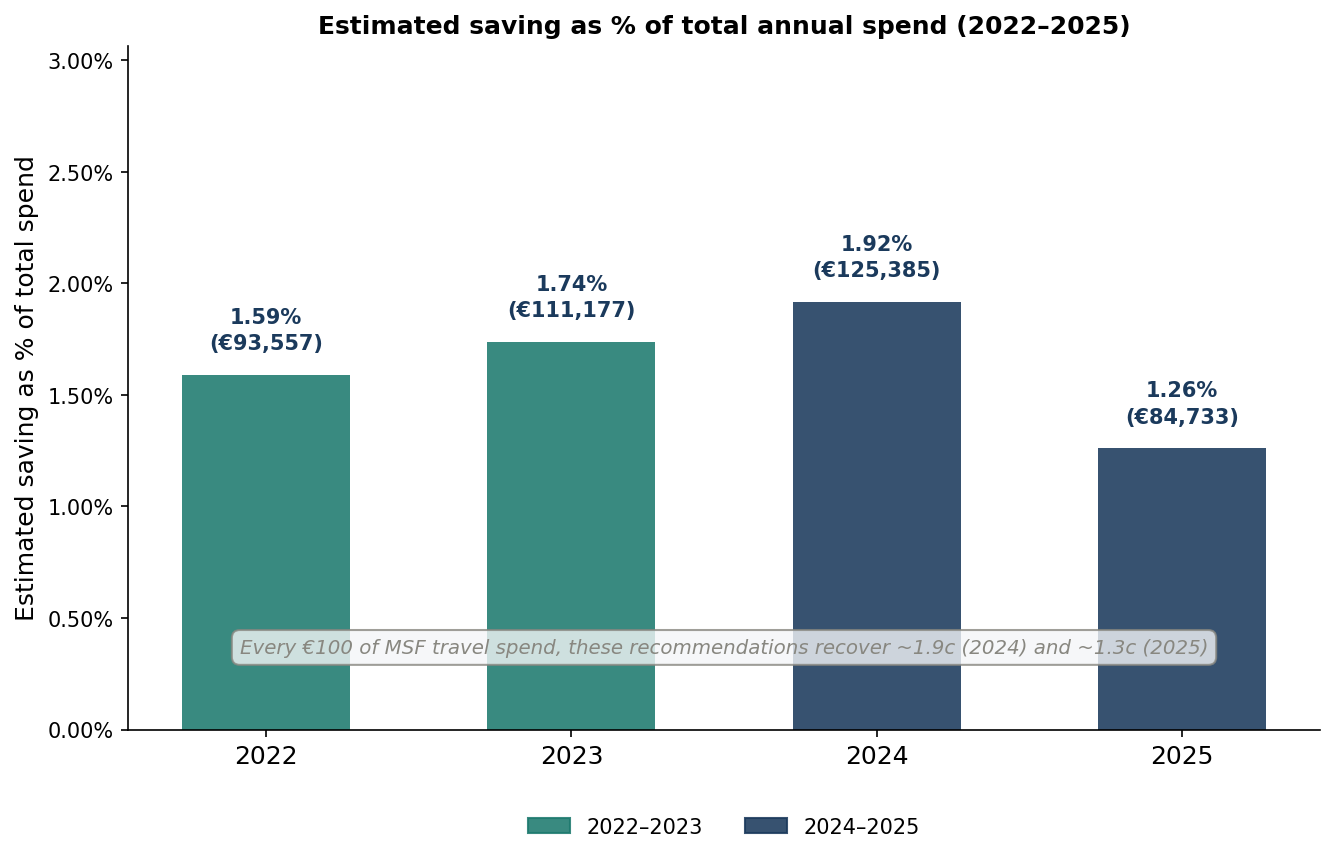

In [81]:
# ── Estimated saving as % of total annual spend: 2022–2025 ───────────────────

spend_2022 = fj_pos[fj_pos["invoice_year"]==2022]["total_invoice_amount"].sum()
spend_2023 = fj_pos[fj_pos["invoice_year"]==2023]["total_invoice_amount"].sum()
spend_2024 = fj_pos[fj_pos["invoice_year"]==2024]["total_invoice_amount"].sum()
spend_2025 = fj_pos[fj_pos["invoice_year"]==2025]["total_invoice_amount"].sum()

r1_2022, _ = r1_saving(fj_pos[fj_pos["invoice_year"]==2022])
r1_2023, _ = r1_saving(fj_pos[fj_pos["invoice_year"]==2023])

nr_2022 = ref[(ref["invoice_year"]==2022) & (ref["refundable_indicator"]=="Non-Refundable")]
r2_2022 = r2_saving(len(nr_2022), nr_2022["total_invoice_amount"].mean() or 0) if len(nr_2022) > 0 else 0.0

nr_2023 = ref[(ref["invoice_year"]==2023) & (ref["refundable_indicator"]=="Non-Refundable")]
r2_2023 = r2_saving(len(nr_2023), nr_2023["total_invoice_amount"].mean() or 0) if len(nr_2023) > 0 else 0.0

r3_2022 = r3_saving(q1[q1["invoice_year"]==2022])
r3_2023 = r3_saving(q1[q1["invoice_year"]==2023])

r4_2022 = r4_saving(air_g2_plan[air_g2_plan["invoice_year"]==2022])
r4_2023 = r4_saving(air_g2_plan[air_g2_plan["invoice_year"]==2023])

total_cash_2022 = r1_2022 + r2_2022 + r3_2022 + r4_2022
total_cash_2023 = r1_2023 + r2_2023 + r3_2023 + r4_2023
total_cash_2024 = r1_2024 + r2_2024 + r3_2024 + r4_2024
total_cash_2025 = r1_2025 + r2_2025 + r3_2025 + r4_2025

pct_2022 = total_cash_2022 / spend_2022 * 100
pct_2023 = total_cash_2023 / spend_2023 * 100
pct_2024 = total_cash_2024 / spend_2024 * 100
pct_2025 = total_cash_2025 / spend_2025 * 100

trend_years = ["2022", "2023", "2024", "2025"]
pct_vals    = [pct_2022, pct_2023, pct_2024, pct_2025]
saving_vals = [total_cash_2022, total_cash_2023, total_cash_2024, total_cash_2025]
pct_colors  = [PALETTE["teal"], PALETTE["teal"], PALETTE["navy"], PALETTE["navy"]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(trend_years, pct_vals, color=pct_colors, alpha=0.88, width=0.55)
ax.set_ylabel("Estimated saving as % of total spend", fontsize=12)
ax.set_title("Estimated saving as % of total annual spend (2022–2025)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}%"))
ax.set_ylim(0, max(pct_vals) * 1.60)
ax.tick_params(axis="x", labelsize=12)

for bar, pct, sv in zip(bars, pct_vals, saving_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            pct + max(pct_vals)*0.06,
            f"{pct:.2f}%\n(€{sv:,.0f})",
            ha="center", fontsize=10, fontweight="bold",
            color=PALETTE["navy"], linespacing=1.4)

ax.text(0.5, 0.12,
        f"Every €100 of MSF travel spend, these recommendations recover"
        f" ~{pct_2024:.1f}c (2024) and ~{pct_2025:.1f}c (2025)",
        ha="center", va="center", transform=ax.transAxes,
        fontsize=9.5, color=PALETTE["grey"], style="italic",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=PALETTE["light"],
                  edgecolor=PALETTE["grey"], alpha=0.8))

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=PALETTE["teal"], alpha=0.88),
    plt.Rectangle((0,0),1,1, color=PALETTE["navy"], alpha=0.88)],
    labels=["2022–2023", "2024–2025"],
    fontsize=10, frameon=False, loc="upper center",
    bbox_to_anchor=(0.5, -0.10), ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig("pct_saving_2022_2025.png", bbox_inches="tight", dpi=150)
plt.show()

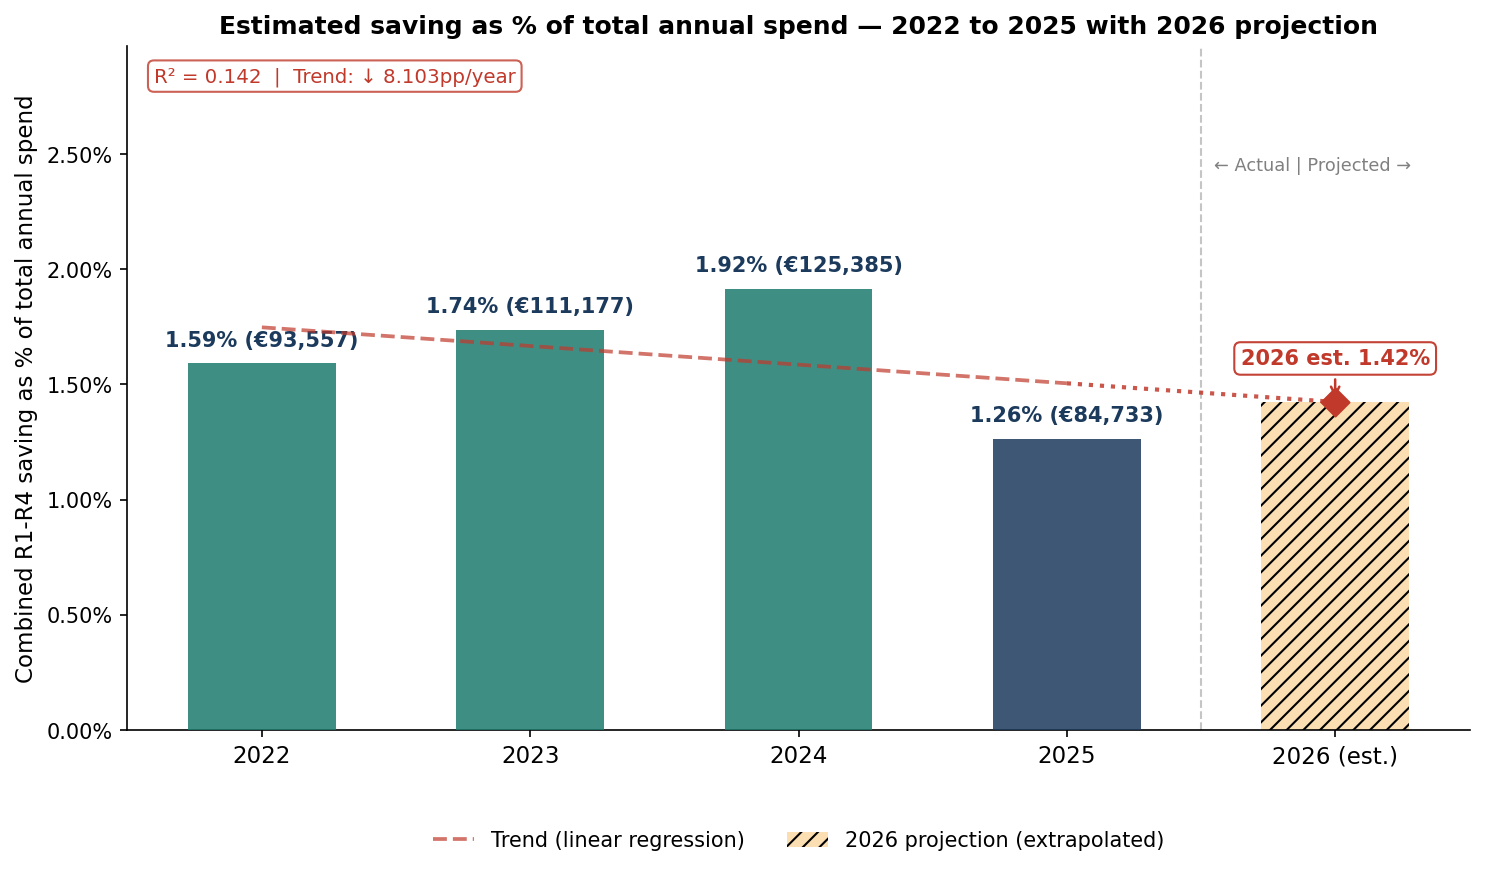

Year-on-year summary:
  2022: saving €93,557 | spend €5,879,839 | 1.591% of spend
  2023: saving €111,177 | spend €6,399,019 | 1.737% of spend
  2024: saving €125,385 | spend €6,541,931 | 1.917% of spend
  2025: saving €84,733 | spend €6,717,929 | 1.261% of spend
  2026 projection: 1.424% (linear extrapolation)
  R² = 0.142 — weak linear fit


In [82]:
# ── Extended % saving chart: 2022–2025 actuals + 2026 regression projection ──
# Standalone version of the right sub-chart from Chart C above,
# extended to show all post-COVID stable years and a 2026 trend projection.

from scipy import stats

TREND_YEARS = [2022, 2023, 2024, 2025]
YEAR_PROJ   = 2026

# ── Compute combined R1-R4 saving and total spend for each year ───────────────
def combined_saving_yr(yr):
    """Return (total_saving, total_spend, pct) for a given year."""
    # R1
    fj_yr = fj_pos[fj_pos["invoice_year"] == yr]
    r1_v, _ = r1_saving(fj_yr)

    # R2
    nr_yr = ref[(ref["invoice_year"] == yr) &
                (ref["refundable_indicator"] == "Non-Refundable")]
    r2_v = r2_saving(
        len(nr_yr),
        nr_yr["total_invoice_amount"].mean() if len(nr_yr) > 0 else 0
    ) if len(nr_yr) > 0 else 0.0

    # R3 (Q1 only)
    q1_yr = q1[q1["invoice_year"] == yr]
    r3_v  = r3_saving(q1_yr) if len(q1_yr) > 0 else 0.0

    # R4
    r4_v = r4_saving(air_g2_plan[air_g2_plan["invoice_year"] == yr])

    total_save  = r1_v + r2_v + r3_v + r4_v
    total_spend = fj_yr["total_invoice_amount"].sum()
    pct         = (total_save / total_spend * 100) if total_spend > 0 else 0.0
    return total_save, total_spend, pct

results = {yr: combined_saving_yr(yr) for yr in TREND_YEARS}
pct_vals   = np.array([results[yr][2] for yr in TREND_YEARS])
save_vals  = np.array([results[yr][0] for yr in TREND_YEARS])
spend_vals = np.array([results[yr][1] for yr in TREND_YEARS])
years_arr  = np.array(TREND_YEARS)

# ── Linear regression ─────────────────────────────────────────────────────────
slope, intercept, r_val, *_ = stats.linregress(years_arr, pct_vals)
pct_fit   = slope * years_arr + intercept
pct_2026  = slope * YEAR_PROJ  + intercept
save_2026 = pct_2026 / 100 * spend_vals.mean()  # proxy spend for label

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Actual bars
bar_colors = [PALETTE["teal"] if yr < 2025 else PALETTE["navy"] for yr in TREND_YEARS]
bars = ax.bar(years_arr, pct_vals, color=bar_colors, alpha=0.85, width=0.55, zorder=3)

# 2026 projection bar (faded + hatched)
ax.bar(YEAR_PROJ, max(pct_2026, 0), color=PALETTE["amber"],
       alpha=0.35, width=0.55, hatch="///", zorder=2, label="2026 projection (extrapolated)")

# Regression line over actuals + extension to 2026
all_x = np.append(years_arr, YEAR_PROJ)
all_y = np.append(pct_fit, pct_2026)
ax.plot(years_arr, pct_fit, color=PALETTE["coral"],
        lw=1.8, ls="--", alpha=0.7, label="Trend (linear regression)", zorder=4)
ax.plot([years_arr[-1], YEAR_PROJ], [pct_fit[-1], pct_2026],
        color=PALETTE["coral"], lw=2, ls=":", alpha=0.85, zorder=4)

# 2026 projected point
ax.scatter([YEAR_PROJ], [max(pct_2026, 0)],
           color=PALETTE["coral"], s=90, zorder=6, marker="D")

# Value labels on actual bars
for bar, yr, pct, sv in zip(bars, TREND_YEARS, pct_vals, save_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            pct + max(pct_vals) * 0.04,
            f"{pct:.2f}% (€{sv:,.0f})",
            ha="center", fontsize=10, fontweight="bold",
            color=PALETTE["navy"], linespacing=1.4)

# 2026 projection label
ax.annotate(
    f"2026 est. {max(pct_2026,0):.2f}%",
    xy=(YEAR_PROJ, max(pct_2026, 0)),
    xytext=(0, 18), textcoords="offset points",
    ha="center", fontsize=10, fontweight="bold", color=PALETTE["coral"],
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor=PALETTE["coral"], alpha=0.95),
    arrowprops=dict(arrowstyle="->", color=PALETTE["coral"], lw=1.2)
)

# R² annotation
ax.text(0.02, 0.97,
        f"R² = {r_val**2:.3f}  |  Trend: {'↑' if slope > 0 else '↓'} {abs(slope)*100:.3f}pp/year",
        ha="left", va="top", transform=ax.transAxes,
        fontsize=9.5, color=PALETTE["coral"],
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=PALETTE["coral"], alpha=0.8))

# Divider between actuals and projection
ax.axvline(2025.5, color="grey", lw=1, ls="--", alpha=0.45)
ax.text(2025.55, max(pct_vals) * 1.30,
        "← Actual | Projected →",
        fontsize=8.5, color="grey", va="top")

ax.set_xticks(list(TREND_YEARS) + [YEAR_PROJ])
ax.set_xticklabels([str(y) for y in TREND_YEARS] + ["2026 (est.)"], fontsize=11)
ax.set_ylabel("Combined R1-R4 saving as % of total annual spend", fontsize=11)
ax.set_title("Estimated saving as % of total annual spend — 2022 to 2025 with 2026 projection",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}%"))
ax.set_ylim(0, max(pct_vals) * 1.55)
ax.tick_params(axis="y", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
#plt.savefig("pct_saving_trend_2022_2026.png", bbox_inches="tight", dpi=150)
plt.show()

print("Year-on-year summary:")
for yr in TREND_YEARS:
    sv, sp, pct = results[yr]
    print(f"  {yr}: saving €{sv:,.0f} | spend €{sp:,.0f} | {pct:.3f}% of spend")
print(f"  2026 projection: {max(pct_2026,0):.3f}% (linear extrapolation)")
print(f"  R² = {r_val**2:.3f} — {'strong' if r_val**2 > 0.8 else 'moderate' if r_val**2 > 0.5 else 'weak'} linear fit")


We, as a team, are not happy with the 14% confidence of this regression model. Instead, we are trying a monthly moving average, which we will aggregate at yearly level.

### Estimated Saving as % of Total Annual Spend — Monthly Moving Average with Yearly Aggregation

**Method:** Rather than applying a trend line to just four yearly data points, this chart
computes the combined R1–R4 saving **month by month** (48 data points across 2022–2025),
applies a **3-month rolling average** to smooth seasonal noise, then aggregates those smoothed
monthly values back to **yearly totals** for the bar chart.

This gives a genuine time series smoothing with enough data points to be statistically
meaningful. The 2026 projection extends the smoothed monthly trend forward 12 months
(January–December 2026) using the slope of the final 12-month smoothed window, then sums
those projected monthly values to produce the 2026 yearly estimate.

**Why this is better:** 48 monthly points vs 4 yearly
points. The rolling average captures within-year seasonality (Q1 spikes, travel volume
patterns) before aggregating — the yearly totals reflect smoother, more stable estimates.


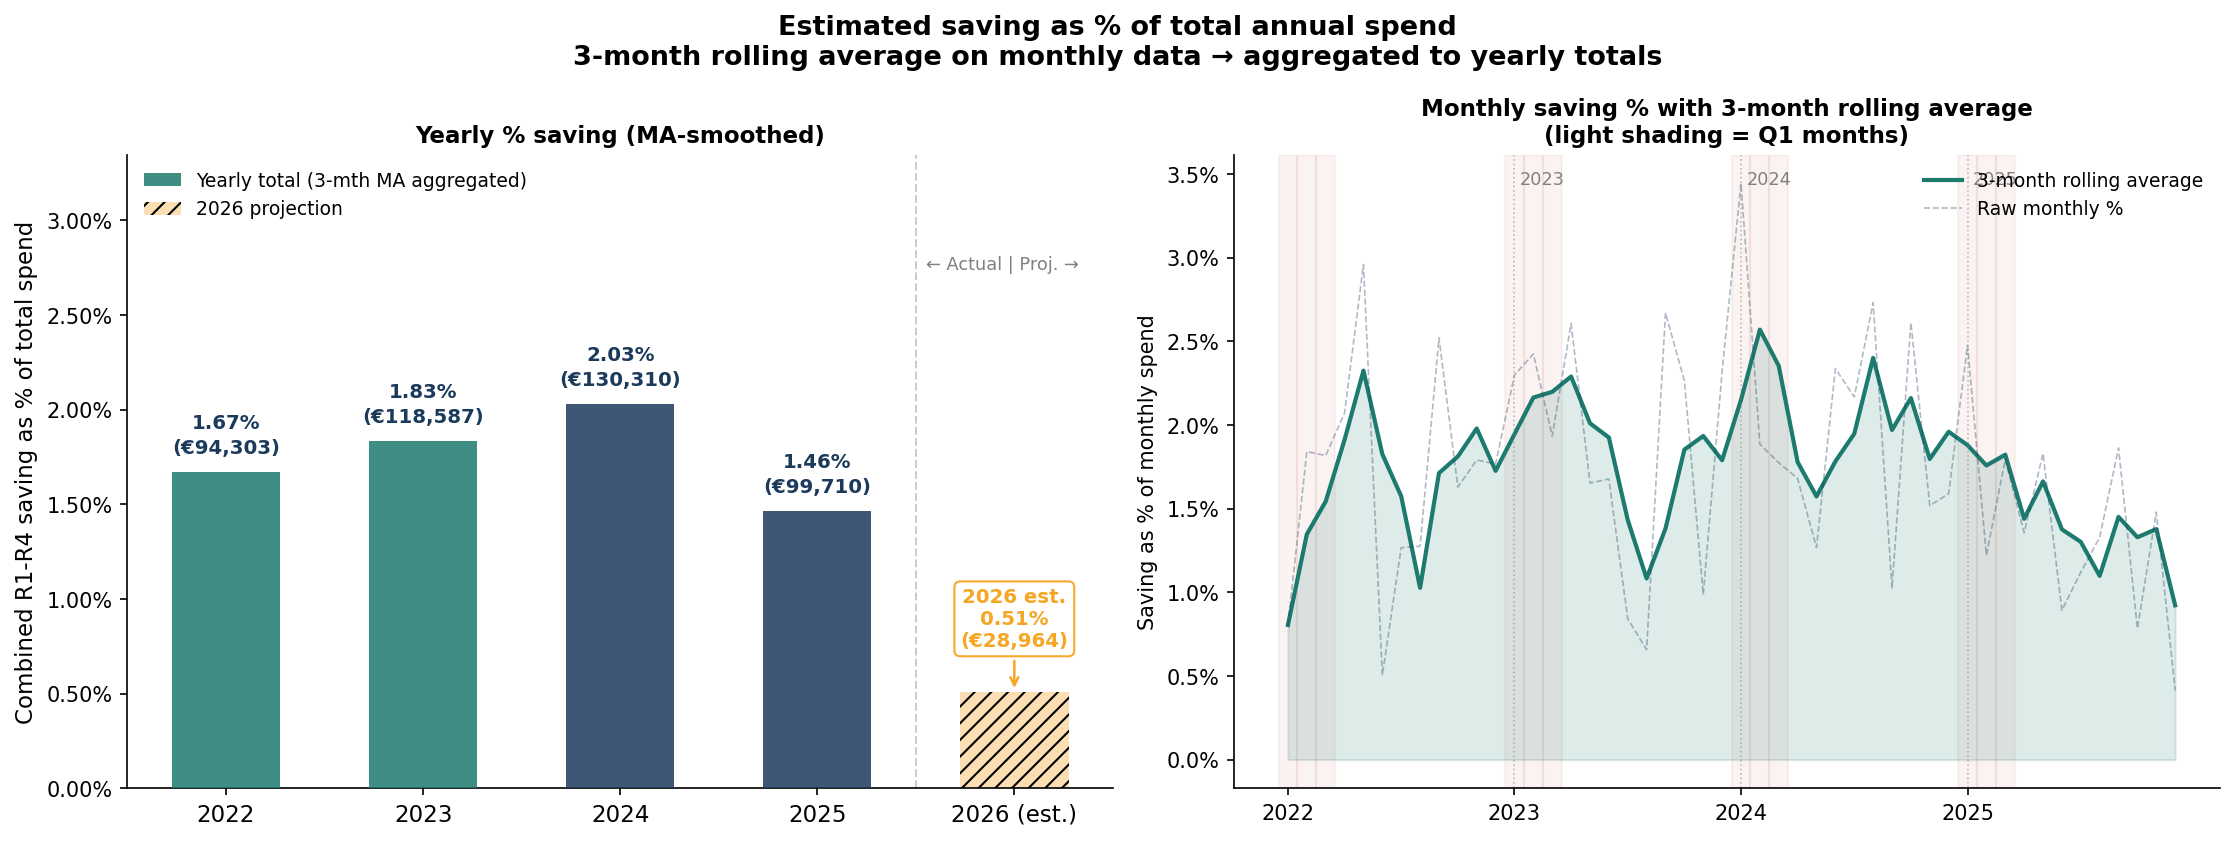

Year-on-year summary (MA-smoothed monthly → yearly aggregate):
Year        Saving (MA)     Spend (MA)   % of spend
----------------------------------------------------
2022     €      94,303 €   5,648,473        1.67%
2023     €     118,587 €   6,471,649        1.83%
2024     €     130,310 €   6,423,273        2.03%
2025     €      99,710 €   6,813,398        1.46%
2026 est. €      28,964 €   5,698,258        0.51%  ← 12-month trend extrapolation


In [83]:
# ── % saving: monthly MA → yearly aggregation + 2026 projection ──────────────
# Step 1: compute combined saving month-by-month (2022–2025)
# Step 2: apply 3-month rolling average to smooth noise
# Step 3: aggregate smoothed monthly values → yearly totals
# Step 4: project 2026 by extending the trend of the final 12 smoothed months

TREND_YEARS = [2022, 2023, 2024, 2025]
MA_WINDOW   = 3    # 3-month rolling average

# ── Step 1: Monthly saving and spend ─────────────────────────────────────────
monthly_records = []

for yr in TREND_YEARS:
    for mo in range(1, 13):
        fj_mo = fj_pos[
            (fj_pos["invoice_year"]  == yr) &
            (fj_pos["invoice_month"] == mo)
        ]
        if len(fj_mo) == 0:
            monthly_records.append({"year": yr, "month": mo,
                                     "saving": 0.0, "spend": 0.0})
            continue

        # R1
        r1_v, _ = r1_saving(fj_mo)

        # R2
        nr_mo = ref[
            (ref["invoice_year"]  == yr) &
            (ref["invoice_month"] == mo) &
            (ref["refundable_indicator"] == "Non-Refundable")
        ]
        r2_v = r2_saving(
            len(nr_mo),
            nr_mo["total_invoice_amount"].mean() if len(nr_mo) > 0 else 0.0
        ) if len(nr_mo) > 0 else 0.0

        # R3 (Q1 months only; 0 saving in other months by definition)
        q1_mo = q1[
            (q1["invoice_year"]  == yr) &
            (q1["invoice_month"] == mo)
        ] if mo in [1, 2, 3] else pd.DataFrame()
        r3_v = r3_saving(q1_mo) if len(q1_mo) > 0 else 0.0

        # R4
        g2_mo = air_g2_plan[
            (air_g2_plan["invoice_year"]  == yr) &
            (air_g2_plan["invoice_month"] == mo)
        ] if "invoice_month" in air_g2_plan.columns else pd.DataFrame()
        r4_v = r4_saving(g2_mo) if len(g2_mo) > 0 else 0.0

        saving = r1_v + r2_v + r3_v + r4_v
        spend  = fj_mo["total_invoice_amount"].sum()
        monthly_records.append({"year": yr, "month": mo,
                                  "saving": saving, "spend": spend})

monthly_df = pd.DataFrame(monthly_records)
monthly_df["period"]  = monthly_df["year"] * 100 + monthly_df["month"]
monthly_df            = monthly_df.sort_values("period").reset_index(drop=True)
monthly_df["pct"]     = np.where(
    monthly_df["spend"] > 0,
    monthly_df["saving"] / monthly_df["spend"] * 100,
    0.0
)

# ── Step 2: 3-month rolling average on saving and spend separately ────────────
monthly_df["saving_ma"] = monthly_df["saving"].rolling(MA_WINDOW, min_periods=1).mean()
monthly_df["spend_ma"]  = monthly_df["spend"].rolling(MA_WINDOW,  min_periods=1).mean()
monthly_df["pct_ma"]    = np.where(
    monthly_df["spend_ma"] > 0,
    monthly_df["saving_ma"] / monthly_df["spend_ma"] * 100,
    0.0
)

# ── Step 3: Aggregate smoothed monthly → yearly totals ────────────────────────
yearly = (
    monthly_df.groupby("year")
    .agg(saving_raw =("saving",    "sum"),
         spend_raw  =("spend",     "sum"),
         saving_ma  =("saving_ma", "sum"),
         spend_ma   =("spend_ma",  "sum"))
    .reset_index()
)
yearly["pct_raw"] = yearly["saving_raw"] / yearly["spend_raw"]  * 100
yearly["pct_ma"]  = yearly["saving_ma"]  / yearly["spend_ma"]   * 100

# ── Step 4: 2026 projection via trend of last 12 smoothed months ──────────────
last_12 = monthly_df.tail(12).copy()
last_12["t"] = np.arange(len(last_12))
slope_s, intercept_s = np.polyfit(last_12["t"], last_12["saving_ma"], 1)
slope_sp, intercept_sp = np.polyfit(last_12["t"], last_12["spend_ma"],  1)

proj_saving_months = [slope_s  * (12 + i) + intercept_s  for i in range(12)]
proj_spend_months  = [slope_sp * (12 + i) + intercept_sp for i in range(12)]

proj_saving_2026 = max(sum(proj_saving_months), 0)
proj_spend_2026  = max(sum(proj_spend_months),  1)
proj_pct_2026    = proj_saving_2026 / proj_spend_2026 * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Estimated saving as % of total annual spend\n"
    "3-month rolling average on monthly data → aggregated to yearly totals",
    fontsize=13, fontweight="bold"
)

all_years  = TREND_YEARS + [2026]
all_pct_ma = list(yearly["pct_ma"]) + [proj_pct_2026]
bar_colors = [PALETTE["teal"], PALETTE["teal"], PALETTE["navy"], PALETTE["navy"],
              PALETTE["amber"]]

# ── Left: bar chart — MA-aggregated yearly % + 2026 projection ───────────────
bars = axes[0].bar(
    [str(y) for y in TREND_YEARS], yearly["pct_ma"],
    color=bar_colors[:4], alpha=0.85, width=0.55, zorder=3,
    label="Yearly total (3-mth MA aggregated)"
)
axes[0].bar(
    ["2026 (est.)"], [proj_pct_2026],
    color=PALETTE["amber"], alpha=0.35, width=0.55,
    hatch="///", zorder=2, label="2026 projection"
)

# Value labels on bars
for bar, pct, sv, sp in zip(bars, yearly["pct_ma"],
                              yearly["saving_ma"], yearly["spend_ma"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        pct + max(yearly["pct_ma"]) * 0.05,
        f"{pct:.2f}%\n(€{sv:,.0f})",
        ha="center", fontsize=9.5, fontweight="bold",
        color=PALETTE["navy"], linespacing=1.4
    )

# 2026 projection label
proj_bar_x = len(TREND_YEARS)
axes[0].annotate(
    f"2026 est.\n{proj_pct_2026:.2f}%\n(€{proj_saving_2026:,.0f})",
    xy=(proj_bar_x, proj_pct_2026),
    xytext=(0, 22), textcoords="offset points",
    ha="center", fontsize=9.5, fontweight="bold", color=PALETTE["amber"],
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor=PALETTE["amber"], alpha=0.95),
    arrowprops=dict(arrowstyle="->", color=PALETTE["amber"], lw=1.2)
)

axes[0].axvline(3.5, color="grey", lw=1, ls="--", alpha=0.4)
axes[0].text(3.55, max(yearly["pct_ma"]) * 1.35,
             "← Actual | Proj. →", fontsize=8.5, color="grey")
axes[0].set_ylim(0, max(yearly["pct_ma"]) * 1.65)
axes[0].set_ylabel("Combined R1-R4 saving as % of total spend", fontsize=11)
axes[0].set_title("Yearly % saving (MA-smoothed)", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
axes[0].tick_params(axis="x", labelsize=11)
axes[0].legend(fontsize=9, frameon=False, loc="upper left")

# ── Right: monthly MA line — shows the smoothed trend underlying the bars ─────
axes[1].fill_between(range(len(monthly_df)), monthly_df["pct_ma"],
                      alpha=0.15, color=PALETTE["teal"])
axes[1].plot(range(len(monthly_df)), monthly_df["pct_ma"],
             color=PALETTE["teal"], lw=2, label=f"{MA_WINDOW}-month rolling average")
axes[1].plot(range(len(monthly_df)), monthly_df["pct"],
             color=PALETTE["navy"], lw=0.8, alpha=0.35, ls="--",
             label="Raw monthly %")

# Year boundary lines
for yr_idx, yr in enumerate(TREND_YEARS[1:], 1):
    x_boundary = yr_idx * 12
    axes[1].axvline(x_boundary, color="grey", lw=0.8, ls=":", alpha=0.5)
    axes[1].text(x_boundary + 0.3, axes[1].get_ylim()[1] * 0.95 if
                  axes[1].get_ylim()[1] > 0 else 0.1,
                 str(yr), fontsize=8.5, color="grey")

# Q1 shading
q1_months = [i for i in range(len(monthly_df))
             if monthly_df.loc[i, "month"] in [1, 2, 3]]
for idx in q1_months:
    axes[1].axvspan(idx - 0.5, idx + 0.5, alpha=0.06,
                    color=PALETTE["coral"], zorder=0)

axes[1].set_xticks([i * 12 for i in range(len(TREND_YEARS))])
axes[1].set_xticklabels([str(y) for y in TREND_YEARS], fontsize=10)
axes[1].set_ylabel("Saving as % of monthly spend", fontsize=10)
axes[1].set_title(
    "Monthly saving % with 3-month rolling average\n(light shading = Q1 months)",
    fontsize=11, fontweight="bold"
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
#plt.savefig("pct_saving_monthly_ma_yearly.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Summary print ──────────────────────────────────────────────────────────────
print("Year-on-year summary (MA-smoothed monthly → yearly aggregate):")
print(f"{'Year':<8} {'Saving (MA)':>14} {'Spend (MA)':>14} {'% of spend':>12}")
print("-" * 52)
for _, r in yearly.iterrows():
    print(f"{int(r['year']):<8} €{r['saving_ma']:>12,.0f} €{r['spend_ma']:>12,.0f} "
          f"{r['pct_ma']:>11.2f}%")
print(f"{'2026 est.':<8} €{proj_saving_2026:>12,.0f} €{proj_spend_2026:>12,.0f} "
      f"{proj_pct_2026:>11.2f}%  ← 12-month trend extrapolation")


# Final Choice

As a team, we decided that the chart - Estimated saving as % of total annual spend (2022–2025) gives a better and clear picture of the YoY estimated savings, and is covered in our presentation